<a href="https://colab.research.google.com/github/AngelD222/Bullying-Detection-ML/blob/main/ML_trabajo1_Bullying.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Trabajo 1 de Machine Learning**
 Realizado por Ángel Franco Rodríguez

---










## **TAREA 1**

***PARTE 1:***

### **1.1 Metodología a seguir**

Para el entrenamiento y comparación de los modelos seguiremos una metodología estructurada en la definición de escenarios, el ajuste de hiperparámetros y la evaluación final del rendimiento.


* **1. Definición de escenarios de comparación**  
Con el objetivo de analizar el comportamiento de los modelos bajo distintas condiciones, diseñaremos varios **escenarios**, cada uno basado en diferentes estrategias de preprocesamiento del dataset original: estandarización, limpieza de valores, eliminación de variables, aplicación o no de técnicas de balanceo, etc.

* **2. Ajuste de hiperparámetros (Grid Search)**  
Partiendo de los valores por defecto de cada modelo, definiremos un rango suficientemente amplio de hiperparámetros y aplicamos **Grid Search** para explorar las combinaciones posibles buscando la que mejor resultado según los criterios de evaluación escogidos tenga.

* **3. Evaluación y selección del mejor modelo**  
Una vez obtenidos los resultados de todos los modelos en cada escenario, tenemos pensado establecer como criterios principales de selección las métricas **F2-score**, **Recall de la clase positiva** y **Precision** dado que nuestro problema prioriza la detección correcta de casos positivos (alumnos que sufren bullying) y penaliza especialmente los falsos negativos.  

Para concluir consideraremos el modelo que mejor desempeño general obtenga en base a ciertos criterios.

---

El índice a seguir en este *Notebook* para realizar lo anterior será el siguiente:

* 1.2. Configuración inicial para garantizar reproducibilidad

* 1.3. Contextualización del problema y preprocesamiento del dataset

    * Estudiar valores nulos (duplicados, correccion de tipos).
    * Codificar variables categóricas.
    * Separar datos en X_train, X_test, y_train, y_test.
    * Variables correladas.
    * Tratar Outliers (+ tratamiento de nulos).
    * Variables con varianza cercana a 0.
    * Análisis de desbalanceo de datos.
    * Estandarización.  
     
  
* 1.4. Cálculo de rendimiento con modelos sin tratamiento de datos y con tratamiento de datos

    * Modelo escogido 1: **SVM no lineal con kernel RBF**
    * Modelo escogido 2: **Boosting** (ensamble)
    * Modelo escogido 3: **Stacking** (ensamble)
    * Modelo escogido 4: **Random Forest** (ensamble)
    * Modelo escogido 5: **Cascading** (ensamble)

* 1.5. Comparación de modelos

* 1.6. Tratamiento del overfitting

* 1.7. Conclusión

* 1.8. Recomendación final para la Consejería









### **1.2 Configuración inicial para garantizar reproducibilidad**

En primer lugar importamos a GoogleColab el archivo Bullying1.csv desde GoogleDrive y lo convertimos en un *dataframe* para poder estudiarlo en profundidad:

In [ ]:
# Establecemos una semilla para usarla en todas las técnicas
import numpy as np
import random
semilla = 2000
np.random.seed(semilla) #fijamos la semilla para la librería NumPy
random.seed(semilla) #fijamos la semilla para el módulo random

# Número de conjuntos creados al realizar cross validation
cv_folds = 5

# Importamos las librerías que hemos ido usando en el proyecto junto con la versión con la que hemos ejecutado el código de nuestro trabajo
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
# Imbalance learning imports
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
# Sklearn imports
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn import svm
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, fbeta_score
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, make_scorer
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")


# Formato antiguo, utilizando Google Drive
#from google.colab import drive
# Montamos Google Drive
#drive.mount('/content/drive')

# Ruta de la carpeta donde he subido el archivo
#ruta_base = "/content/drive/MyDrive/datasets/MachineLearning/"

# Formato nuevo, utilizando el enlace compartido de drive del dataset
# ID del archivo en Google Drive
file_id = "1p3PrsjLANi13Wu-jvtWJL5ywc-Wi9puR"
# URL directa para descarga
url = f"https://drive.google.com/uc?export=download&id={file_id}"

# Cargamos el dataset como un dataframe para poder trabajar con él con profundidad
#df = pd.read_csv(ruta_base + "Bullying1.csv")
df = pd.read_csv(url)


NumPy version: 2.0.2
Pandas version: 2.2.2
Matplotlib version: 3.10.0
Seaborn version: 0.13.2


Una vez hemos realizado los preparativos comenzamos con la contextualización del problema.

### **1.3 Contextualización del problema y preprocesamiento del dataset**

La *consejería de educación* nos ha encargado realizar un informe con el objetivo de luchar contra el bullying en las aulas de los centros educativos. Nosotros vamos a realizar un informe en el que intentaremos predecir de la forma más precisa posible si un alumno sufre o no bullying en base a 16 características, para lo cual utilizaremos varias técnicas de *Machine Learning* aplicadas a la base de datos que se nos ha proporcionado, llamada *"Bullying1.csv"*.

**¿Qué significa esto?** Que a partir de esta base de datos entrenaremos un modelo que aprenderá, dadas las características de un alumno, a asignar dos etiquetas: "Sufre bullying" ó "No sufre bullying". Dentro de la rama de *Machine Learning* esto se conoce como un problema de clasificación supervisada y es más, como se trata de una decisión de "sí" ó "no", se llama concretamente un problema de clasificación binaria.

Gracias a este informe la consejería podrá detectar cuáles son los aspectos más importantes que afectan al problema del bullying y podrá prevenirlo de una mejor forma.

---
#### **1.3.1 Preprocesamiento de los datos**

Lo primero que vamos a hacer en esta sección es ver si los datos necesitan preprocesamiento, para ello cargamos el dataset como un dataframe y analizamos lo que vemos:

In [ ]:
# Mostramos las primeras filas y las últimas
df.head()
df

,Edad,Horas_Sueno,Notas_Promedio,Numero_Amigos,Tiempo_Videojuegos,Tiempo_Redes,Actividades_Extracurr,Ausencias_Escolares,Autoestima,Ansiedad,Depresion,Conflictos_Familiares,Tiempo_Internet,Actividad_Fisica,Genero,Tipo_Centro,Sufre_Bullying
0,15.0,6.0,5.5,12.0,1.7,6.0,3,12,1.9,5.7,0.7,2,3.7,0.5,Femenino,Publico,No
1,16.0,6.8,5.2,2.0,3.4,0.9,3,10,8.6,8.7,9.4,9,5.8,6.6,Femenino,Publico,Si
2,14.0,8.5,3.5,9.0,0.5,6.1,4,0,8.8,4.7,6.2,1,6.2,1.5,Femenino,Privado,No
3,16.0,9.2,6.8,4.0,2.5,0.9,0,21,3.0,9.3,7.3,9,0.0,3.6,Masculino,Privado,Si
4,16.0,6.6,7.6,2.0,4.5,9.6,4,29,8.2,2.1,6.8,4,7.4,0.4,Femenino,Privado,Si
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,16.0,4.6,4.7,5.0,5.1,8.6,1,29,2.8,3.5,3.9,6,6.0,3.6,Masculino,Publico,No
1996,12.0,4.6,3.2,2.0,1.5,8.9,1,7,1.8,8.2,9.6,4,8.5,3.8,Masculino,Privado,Si
1997,16.0,4.3,9.5,13.0,2.9,1.9,3,19,9.0,5.4,4.4,9,6.8,1.4,Femenino,Publico,No
1998,14.0,7.5,8.2,12.0,5.9,1.3,4,6,1.7,3.0,7.2,7,0.5,1.7,Masculino,Publico,No


In [ ]:
df.dtypes

,0
Edad,float64
Horas_Sueno,float64
Notas_Promedio,float64
Numero_Amigos,float64
Tiempo_Videojuegos,float64
Tiempo_Redes,float64
Actividades_Extracurr,int64
Ausencias_Escolares,int64
Autoestima,float64
Ansiedad,float64


Vemos que la mayoria de los datos son floats y enteros, salvo "*genero*", "*tipo_centro*" y "*sufre_bullying*". Los dos primeros son features, el ultimo es la etiqueta. Ahora veremos como tratarlos.

##### **1.3.1.1 Valores nulos**

Antes de aplicar *One Hot encoding* a las variables categóricas del dataset vamos a ver si existen o no valores nulos.

In [ ]:
valores_nulos = df.isnull().sum()

# Mostrar solo las columnas que tienen al menos un valor nulo
valores_nulos = valores_nulos[valores_nulos > 0]

if len(valores_nulos) == 0:
    print("No hay valores nulos en el dataset.")
else:
    print("Columnas con valores nulos:\n")
    print(valores_nulos)

Columnas con valores nulos:

Edad             100
Numero_Amigos    100
dtype: int64



Como faltan pocos datos (5% en dos columnas) podriamos eliminarlos, pero por otro lado, tanto la edad como el numero de amigos nos parecen caracteristicas bastante importantes a la hora de detectar si una persona sufre bullying, y creemos que es mejor imputarlos utilizando la mediana, ya que es una medida mas robusta (menos sensible) frente a valores extremos. **Esto lo haremos tras el tratamiento de outliers.**



Usar la mediana también nos permite no tener incoherencia con el "*numero_amigos*", que es una variable discreta, y así no se da el caso de que una persona tenga "2.5 amigos".

Frente a la moda también creemos que la mediana es superior, ya que la moda reduce bastante la varianza (al rellenar muchos nulos con el mismo valor).

##### **1.3.1.2 Variables categóricas**

Tenemos 3 variables categóricas nominales: *"Genero", "Tipo_Centro"* y *"Sufre_Bullying"*. Para que el modelo no interprete jerarquía en estas clases vamos a aplicar One-Hot encoding a estas variables

Para el caso de *"Sufre_Bullying"* debemos tener en cuenta que esta es la variable etiqueta y se trata de un modelo de clasificación binaria, por lo que bastará con cambiar a un formato binario en el que **0 significará que NO sufre bullying y 1 que SÍ sufre bullying.**

In [ ]:
# Aplicamos One-Hot Encoding a las variables categóricas nominales
# No usamos el parámetro dummy_na=True al aplicar One-Ho  Encoding porque las variables categóricas no presentaban valores faltantes.


bullying1 = pd.get_dummies(df, columns=['Genero', 'Tipo_Centro'], drop_first=True, dummy_na = False, dtype=int)

# Convertimos la variable objetivo 'Sufre_Bullying' a binaria (0 = No, 1 = Si)
bullying1['Sufre_Bullying'] = (
    bullying1['Sufre_Bullying']
        .astype(str)      # aseguramos que todo sea string
        .str.strip()      # eliminamos espacios
        .str.lower()      # pasamos a minúsculas
        .map({'si': 1, 'sí': 1, 'no': 0})
)

# Comprobamos los tipos finales
print(bullying1.dtypes)
#bullying1.target = bullying1.Sufre_Bullying
bullying1.head()


Edad                     float64
Horas_Sueno              float64
Notas_Promedio           float64
Numero_Amigos            float64
Tiempo_Videojuegos       float64
Tiempo_Redes             float64
Actividades_Extracurr      int64
Ausencias_Escolares        int64
Autoestima               float64
Ansiedad                 float64
Depresion                float64
Conflictos_Familiares      int64
Tiempo_Internet          float64
Actividad_Fisica         float64
Sufre_Bullying             int64
Genero_Masculino           int64
Tipo_Centro_Publico        int64
dtype: object


,Edad,Horas_Sueno,Notas_Promedio,Numero_Amigos,Tiempo_Videojuegos,Tiempo_Redes,Actividades_Extracurr,Ausencias_Escolares,Autoestima,Ansiedad,Depresion,Conflictos_Familiares,Tiempo_Internet,Actividad_Fisica,Sufre_Bullying,Genero_Masculino,Tipo_Centro_Publico
0,15.0,6.0,5.5,12.0,1.7,6.0,3,12,1.9,5.7,0.7,2,3.7,0.5,0,0,1
1,16.0,6.8,5.2,2.0,3.4,0.9,3,10,8.6,8.7,9.4,9,5.8,6.6,1,0,1
2,14.0,8.5,3.5,9.0,0.5,6.1,4,0,8.8,4.7,6.2,1,6.2,1.5,0,0,0
3,16.0,9.2,6.8,4.0,2.5,0.9,0,21,3.0,9.3,7.3,9,0.0,3.6,1,1,0
4,16.0,6.6,7.6,2.0,4.5,9.6,4,29,8.2,2.1,6.8,4,7.4,0.4,1,0,0


De esta forma todas las variables serán compatibles con los modelos de aprendizaje supervisado que utilizaremos después.

##### **1.3.1.3 División de los datos en Train y Test**

In [ ]:
# division en train test
X = bullying1.drop('Sufre_Bullying', axis=1)
y = bullying1['Sufre_Bullying']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=semilla, stratify=y)

# Copia del dataset original, se usará para probar los modelos sin procesar
X_train_orig = X_train.copy()
y_train_orig = y_train.copy()

##### **1.3.1.4 Variables correladas**

Dependiendo del modelo que usemos puede ser buena decisión eliminar features con alta correlación.

Empezamos viendo la matriz de correlación, consideraremos eliminar variables si el coeficiente de correlación de Pearson es superior a 0.75.



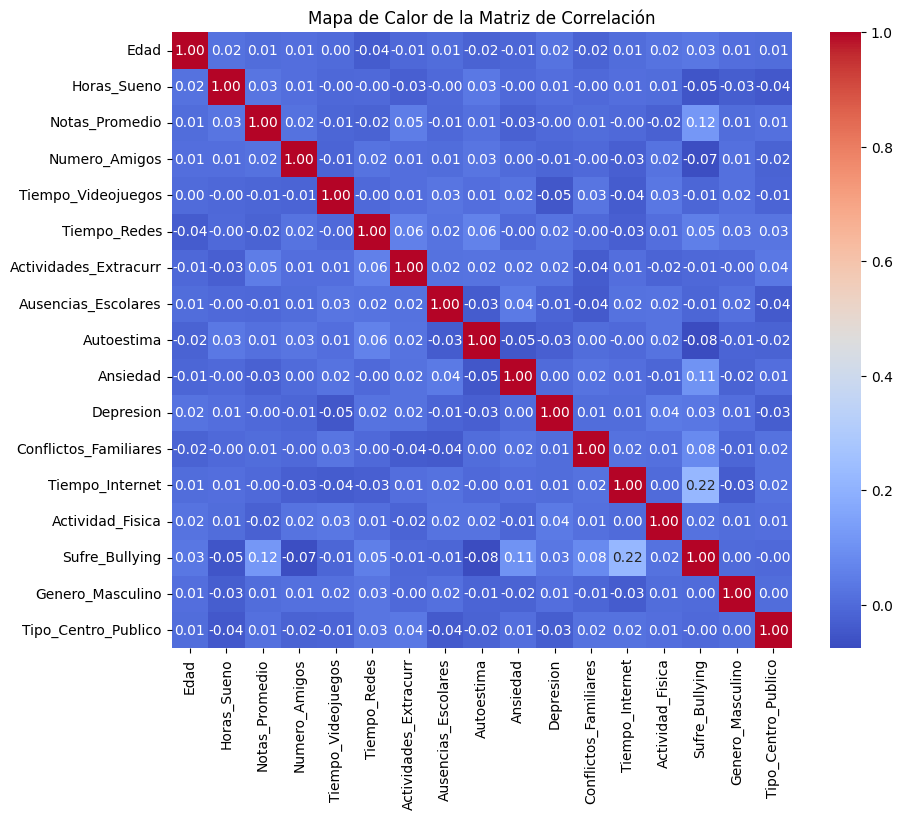

In [ ]:
# Cálculo de la matriz de correlación de Pearson (es el método por defecto)
matriz_correlacion = bullying1.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion,
            annot=True,       # Muestra los valores numéricos
            cmap='coolwarm',  # Usa colores que destacan positivo/negativo
            fmt=".2f")        # Limita los decimales a dos
plt.title('Mapa de Calor de la Matriz de Correlación')
plt.show()

Como podemos observar en la matriz, no existe ninguna correlación fuerte entre las variables predictoras. Todos los coeficientes de correlación están muy por debajo del umbral de 0.75.

- Las correlaciones entre las distintas características son extremadamente bajas, lo que indica que cada una aporta información independiente.
- Incluso las correlaciones con la variable objetivo (*Sufre_Bullying*) son bajas. La más significativa es *Tiempo_Internet* (0.22), seguida de *Notas_Promedio* (0.12) y *Ansiedad* (0.11).

Dado que no hay redundancia evidente entre las características no vemos necesario eliminar ninguna variable.

Y es más, en caso de usar arboles de decisión o random forest nos será incluso beneficioso conservar todas las variables, aunque haya correlación, porque estos modelos no dependen de la independencia lineal de las características y, por el contrario, se benefician de la redundancia.

##### **1.3.1.5 Detección  de outliers**

Ahora realizamos la imputación de outliers. Como ya hemos realizado la división de datos en *train* y *test* previamente, para evitar *data leakage*, las estadísticas de los datos de imputación las vamos a calcular usando únicamente *X_train*.

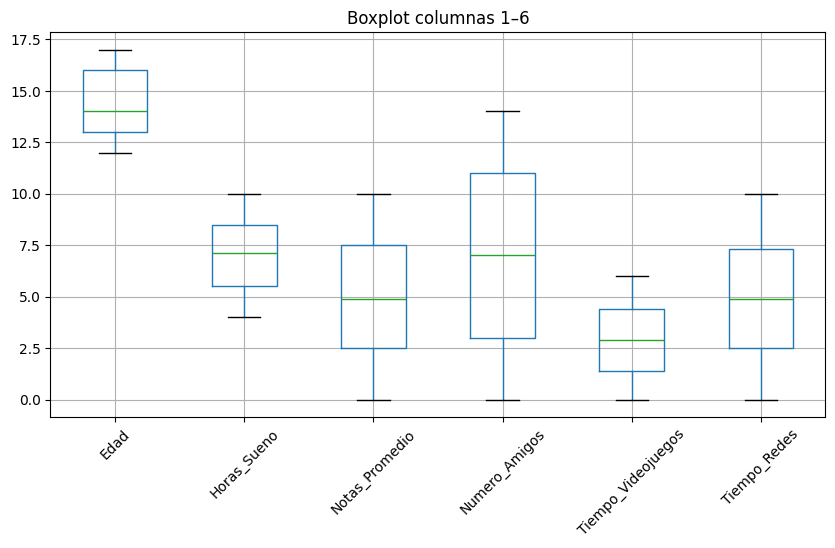

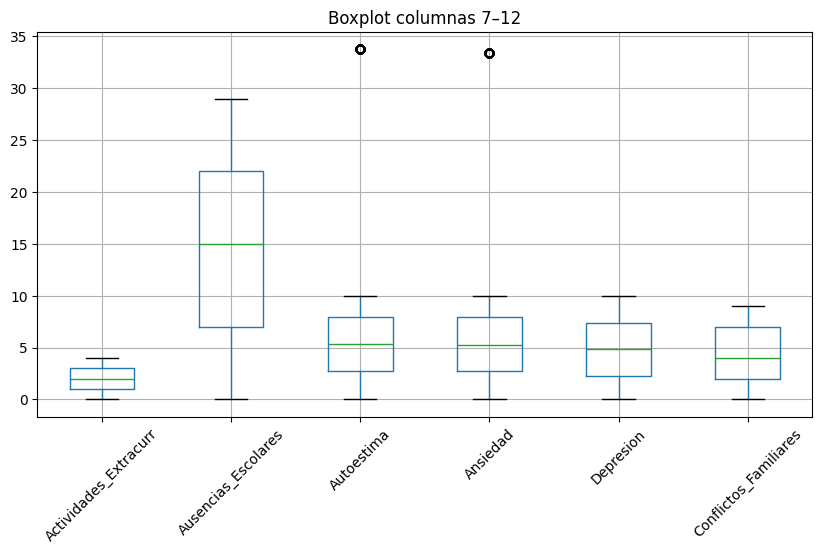

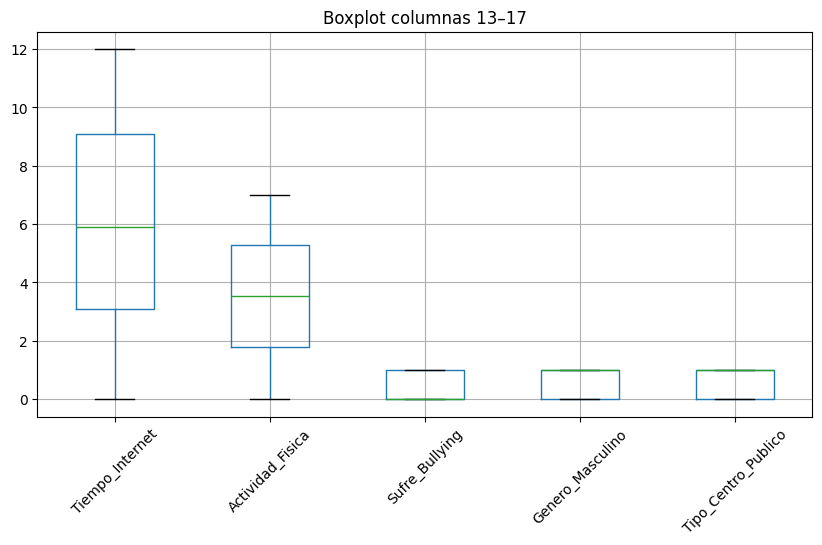

In [ ]:

tam_grupo = 6 # Numero de columnas a mostrar por grupo
columnas = bullying1.columns
# Itera en bloques
for i in range(0, len(columnas), tam_grupo):
    subset = columnas[i:i + tam_grupo]
    bullying1[subset].boxplot(figsize=(10, 5))
    plt.title(f"Boxplot columnas {i+1}–{i+len(subset)}")
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
print("Valores más altos en 'Autoestima'")
# Ordenamos de mayor a menor y vemos los 5 más altos
print(bullying1['Autoestima'].sort_values(ascending=False).head())

print("\n Valores más altos en 'Ansiedad'")
# Ordenamos de mayor a menor y vemos los 5 más altos
print(bullying1['Ansiedad'].sort_values(ascending=False).head())

print("\n Frecuencia de los valores más comunes en 'Autoestima'")
# value_counts() es perfecto para ver valores repetidos
print(bullying1['Autoestima'].value_counts().head())

print("\n Frecuencia de los valores más comunes en 'Ansiedad'")
print(bullying1['Ansiedad'].value_counts().head())

Valores más altos en 'Autoestima'
1429    33.739279
46      33.739279
1955    33.739279
1420    33.739279
1441    33.739279
Name: Autoestima, dtype: float64

 Valores más altos en 'Ansiedad'
1930    33.402491
1990    33.402491
853     33.402491
849     33.402491
789     33.402491
Name: Ansiedad, dtype: float64

 Frecuencia de los valores más comunes en 'Autoestima'
Autoestima
33.739279    100
6.800000      33
7.000000      28
9.400000      28
3.900000      28
Name: count, dtype: int64

 Frecuencia de los valores más comunes en 'Ansiedad'
Ansiedad
33.402491    100
6.200000      33
2.900000      30
3.500000      29
2.100000      28
Name: count, dtype: int64


Las variables "*Autoestima*" y "*Ansiedad*" contienen outliers. Como podemos visualizar en los datos, debido a que se repite exactamente el mismo valor outlier 100 veces, estos podrían deberse más bien a un fallo humano a la hora de añadir estos datos.

Antes de decidir cómo rellenar los valores nulos es importante entender la distribución de los datos. La elección entre imputar con la media o la mediana va a depender de la simetría de la distribución. La media es muy sensible a los valores extremos mientras que la mediana es robusta y no se ve afectada por ellos.

La columna 'Autoestima' tiene sesgo fuerte.
Valor=3.045343434240413
La columna 'Ansiedad' tiene sesgo fuerte.
Valor=3.036806795731376


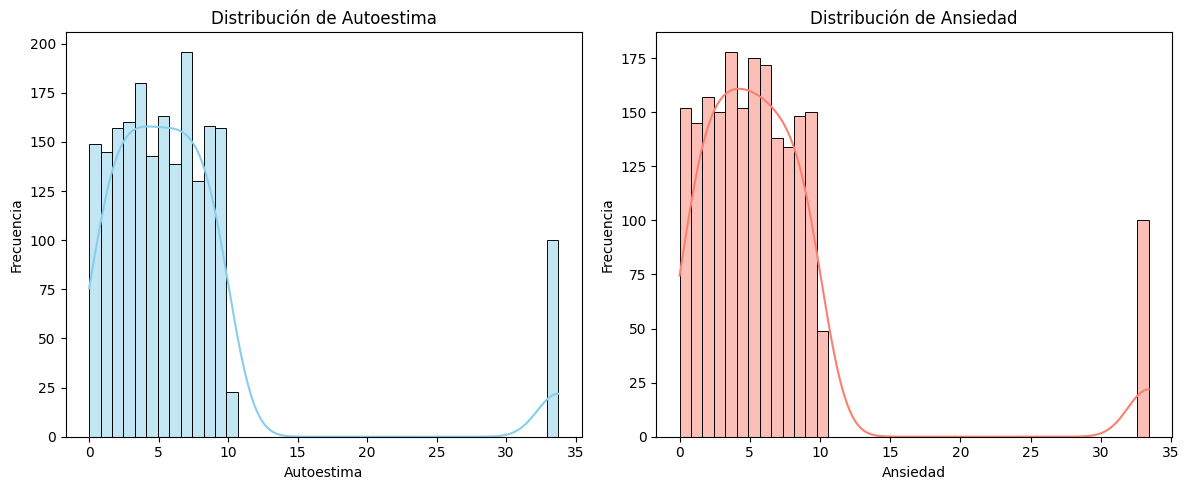

In [ ]:
# Comprobacion de si los datos estan sesgados o no.
sesgo_aut = bullying1["Autoestima"].skew()
if sesgo_aut > 1 or sesgo_aut < -1:
    print(f"La columna 'Autoestima' tiene sesgo fuerte.")
elif sesgo_aut > 0:
    print(f"La columna 'Autoestima' tiene sesgo positivo.")
elif sesgo_aut < 0:
    print(f"La columna 'Autoestima' tiene sesgo negativo.")
else:
    print(f"La columna 'Autoestima' tiene una distribucion normal.")
print(f"Valor={sesgo_aut}")

sesgo_ans = bullying1["Ansiedad"].skew()
if sesgo_ans > 1 or sesgo_ans < -1:
    print(f"La columna 'Ansiedad' tiene sesgo fuerte.")
elif sesgo_ans > 0:
    print(f"La columna 'Ansiedad' tiene sesgo positivo.")
elif sesgo_ans < 0:
    print(f"La columna 'Ansiedad' tiene sesgo negativo.")
else:
    print(f"La columna 'Ansiedad' tiene una distribucion normal.")
print(f"Valor={sesgo_ans}")
# Crear figura con 2 subplots (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: Autoestima
sns.histplot(bullying1["Autoestima"], kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Distribución de Autoestima")
axes[0].set_xlabel("Autoestima")
axes[0].set_ylabel("Frecuencia")

# Subplot 2: Ansiedad
sns.histplot(bullying1["Ansiedad"], kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Distribución de Ansiedad")
axes[1].set_xlabel("Ansiedad")
axes[1].set_ylabel("Frecuencia")

# Ajustar el espacio entre subplots
plt.tight_layout()
plt.show()

Los resultados muestran un sesgo fuerte para ambas columnas (con valores superiores a 3.0 en el coeficiente de asimetría). Esto nos indica que la distribución de los datos no es simétrica y que usar la media para la imputación sería un error.

Dado que tenemos pocos outliers, estos parecen deberse a un error a la hora de añadirlos y la distribución es asimétrica, hemos decidido que vamos a optar por declararlos "Nan" y que sean sustituidos por la mediana cuando tratemos los datos faltantes:

In [ ]:
#CÓDIGO HECHO CON IA

# ============================================
# CONFIGURACIÓN
# ============================================
cols_outliers = ['Autoestima', 'Ansiedad']
cols_nulls = ['Edad', 'Numero_Amigos']
cols_a_imputar = list(set(cols_outliers + cols_nulls))
target = "Sufre_Bullying"


# ============================================
# DETECCIÓN DE OUTLIERS POR IQR (train)
# ============================================
def obtener_limites_outliers(df, cols):
    """
    Calcula los límites inferior y superior de outliers para cada columna usando el método IQR.

    Este método se basa en:
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

    Args:
        df (pd.DataFrame):
            DataFrame de entrada (generalmente X_train) con valores numéricos.
        cols (list[str]):
            Lista de columnas numéricas sobre las que se calcularán los límites de outliers.

    Returns:
        dict:
            Diccionario con la forma:
            {
                "columna": {
                    "lower": valor_limite_inferior,
                    "upper": valor_limite_superior
                },
                ...
            }
    """
    limites = {}

    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        limites[col] = {"lower": lower, "upper": upper}

    return limites

# ============================================
# MARCAR OUTLIERS COMO NAN
# ============================================
def convertir_outliers_a_nan(df, limites):
    """
    Reemplaza los valores considerados outliers por NaN,
    utilizando los límites previamente calculados con obtener_limites_outliers().

    Args:
        df (pd.DataFrame):
            DataFrame de entrada cuyos outliers serán reemplazados por NaN.
        limites (dict):
            Diccionario con límites de outliers por columna
            generado por obtener_limites_outliers().

    Returns:
        pd.DataFrame:
            Copia del DataFrame original, con los outliers reemplazados por NaN.
    """
    df_copy = df.copy()

    for col, bounds in limites.items():
        lower = bounds["lower"]
        upper = bounds["upper"]

        mask_out = (df_copy[col] < lower) | (df_copy[col] > upper)
        df_copy.loc[mask_out, col] = np.nan

    return df_copy

# ============================================
# CALCULAR MEDIANAS POR CLASE
# ============================================
def calcular_medianas_por_clase(df, y, columnas):
    """
    Calcula la mediana por clase (target) para las columnas especificadas.
    Los valores NaN se ignoran automáticamente.

    Args:
        df (pd.DataFrame):
            DataFrame con las variables predictoras.
        y (pd.Series o np.array):
            Vector objetivo correspondiente a df.
        columnas (list[str]):
            Lista de columnas numéricas para las cuales se calcularán medianas por clase.

    Returns:
        dict:
            Diccionario de medianas con estructura:
            {
               "columna": {
                   clase_0: mediana_0,
                   clase_1: mediana_1
               },
               ...
            }
    """
    df_temp = df.copy()
    df_temp[target] = y

    medianas = {}

    for col in columnas:
        medianas[col] = {}
        for clase in df_temp[target].unique():
            mediana = df_temp.loc[df_temp[target] == clase, col].median()

            # fallback: si una clase no tiene valores válidos
            if pd.isna(mediana):
                mediana = df_temp[col].median()

            medianas[col][clase] = mediana

    return medianas

# ============================================
# IMPUTAR NULOS POR CLASE
# ============================================
def imputar_nulos_por_clase(df, y, medianas):
  """
  Imputa valores NaN en columnas numéricas usando la mediana correspondiente
  a la clase del registro. Las medianas se calculan previamente en train.

  Args:
      df (pd.DataFrame):
          DataFrame con valores NaN a imputar.
      y (pd.Series o np.array):
          Vector objetivo correspondiente a df.
      medianas (dict):
          Diccionario generado por calcular_medianas_por_clase(),
          que contiene la mediana por clase para cada columna.

  Returns:
      pd.DataFrame:
          DataFrame con los valores NaN imputados según la clase.
          No incluye la columna objetivo.
  """
  df_copy = df.copy()
  df_copy[target] = y

  for col, clases_dict in medianas.items():
      for clase, valor in clases_dict.items():
          mask = (df_copy[target] == clase) & (df_copy[col].isna())
          df_copy.loc[mask, col] = valor

  return df_copy.drop(columns=[target])

# ============================================
# PIPELINE COMPLETO DE PREPROCESAMIENTO
# ============================================
def preprocesar_dataset(df, y, limites_outliers, medianas, verbose=True):
    """
    Aplica todo el pipeline de preprocesamiento:
        1. Convierte outliers a NaN usando límites predefinidos.
        2. Imputa valores NaN según la mediana por clase.

    Este pipeline puede aplicarse tanto a train como a test,
    siempre que:
        - Los límites de outliers provengan de TRAIN
        - Las medianas provengan de TRAIN

    Args:
        df (pd.DataFrame):
            DataFrame a preprocesar (train o test).
        y (pd.Series o np.array):
            Vector objetivo correspondiente a df.
        limites_outliers (dict):
            Límites generados por obtener_limites_outliers() en TRAIN.
        medianas (dict):
            Medianas generadas por calcular_medianas_por_clase() en TRAIN.
        verbose (bool, optional):
            Si True, muestra información por pantalla.
            Default = True.

    Returns:
        pd.DataFrame:
            DataFrame totalmente procesado:
                - Outliers convertidos a NaN
                - NaN imputados por mediana según clase
    """
    df_proc = df.copy()

    if verbose:
        print(" → Convirtiendo outliers a NaN...")
    df_proc = convertir_outliers_a_nan(df_proc, limites_outliers)

    if verbose:
        print(" → Imputando nulos por clase...")
    df_proc = imputar_nulos_por_clase(df_proc, y, medianas)

    if verbose:
        print(" → Nulos restantes por columna:")
        print(df_proc.isna().sum()[df_proc.isna().sum() > 0])

    return df_proc

In [ ]:
# === 1. Calcular límites de outliers en TRAIN
limites_outliers = obtener_limites_outliers(X_train, cols_outliers)

# === 2. Marcar outliers como NaN en TRAIN
X_train_out = convertir_outliers_a_nan(X_train, limites_outliers)

# === 3. Calcular medianas por clase SOLO CON TRAIN
stats_medianas = calcular_medianas_por_clase(X_train_out, y_train, cols_a_imputar)

# === 4. Preprocesar train y test
print("\nProcesando TRAIN...")
X_train_clean = preprocesar_dataset(X_train, y_train, limites_outliers, stats_medianas)

print("\nProcesando TEST...")
X_test_clean = preprocesar_dataset(X_test, y_test, limites_outliers, stats_medianas)

print("\nPreprocesamiento de nulos y outliers hecho")
print(f"Tamaño X_train_clean: {X_train_clean.shape}")
print(f"Tamaño X_test_clean:  {X_test_clean.shape}")


Procesando TRAIN...
 → Convirtiendo outliers a NaN...
 → Imputando nulos por clase...
 → Nulos restantes por columna:
Series([], dtype: int64)

Procesando TEST...
 → Convirtiendo outliers a NaN...
 → Imputando nulos por clase...
 → Nulos restantes por columna:
Series([], dtype: int64)

Preprocesamiento de nulos y outliers hecho
Tamaño X_train_clean: (1600, 16)
Tamaño X_test_clean:  (400, 16)


In [ ]:
X_train_clean.head()

,Edad,Horas_Sueno,Notas_Promedio,Numero_Amigos,Tiempo_Videojuegos,Tiempo_Redes,Actividades_Extracurr,Ausencias_Escolares,Autoestima,Ansiedad,Depresion,Conflictos_Familiares,Tiempo_Internet,Actividad_Fisica,Genero_Masculino,Tipo_Centro_Publico
717,13.0,8.1,6.4,6.0,0.4,2.9,1,6,7.5,7.0,9.2,5,10.4,6.1,0,1
884,14.0,8.2,7.7,7.0,3.8,6.6,0,15,4.5,4.4,4.7,6,6.4,1.3,0,1
299,14.0,4.5,5.2,5.0,2.1,0.9,2,19,3.4,6.9,1.4,6,5.8,6.8,0,1
1998,14.0,7.5,8.2,12.0,5.9,1.3,4,6,1.7,3.0,7.2,7,0.5,1.7,1,1
658,12.0,6.6,2.2,7.0,4.4,4.0,4,8,1.5,9.5,8.0,7,3.4,2.7,1,1


Qué hace este código:

1. Divide el dataset (train/test) estratificando por la clase (Sufre_Bullying).

2. Estandariza los datos faltantes:
  * Reemplaza los valores anómalos específicos (33.x en Autoestima y Ansiedad) por NaN, tanto en el set de train como en el de test.

3. Calcula estadísticas limpias solo en el train:

  * Calcula la mediana por clase para todas las columnas a imputar (Autoestima, Ansiedad, Edad, Numero_Amigos)

  * Este cálculo ignora automáticamente todos los NaN (los originales y los que acabamos de crear), asegurando que la mediana no esté contaminada por los outliers.

4. Aplica al train y al test:

  * Rellena todos los NaN (los que ya existían en Edad y Numero_Amigos y los que acabamos de crear en Autoestima y Ansiedad) usando la mediana de su clase correspondiente.

5. Evita fugas de datos (data leakage), ya que el set de prueba (X_test_clean) se transforma usando únicamente las medianas aprendidas del set de entrenamiento (X_train_clena).


**A partir de ahora, para aplicar *VarianceThreshold* y el *StandardScaler*, tendremos que usar *X_train_clean* y *X_test_clean*.**


##### **1.3.1.6 Variables con varianza cercana a 0**

Cuando las variables tienen la varianza muy cercana a 0, indican que todos los datos están agrupados alrededor de un valor, por lo que esa variable aporta ninguna o muy poca información, ya que una característica que es prácticamente la misma para todos los estudiantes no tiene poder predictivo por no ser diferenciadora.

A continuación con este código:

1) Separaremos las columnas numéricas de las categóricas (aunque esto ya lo hemos hecho al principio, lo dejamos por precaución ya que la función *VarianceThreshold* no funcionaría con variables categóricas).

2) Calcularemos la varianza solo en los datos de entrenamiento (X_train_clean).

3) Identificaremos las columnas numéricas que no aporten información.

4) Las eliminaremos tanto de X_train_clean como de X_test_clean.

In [ ]:
def columnas_varianza_cero(df, printBool = False):
    """
    Función para obtener la lista de columnas con varianza cercana a 0 de un DataFrame
    - df: DataFrame sobre el que crear el selector
    """
    # Separamos las columnas numéricas y categóricas del dataframe
    df_num = df.select_dtypes(include=np.number)
    df_cat = df.select_dtypes(include='object')
    if(printBool):
        print(f"Columnas numéricas identificadas: {list(df_num.columns)}")
        print(f"Columnas categóricas identificadas: {list(df_cat.columns)}\n")

    # Definimos un umbral de varianza
    # Un valor pequeño como 0.05 elimina columnas casi idénticas.
    UMBRAL_VARIANZA = 0.05

    # Instanciamos el selector
    selector_varianza = VarianceThreshold(threshold=UMBRAL_VARIANZA)

    # Ajustamos el selector con los datos númericos
    selector_varianza.fit(df_num)

    # Obtenemos la máscara de las columnas que queremos mantener
    mask_columnas_mantenidas = selector_varianza.get_support()

    # Obtenemos las columnas a eliminar
    cols_a_eliminar = df_num.columns[~mask_columnas_mantenidas]
    if(printBool):
      print(f"Columnas a aliminar (varianza < {UMBRAL_VARIANZA}):")
      print(list(cols_a_eliminar))

    return cols_a_eliminar


# Obtenemos las columnas con varianza cercana a 0 del conjunto de train
cols_varianza_cero = columnas_varianza_cero(X_train_clean, True)

# Si tenemos columnas que eliminar, las eliminamos de train y test
if len(cols_varianza_cero) > 0:
  X_train_clean = X_train_clean.drop(columns=cols_varianza_cero)
  X_test_clean = X_test_clean.drop(columns=cols_varianza_cero)
  print(f"Nuevo shape X_train_clean: {X_train_clean.shape}")
  print(f"Nuevo shape X_test_clean:  {X_test_clean.shape}")

Columnas numéricas identificadas: ['Edad', 'Horas_Sueno', 'Notas_Promedio', 'Numero_Amigos', 'Tiempo_Videojuegos', 'Tiempo_Redes', 'Actividades_Extracurr', 'Ausencias_Escolares', 'Autoestima', 'Ansiedad', 'Depresion', 'Conflictos_Familiares', 'Tiempo_Internet', 'Actividad_Fisica', 'Genero_Masculino', 'Tipo_Centro_Publico']
Columnas categóricas identificadas: []

Columnas a aliminar (varianza < 0.05):
[]


Ninguna variable tiene varianza cercana a 0 (todas se quedan por encima del umbral) y por tanto no eliminamos columnas.

##### **1.3.1.7 Analisis de desbalanceo**


Ahora vamos a ver si los datos están desbalanceados:

/tmp/ipython-input-551704405.py:5: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(y, sort=True)


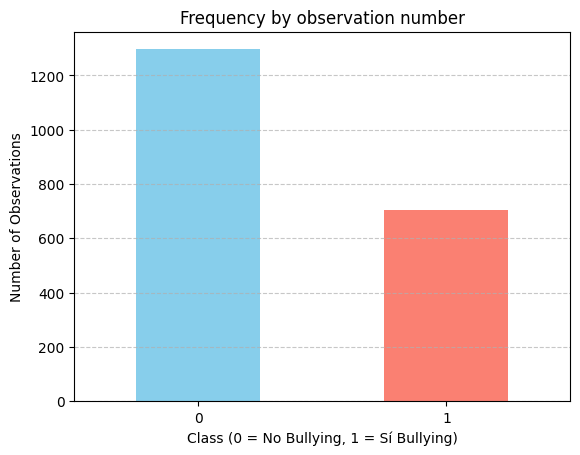


Porcentaje por clase:
 Sufre_Bullying
0    64.8
1    35.2
Name: proportion, dtype: float64


In [ ]:
# extraemos la variable objetivo
y = bullying1['Sufre_Bullying']

# contamos las clases
count_classes = pd.value_counts(y, sort=True)

# hacemos un gráfico de barras
count_classes.plot(kind='bar', rot=0, color=['skyblue', 'salmon'])

plt.title("Frequency by observation number")
plt.xlabel("Class (0 = No Bullying, 1 = Sí Bullying)")
plt.ylabel("Number of Observations")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Porcentaje de cada clase
porcentaje_clases = bullying1['Sufre_Bullying'].value_counts(normalize=True) * 100
print("\nPorcentaje por clase:\n", porcentaje_clases)

Tenemos un 65% de casos sin bullying y un 35% de datos con bullying, lo cual es un caso de desbalanceo moderado. Por tanto:


*   Podremos usar modelos robustos a desbalanceo como random forest o árboles de decisión sin mucho problema, revisando eso sí el **recall** y la **precisión** de la clase minoritaria, ya que si nos dejamos guiar solamente por el *Accuracy* tendremos una falsa sensación de que el modelo funciona bien. Podríamos considerar también probar varios ejemplos de ajustes distintos de peso en árboles o en *redes neuronales* ajustar la métrica *Loss* para que penalice a las clases mayoritarias.

*   Si usamos modelos sensibles al desbalanceo como SVM o regresión logística combiene que hagamos una técnica de oversampling como SMOTE para equilibrar el entrenamiento del modelo.

*También podemos ajustar los pesos de las clases en los modelos (class_weight='balanced').*


Cuando hagamos pruebas con los modelos, a cada dataset utilizado lo probaremos dejando el desbalanceo y corrigiéndolo, para comprobar si mejoran las métricas. Como vamos a utilizar validación cruzada, la corrección del desbalanceo se hará cuando se pruebe cada modelo, y se aplicará sobre cada fold individualmente.

El algoritmo para corregir el desbalanceo será SMOTE. En nuestro caso, hemos decidido no balancear los datos con *Undersampling* porque creemos que, en nuestro caso particular, el dataset no es demasiado grande, el desbalanceo no es extremo y nos va a venir mejor preservar la mayor cantidad de datos posibles porque solo tenemos 2000. Además con oversampling añadimos más casos de "NO_bullying" y se refuerza esta clase.

También podría considerarse usar una técnica de aplicar simultáneamente un algoritmo de subsampling y otro de oversampling a la vez al dataset, pero no creemos que el desbalanceo sea tan extremo como para realizar esto.

**¿Cómo afectará este desbalanceo a la forma que tendremos de evaluar los modelos?**

Utilizar **únicamente** la métrica de **accuracy** sería inadecuado en este contexto. Aunque la accuracy mide el porcentaje total de predicciones correctas, en un dataset desbalanceado esta métrica puede resultar engañosa. Por ejemplo, si nos fijáramos solo en esta métrica, un modelo que predijera siempre la clase mayoritaria (“No sufre bullying”) podría obtener un 80% de acierto sin detectar ningún caso real de bullying.

Por este motivo, vamos a emplear un conjunto de métricas más informativas y orientadas a nuestro objetivo:

- **F2-score (macro)**  
  Utilizamos F2 en lugar de F1 porque penaliza más los falsos negativos, lo cual es coherente con nuestro objetivo de **detectar víctimas reales de bullying**. Además, el promedio *macro* asegura que cada clase contribuya por igual, sin estar influido por el tamaño de cada categoría.

- **Recall de la clase positiva ("Sufre bullying")**  
  Es nuestra métrica crítica. El recall positivo mide qué porcentaje de víctimas reales consigue detectar el modelo.  
  Un recall bajo implica que estaríamos dejando pasar muchos casos reales de bullying, lo cual va en contra del objetivo del proyecto.

- **Accuracy**  
  La incluimos como métrica global independiente, pero no la interpretamos como criterio principal debido al desbalanceo.





Estas métricas permiten evaluar adecuadamente el desempeño del modelo incluso cuando el dataset está desbalanceado, dándonos una visión más completa y útil que la que ofrecería la accuracy por sí sola.


##### **1.3.1.8 Estandarización de los datos**
Muchos algoritmos de machine learning como la Regresión Logística, SVM, KNN o las Redes Neuronales son sensibles a la escala de las variables, por lo que pueden dar una importancia desmesurada a características que tienen rangos de valores más amplios (Ausencias_Escolares, 0-30) en comparación con otras con rangos más pequeños (Autoestima 0-10). Para evitar esto vamos a estandarizar los datos con *StandardScaler*.

Vamos a optar por no estandarizar las variables dummies, ya que estas ya se encuentran en una escala homogénea y perderíamos la fácil interpretabilidad de sus coeficientes 0 y 1.

Es fundamental ajustar (fit) el escalador únicamente con los datos de *X_train_clean* y luego usar ese mismo escalador para transformar ambos conjuntos, *X_train_clean* y *X_test_clean*. Este proceso previene fuga de datos (data leakage).



In [ ]:
def obtener_escalador(df, printBool = False):
    """
    Función para obtener un escalador a partir de un DataFrame
    - df: DataFrame sobre el que crear el escalador
    """
    # Identificamos las columnas a escalar
    cols_a_escalar = df.columns.tolist()
    if(printBool):
        print(f"Columnas a escalar ({len(cols_a_escalar)})")
        print(cols_a_escalar)
        print("\n")

    # Instanciamos el escalador
    scaler = StandardScaler()

    # Ajustamos el escalador en todo el dataframe
    scaler.fit(df)
    return scaler

def estandarizar_dataframe(df, scaler):
    """
    Función para estandarizar un DataFrame a partir de un escalador
    - df: DataFrame a escalar
    - scaler: escalador a usar
    """
    # Transformamos el dataframe
    df_scaled = scaler.transform(df)
    # Convertimos a DataFrame, preservando columnas e índice
    df_standarized = pd.DataFrame(df_scaled, columns=df.columns, index=df.index)
    return df_standarized

In [ ]:
# Creamos el escalador a partir del conjunto de train
scaler = obtener_escalador(X_train_clean, True)

# Estandarizamos train y test usando el escalador
X_train_clean_estandarizados = estandarizar_dataframe(X_train_clean, scaler)
X_test_clean_estandarizados = estandarizar_dataframe(X_test_clean, scaler)

# Verificación final
print(f"Shape X_train_clean_estandarizados: {X_train_clean_estandarizados.shape}")
print(f"Shape X_test_clean_estandarizados:  {X_test_clean_estandarizados.shape}\n")

Columnas a escalar (16)
['Edad', 'Horas_Sueno', 'Notas_Promedio', 'Numero_Amigos', 'Tiempo_Videojuegos', 'Tiempo_Redes', 'Actividades_Extracurr', 'Ausencias_Escolares', 'Autoestima', 'Ansiedad', 'Depresion', 'Conflictos_Familiares', 'Tiempo_Internet', 'Actividad_Fisica', 'Genero_Masculino', 'Tipo_Centro_Publico']


Shape X_train_clean_estandarizados: (1600, 16)
Shape X_test_clean_estandarizados:  (400, 16)



Ahora vamos a hacer un código para eliminar datos nulos y estandarizar los datos de *X_train* y *X_test*. El objetivo es meter estos datos al primer modelo que vamos a implementar, SVM, y comparar el rendimiento con *X_train_clean_estandarizados* y *X_test_clean_estandarizados* para ver si nuestro preprocesamiento ha sido útil o no.


In [ ]:
# CÓDIGO HECHO CON IA
def drop_nulos(X, y):
    """
    Función para eliminar las filas con valor nulo en un Dataset
    - X: Columnas del Dataset
    - y: Columna objetivo
    """
    # Obtenemos los índices válidos (sin NaNs) de X
    idx_validos = X.dropna().index

    # Filtramos X e y para mantener solo esos indices
    X_drop = X.loc[idx_validos].copy()
    y_drop = y.loc[idx_validos].copy()

    return X_drop, y_drop

In [ ]:
# Eliminamos las filas con valores nulos de train y test
X_train_drop, y_train_drop = drop_nulos(X_train, y_train)
X_test_drop, y_test_drop = drop_nulos(X_test, y_test)

print(f"Tamaño original X_train: {len(X_train)}")
print(f"Tamaño X_train después de dropna (solo NaNs): {len(X_train_drop)}\n")


# Creamos el escalador a partir del conjunto de train
scaler_drop = obtener_escalador(X_train_drop)

# Estandarizamos train y test usando el escalador
X_train_drop_estandarizados = scaler_drop.transform(X_train_drop)
X_test_drop_estandarizados = scaler_drop.transform(X_test_drop)

Tamaño original X_train: 1600
Tamaño X_train después de dropna (solo NaNs): 1445



#### **1.3.2 Recapitulando todo lo que hemos hecho hasta ahora**

En términos generales, la calidad del dataset es aceptable: presenta una proporción reducida de valores nulos, los outliers son pocos y fácilmente identificables, y el nivel de desbalanceo es moderado y manejable mediante técnicas como SMOTE.

Sin embargo, el aspecto más limitante es la cantidad de datos disponible, que resulta escasa para obtener modelos robustos y con buena capacidad de generalización. Esta limitación es comprensible considerando el contexto y la naturaleza de la fuente de datos, que no proviene de un entorno especializado en la generación de datos para análisis estadístico o de aprendizaje automático.

El preprocesamiento ha comenzado codificando las variables categóricas "*Genero*" y "*Tipo_Centro*" a valores numéricos (0 ó 1) y, acto seguido, realizando la división *train_test_split* para asegurar que todas las columnas estuvieran presentes en ambos conjuntos. Luego, para evitar data leakage, calculamos las medianas por clase solo en el set de entrenamiento después de convertir los valores outliers a NaN. Usamos estas medianas para imputar todos los valores nulos (tanto los originales como los recién creados) en los conjuntos de entrenamiento y prueba.

 Después hemos estudiado el desbalanceo de los datos y hemos decidido que en la parte del rendimiento de los modelos vamos a comparar 2 enfoques: (1) evaluar los modelos dejando los datos con el menor preprocesamiento posible (con desbalanceo y sin desbalanceo) y (2) evaluar los modelos tras el preprocesamiento (con desbalanceo y sin desbalanceo). Para terminar hemos estandarizado todas las variables, ya que usaremos algunos modelos que son sensibles a la estandarización.
- En `X_train` y `X_test` tenemos los datos crudos únicamente con las variables categóricas convertidas a numéricas.
- En `X_train_drop` y `X_test_drop` tenemos los datos originales después de eliminar los valores nulos NaN.
- En `X_train_drop_estandarizados` y `X_test_drop_estandarizados` tenemos los datos estandarizados con los nulos eliminados.

- En `X_train_clean` y `X_test_clean` nos ha quedado el conjunto de características limpias pero SIN estandarizar.
- Los datos preprocesados estandarizados de características están guardados en `X_train_clean_estandarizados` y `X_test_clean_estandarizados`, y nuestra variable objetivo en `y_train` e `y_test`.




> Aunque podríamos optar por meterle a todos los modelos los datos sin estandarizar y simplificar el número de conjuntos de datos hemos decidido no hacerlo para NO perder la interpretabilidad en los modelos basados en árboles de decisión.



---
### **1.4. Cálculo de rendimiento con modelos sin tratamiento de datos y con tratamiento de datos**

#### **1.4.1 Funciones auxiliares**

Vamos a empezar creando unas funciones auxiliares que usaremos más adelante.

In [ ]:
labels = ["No sufre bullying", "Sufre bullying"]

def extract_report_metrics(y_true, y_pred,
                           y_true_train=None, y_pred_train=None,
                           scenario_name="", best_params=None, beta=2):
    """
    Devuelve precision, recall (weighted), Fβ macro, accuracy (global)
    y métricas centradas en la clase positiva ("Sufre bullying").

    Si se proporcionan métricas de TRAIN, también se devuelven.
    """

    # Índice de la clase positiva
    positive_idx = labels.index("Sufre bullying")

    # --- MÉTRICAS TEST ---
    report_test = classification_report(y_true, y_pred, output_dict=True)

    # Métricas por clase en test
    recall_per_class_test = recall_score(y_true, y_pred, average=None)

    result_test = {
      "scenario": scenario_name,
      "accuracy_test": report_test["accuracy"],         # Métrica global independiente
      "f2_test": fbeta_score(y_true, y_pred, beta=2, average="macro"),  # F2 macro
      "recall_pos_test": recall_per_class_test[positive_idx],  # Clase crítica
    }

    # --- MÉTRICAS TRAIN (si existen) ---
    result_train = {}
    if (y_true_train is not None) and (y_pred_train is not None):
        report_train = classification_report(y_true_train, y_pred_train, output_dict=True)

        # Métricas por clase en train
        recall_per_class_train = recall_score(y_true_train, y_pred_train, average=None)

        result_train = {
            "scenario": scenario_name,
            "accuracy_train": report_train["accuracy"], # Métrica global independiente
            "f2_train": fbeta_score(y_true_train, y_pred_train, beta=beta, average="macro"), # F2 macro
            "recall_pos_train": recall_per_class_train[positive_idx],  # Clase crítica
        }

    # Best params (si existen)
    if best_params is not None:
        result_train["best_params"] = best_params
        result_test["best_params"] = best_params

    return result_train, result_test


def train_and_test_model(title, model_name, model, param_grid, scenarios):
    """
    Función para entrenar y testear un modelo para una lista de escenarios
    - title: Título para mostrar en los escenarios
    - model_name: Nombre del modelo
    - model: Modelo que entrenar y testear
    - param_grid: Grid de parámetros para el modelo
    - scenarios: Lista de escenarios
    """
    # Validación cruzada estratificada
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=semilla)

    # Listas para guardar los resultados
    results_train = []
    results_test = []
    conf_matrices = []

    # Recorremos cada escenario
    for name, Xtr, ytr, Xte, yte, usar_smote in scenarios:
        print(f"\n=== Escenario {title}: {name} ===")

        # Definimos un pipeline con SMOTE para evitar el data-leakage
        if usar_smote:
            # Si el escenario usa SMOTE, creamos un Pipeline
            # Esto asegura que SMOTE se aplica DENTRO de cada fold del CV
            print("Configurando Pipeline con SMOTE...")
            pipeline = Pipeline(steps=[
                ('smote', SMOTE(random_state=semilla)),
                (model_name, model)
            ])
        else:
            # Si es sin SMOTE, usamos un Pipeline normal
            # Usar un pipeline simple mantiene la estructura del código igual
            print("Configurando Pipeline estándar (sin SMOTE)...")
            pipeline = Pipeline(steps=[
                (model_name, model)
            ])

        # GridSearch + CV
        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            cv=cv,
            scoring=make_scorer(fbeta_score, beta=2, average='macro'),
            #scoring=make_scorer(recall_score,pos_label=1),
            n_jobs=-1,
            verbose=1
        )

        # Entrenamiento + búsqueda de mejores hiperparámetros (sin leakage)
        # Le pasamos los datos ESTANDARIZADOS (Xtr, ytr) desbalanceados
        grid_search.fit(Xtr, ytr)

        print(f"Mejores parámetros encontrados: {grid_search.best_params_}")
        print(f"Mejor score CV (F2): {grid_search.best_score_:.4f}")


        # Obtenemos el mejor modelo
        best_model = grid_search.best_estimator_

        # Obtenemos la predicción en training y test
        y_pred_train = best_model.predict(Xtr)
        y_pred_test = best_model.predict(Xte)


        # Obtenemos el reporte de métricas y lo guardamos
        train_metrics, test_metrics = extract_report_metrics(
            y_true=yte,
            y_pred=y_pred_test,
            y_true_train=ytr,
            y_pred_train=y_pred_train,
            scenario_name=name,
            best_params=grid_search.best_params_,
            beta=2
        )
        results_train.append(train_metrics)
        results_test.append(test_metrics)

        # Guardamos la matriz de confusión
        cm = confusion_matrix(yte, y_pred_test)
        conf_matrices.append((name, cm))
        # plot_confusion_matrix(cm, labels, f"Matriz de Confusión: {name}", True)

    # Devolvemos los resultados y las matrices de confusión
    return results_train, results_test, conf_matrices, grid_search


def plot_confusion_matrix(cm, labels, title, percentage=False, ax=None):
    """
    Función unificada para mostrar una matriz de confusión.
    - cm: matriz de confusión
    - labels: etiquetas de clase
    - title: título del gráfico
    - percentage: mostrar porcentajes o números absolutos
    - ax: si se pasa un axis externo → dibuja dentro del subplot
          si es None → crea una figura propia
    """

    # Normalización si procede
    data = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] if percentage else cm

    # Crear figura solo si no se recibió un axis
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots()
        created_fig = True

    # Pintar la matriz
    im = ax.imshow(data, interpolation='nearest', cmap=plt.cm.Blues)

    # Colorbar solo si es figura independiente
    if created_fig:
        ax.figure.colorbar(im, ax=ax)

    # Configurar ejes
    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        title=title,
        ylabel='Etiqueta Verdadera',
        xlabel='Etiqueta Predicha'
    )

    # Valores en las celdas
    fmt = '.2f' if percentage else 'd'
    thresh = data.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, format(data[i, j], fmt),
                ha="center", va="center",
                color="white" if data[i, j] > thresh else "black"
            )

    # Ajustar layout solo si la figura se creó aquí
    if created_fig:
        fig.tight_layout()
        plt.show()


def plot_metrics_heatmap(title, results):
    """
    Función para mostrar una heatmap de métricas
    - title: Título para mostrar
    - results: Lista de resultados
    """
    # Convertir la lista de resultados a un dataframe
    df_results = pd.DataFrame(results)
    # Mostramos el dataframe
    print(f"\nMétricas comparativas ({title})")
    display(df_results)

    # Seleccionamos solo las columnas numéricas para plotear
    numeric_cols = df_results.select_dtypes(include=['number']).columns
    # -------------------------------------------------

    # Crear el heatmap
    plt.figure(figsize=(10, 5)) # Tamaño de la figura
    sns.heatmap(
        df_results.set_index("scenario")[numeric_cols],
        annot=True,
        fmt=".3f",
        cmap="Blues",
        linewidths=.5
    )
    plt.title(f"Comparación de métricas {title} por escenario")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()


def plot_scenarios_confusion_matrix(title, conf_matrices):
    """
    Función para mostrar las matrices de confusión generadas para una lista de escenarios
    - title: Título para mostrar en los escenarios
    - conf_matrices: Lista de matrices de confusión
    """
    # Obtenemos la lista de escenarios
    num_scenarios = len(conf_matrices)

    # Creamos una figura de matplotlib con 'num_scenarios' subplots, uno al lado del otro
    fig, axes = plt.subplots(1, num_scenarios, figsize=(6 * num_scenarios, 6))

    # Lo convertimos en lista para que el bucle 'for' funcione
    if num_scenarios == 1:
        axes = [axes]

    print(f"\n=== Matrices de Confusión ({title}) ===")
    # Iteramos sobre los ejes (axes) y las matrices de confusión guardadas
    for ax, (title, cm) in zip(axes, conf_matrices):
        # Mostramos la matriz de confusión indicando el eje
        plot_confusion_matrix(
            cm,
            labels,
            f"Matriz: {title}",
            percentage=True,
            ax=ax
        )

    plt.tight_layout()
    plt.show()

def plot_train_test_bars(results_train, results_test):
    """
    Función para mostrar un gráfico de barras comparando F2 de train y test por escenario
    - results_train: Lista de resultados de train
    - results_test: Lista de resultados de test
    """
    # Convertimos a DataFrame
    df_train = pd.DataFrame(results_train)
    df_test = pd.DataFrame(results_test)

    # Calculamos el número de escenarios
    scenarios = df_train["scenario"]
    n = len(scenarios)
    x = np.arange(n)

    # Anchura de las barras
    width = 0.35

    # Creamos la figura
    plt.figure(figsize=(12, 6))

    # Barras de Train
    plt.bar(x - width/2, df_train["f2_train"], width, label="Train", color="skyblue")
    # Barras de Test
    plt.bar(x + width/2, df_test["f2_test"], width, label="Test", color="salmon")

    # Añadimos los valores encima de la barra
    for i in range(n):
        plt.text(x[i] - width/2, df_train.loc[i, "f2_train"] + 0.01, f'{df_train.loc[i, "f2_train"]:.2f}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
        plt.text(x[i] + width/2, df_test.loc[i, "f2_test"] + 0.01, f'{df_test.loc[i, "f2_test"]:.2f}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Configuración del gráfico
    plt.xticks(x, scenarios)
    plt.ylabel("F2 Score")
    plt.title("Comparación F2 Train vs Test por escenario")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

#### **1.4.2 SVM no lineal con kernel RBF**

Para nuestra primera prueba vamos a elegir un modelo que tenga una complejidad moderada, la suficiente como para que pueda generar buenos resultados pero sin llegar a la complejidad de un ensamble. Nuestro objetivo es comprobar, comparando los resultados entre modelos de diferente complejidad, si nuestro problema requiere modelos más complejos como los ensembles, o si uno más sencillo nos bastaría.

Para esta prueba hemos elegido un SVM. En concreto vamos a usar un kernel RBF, que es más complejo que los kernels lineales o polinomiales, y consiste en proyectar unos datos no linealmente separables a un espacio con más dimensiones que sí pueda ser separable por un hiperplano. Este modelo suele funcionar muy bien en problemas de clasificación binaria, sobre todo en problemas con dimensionalidad moderada y datasets medianos como es nuestro caso.

Como este modelo debe medir distancias, los datos deben estar estandarizados, ya que si no el modelo daría más importancia a variables con un rango más amplio sin que realmente la tengan. También debemos eliminar o imputar los valores nulos por esta misma razón.

Por ello, vamos a comparar el rendimiento del SVM en cuatro escenarios:

- Datos Drop estandarizados sin SMOTE: Entrenando GridSearchCV directamente sobre el conjunto X_train_drop_estandarizados.

- Datos Drop estandarizados con SMOTE: Entrenando GridSearchCV sobre X_train_drop_estandarizados, pero usando un Pipeline que aplica SMOTE de forma segura dentro de cada fold de la validación cruzada.

- Datos Clean estandarizados sin SMOTE: Entrenando GridSearchCV directamente sobre el conjunto X_train_clean_estandarizados.

- Datos Clean estandarizados con SMOTE: Entrenando GridSearchCV sobre
X_train_clean_estandarizados y aplicando SMOTE dentro del Pipeline para evitar el data leakage.

In [ ]:
# Escenarios de prueba para SVM
scenarios_svm = [
    # (nombre,                      Xtr,                             ytr,            Xte,                             yte,            usar_smote)

    # Escenario 1: Drop SIN SMOTE
    ("Drop std (sin SMOTE)",              X_train_drop_estandarizados,     y_train_drop,   X_test_drop_estandarizados,      y_test_drop,    False),

    # Escenario 2: Drop CON SMOTE
    # (Pasamos los datos originales "drop", el pipeline hará SMOTE dentro del CV)
    ("Drop std (con SMOTE)",              X_train_drop_estandarizados,     y_train_drop,   X_test_drop_estandarizados,      y_test_drop,    True),

    # Escenario 3: Clean SIN SMOTE
    ("Clean std (sin SMOTE)",              X_train_clean_estandarizados,    y_train,        X_test_clean_estandarizados,     y_test,         False),

    # Escenario 4: Clean CON SMOTE
    # (Pasamos los datos originales "clean", el pipeline hará SMOTE dentro del CV)
    ("Clean std (con SMOTE)",               X_train_clean_estandarizados,    y_train,        X_test_clean_estandarizados,     y_test,         True)
]

"""
Parámetros de SVM
- svm__C: Define cuanto penaliza el modelo un error de clasificación.
- svm__gamma: Define cuanto influye cada punto de entrenamiento al definir la frontera.
- svm__kernel: Kernel para SVM. Como hemos dicho, usaremos rbf.
"""
# Grid de hiperparámetros para el modelo SVM
param_grid_svm = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", "auto", 0.01, 0.001],
    "svm__kernel": ["rbf"]
}

# Modelo base de SVM
base_model_svm = svm.SVC(random_state=semilla, probability=True)

# Probamos el modelo
results_train_svm, results_test_svm, conf_matrices_svm, grid_svm = train_and_test_model("SVM", "svm", base_model_svm, param_grid_svm, scenarios_svm)


=== Escenario SVM: Drop std (sin SMOTE) ===
Configurando Pipeline estándar (sin SMOTE)...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Mejores parámetros encontrados: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Mejor score CV (F2): 0.6838

=== Escenario SVM: Drop std (con SMOTE) ===
Configurando Pipeline con SMOTE...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Mejores parámetros encontrados: {'svm__C': 100, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Mejor score CV (F2): 0.6939

=== Escenario SVM: Clean std (sin SMOTE) ===
Configurando Pipeline estándar (sin SMOTE)...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Mejores parámetros encontrados: {'svm__C': 100, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Mejor score CV (F2): 0.7308

=== Escenario SVM: Clean std (con SMOTE) ===
Configurando Pipeline con SMOTE...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Mejores parámetros encontrados: {'svm__C': 1, 'svm__gamm

##### **1.4.2.1 Metricas SVM**


Métricas comparativas (SVM)


,scenario,accuracy_test,f2_test,recall_pos_test,best_params
0,Drop std (sin SMOTE),0.736842,0.703312,0.587302,"{'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke..."
1,Drop std (con SMOTE),0.745152,0.730980,0.698413,"{'svm__C': 100, 'svm__gamma': 0.01, 'svm__kern..."
2,Clean std (sin SMOTE),0.767500,0.733613,0.609929,"{'svm__C': 100, 'svm__gamma': 0.01, 'svm__kern..."
3,Clean std (con SMOTE),0.762500,0.746761,0.702128,"{'svm__C': 1, 'svm__gamma': 'auto', 'svm__kern..."


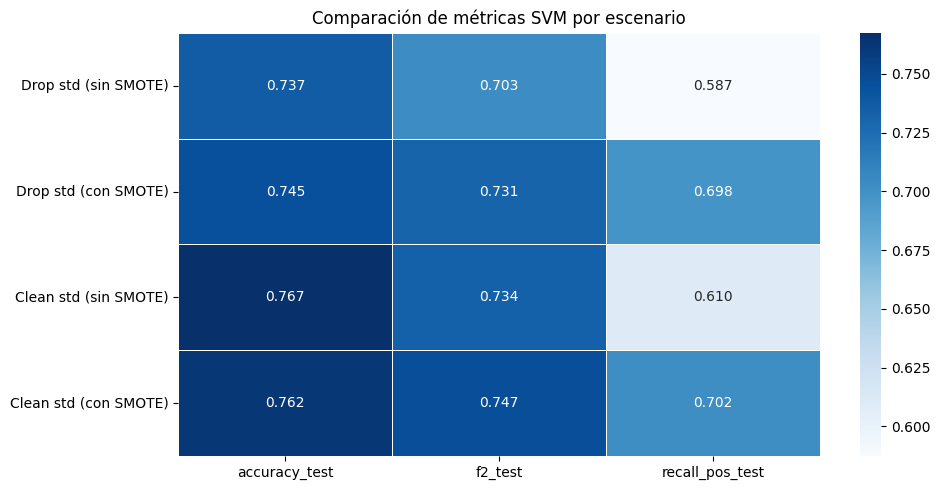

In [ ]:
# Mostramos el mapa de calor con las métricas
plot_metrics_heatmap("SVM", results_test_svm)

En los resultados podemos ver que el modelo ha generado en los diferentes escenarios una precisión de 73%-76%, notandose una mejora al utilizar los datos preprocesados. Si vemos el recall, podemos apreciar que se ve un 60% para los escenarios sin SMOTE Y UN 70% aproximadamente para los escenarios con SMOTE. Al ser un dataset desbalanceado, podemos ver que generar datos de la clase minoritaria con SMOTE le permite al modelo predecir mejor estás instancias, y por ello generar un recall más alto. En nuestro problema, nos importa mucho adivinar los verdaderos positivos, sobre todo para el caso de que un alumno sufra bullying, por lo que esta diferencia es bastante sustancial, y para el caso de este modelo siempre nos interesaría utilizar SMOTE. En el caso del f2, teniendo en cuenta que el recall es mayor para los escenarios en los que se ha utilizado SMOTE, el f2 también será más alto, siendo 70%-73% para los escenarios sin SMOTE y 73%-75% para los escenarios con SMOTE. En general, consideramos que el f2 no es demasiado alto, por lo que preveemos que este problema es lo suficiente complejo como para necesitar modelos más potentes.

##### **1.4.2.2 Matriz de confusion**


=== Matrices de Confusión (SVM) ===


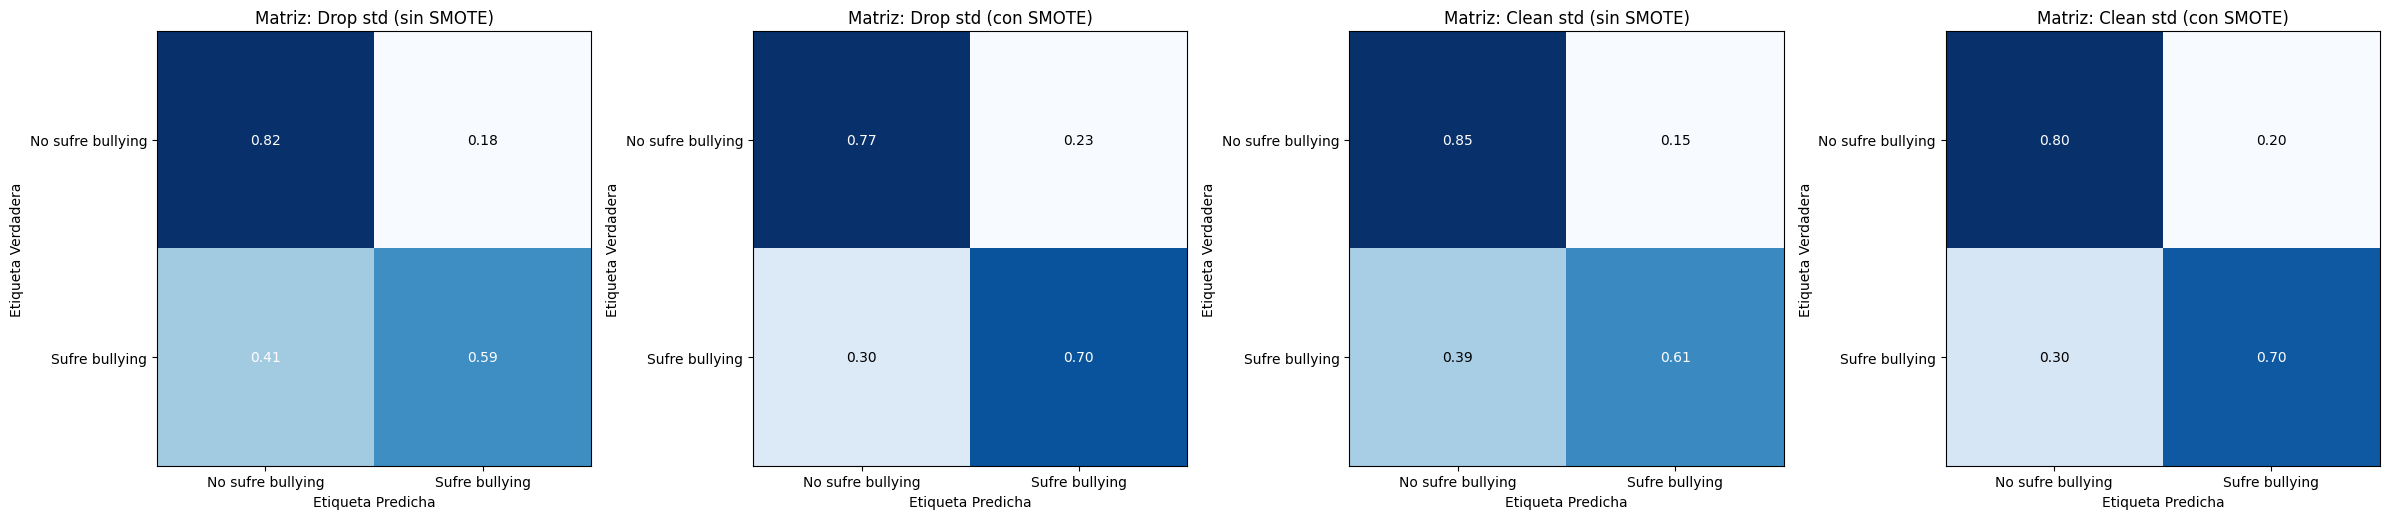

In [ ]:
# Mostramos las matrices de confusión obtenidas
plot_scenarios_confusion_matrix("SVM", conf_matrices_svm)

En la matriz de correlación podemos observar que el modelo predice bastante aceptable los alumnos que no sufren bullying, rondando un 80% para todos los escenarios. Sin embargo, para nosotros es más importante detectar los alumnos que sufren bullying, y justo para clasificar este caso el modelo funciona peor. Por el desbalanceo en clases, podemos observar en los escenarios sin aplicar SMOTE que el modelo predice solo un 60% de los alumnos con bullying, mientras que en los escenarios aplicando SMOTE si que podemos alcanzar un 70%, que es una mejora sustancial.

##### **1.4.2.3 Comprobación Overfitting**

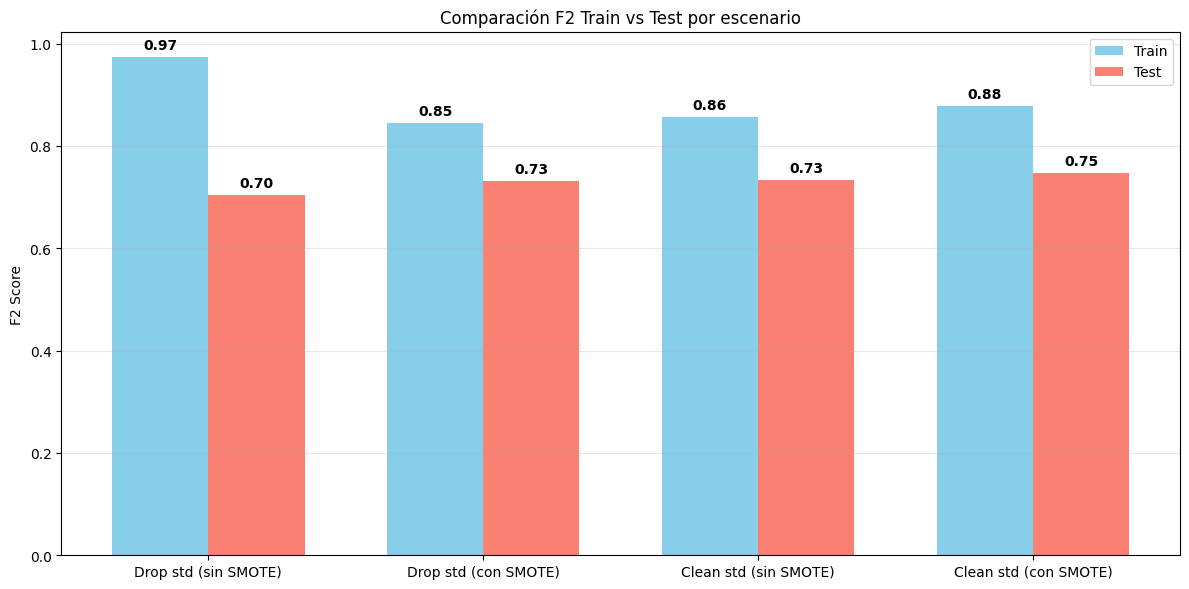

In [ ]:
# Mostramos el f2 obtenido en train y test
plot_train_test_bars(results_train_svm, results_test_svm)

Viendo este gráfico, podemos observar que en el primer escenario hemos obtenido un f2 en training del 97% y un 70% en test, y para el resto de escenarios hemos obtenido un 85%-88% en training y un 73%-75% en test. Esto implica que, para todos los casos, hay como mínimo un 12% de diferencia entre training y test. Esto significa que el modelo está teniendo un overfitting bastante alto, y los resultados obtenidos en test no son fiables.

#### **1.4.3 Boosting**

El boosting busca mejorar la precisión de los modelos predictivos combinando varios modelos "débiles" (que funcionan ligeramente mejor que una predicción aleatoria) en uno solo muy potente. En el contexto de nuestro problema, en el cuál nos importa mucho el *Recall*, es buena idea aplicar el boosting para intentar generar un predictor muy preciso, a costa de un tiempo de ejecución mayor.

En nuestro caso la implementación que vamos a utilizar es *XGBoost*. *XGBoost* es una libreria optimizada y distribuida de gradient boosting, diseñada para ser altamente eficiente, flexible y portatil. Su versatilidad y los buenos resultados que puede llegar a generar son los motivos por los cuales vamos a probar esta implementación.

Como XGBoost es un modelo basado en árboles de decisión, NO es sensible a la estandarización de los datos, pero para mantener una coherencia con otros que sí requieren estandarización, nuestra evaluación utilizará los mismos conjuntos de datos ya estandarizados que se prepararon para esos modelos. Así la evaluación comparará el rendimiento en 4 escenarios:

- Datos Drop estandarizados sin SMOTE: Entrenando sobre X_train_drop_estandarizados e y_train_drop.

- Datos Drop estandarizados con SMOTE: Entrenando sobre X_train_drop_estandarizados e y_train_drop (con SMOTE aplicado dentro del Pipeline).


- Datos Clean estandarizados sin SMOTE: Entrenando sobre X_train_clean_estandarizados e y_train.

- Datos Clean estandarizados con SMOTE: Entrenando sobre X_train_clean_estandarizados e y_train (con SMOTE aplicado dentro del Pipeline).

In [ ]:
# Escenarios
# Usamos los sets "clean" y "drop" para mantener la interpretabilidad.
scenarios_xgb = [
    # (nombre,                             Xtr,                             ytr,            Xte,                            yte,            usar_smote)

    # Escenario 1: Drop SIN SMOTE
    ("Drop std (sin SMOTE)",              X_train_drop_estandarizados,     y_train_drop,   X_test_drop_estandarizados,      y_test_drop,    False),

    # Escenario 2: Drop CON SMOTE
    # (Pasamos los datos originales "drop", el pipeline hará SMOTE dentro del CV)
    ("Drop std (con SMOTE)",              X_train_drop_estandarizados,     y_train_drop,   X_test_drop_estandarizados,      y_test_drop,    True),

    # Escenario 3: Clean SIN SMOTE
    ("Clean std (sin SMOTE)",             X_train_clean_estandarizados,    y_train,        X_test_clean_estandarizados,     y_test,         False),

    # Escenario 4: Clean CON SMOTE
    # (Pasamos los datos originales "clean", el pipeline hará SMOTE dentro del CV)
    ("Clean std (con SMOTE)",             X_train_clean_estandarizados,    y_train,        X_test_clean_estandarizados,     y_test,         True)
]

"""
Parámetros de XGBoost
- xgb__n_estimators: Número de árboles que se entrenarán en el boosting.
                     Valor típico 100.
- xgb__eta: Tasa de aprendizaje. Valores típicos 0.01-0.2.
- xgb__max_depth: Profundidad máxima de cada árbol. Valores típicos 3-10.
"""
# Grid de hiperparámetros
param_grid_xgb = {
    "xgb__n_estimators": [100, 200],
    "xgb__max_depth": [3, 5, 8],
    "xgb__eta": [0.1, 0.3]
}

# Modelo base de XGBoost
base_model_xgb = xgb.XGBClassifier(
    objective="binary:logistic",
    tree_method='hist',
    random_state=semilla,
    n_jobs=-1
)

# Probamos el modelo
results_train_xgb, results_test_xgb, conf_matrices_xgb, grid_xgb = train_and_test_model("XGBoost", "xgb", base_model_xgb, param_grid_xgb, scenarios_xgb)


=== Escenario XGBoost: Drop std (sin SMOTE) ===
Configurando Pipeline estándar (sin SMOTE)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores parámetros encontrados: {'xgb__eta': 0.1, 'xgb__max_depth': 8, 'xgb__n_estimators': 200}
Mejor score CV (F2): 0.8404

=== Escenario XGBoost: Drop std (con SMOTE) ===
Configurando Pipeline con SMOTE...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores parámetros encontrados: {'xgb__eta': 0.1, 'xgb__max_depth': 8, 'xgb__n_estimators': 100}
Mejor score CV (F2): 0.8411

=== Escenario XGBoost: Clean std (sin SMOTE) ===
Configurando Pipeline estándar (sin SMOTE)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores parámetros encontrados: {'xgb__eta': 0.1, 'xgb__max_depth': 5, 'xgb__n_estimators': 100}
Mejor score CV (F2): 0.8577

=== Escenario XGBoost: Clean std (con SMOTE) ===
Configurando Pipeline con SMOTE...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores parámetros en

##### **1.4.3.1 Metricas Boosting**


Métricas comparativas (XGBoost)


,scenario,accuracy_test,f2_test,recall_pos_test,best_params
0,Drop std (sin SMOTE),0.867036,0.858805,0.841270,"{'xgb__eta': 0.1, 'xgb__max_depth': 8, 'xgb__n..."
1,Drop std (con SMOTE),0.872576,0.869601,0.880952,"{'xgb__eta': 0.1, 'xgb__max_depth': 8, 'xgb__n..."
2,Clean std (sin SMOTE),0.867500,0.857708,0.829787,"{'xgb__eta': 0.1, 'xgb__max_depth': 5, 'xgb__n..."
3,Clean std (con SMOTE),0.882500,0.878323,0.879433,"{'xgb__eta': 0.3, 'xgb__max_depth': 8, 'xgb__n..."


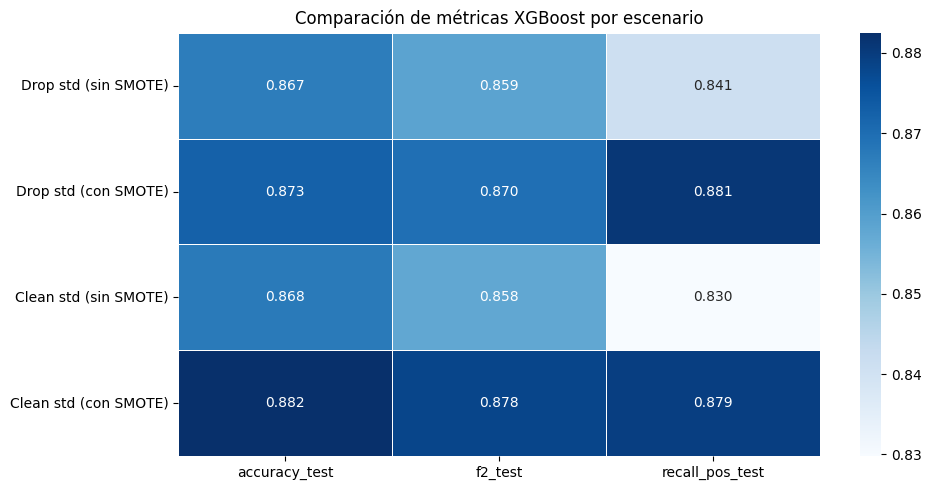

In [ ]:
# Mostramos el mapa de calor con las métricas
plot_metrics_heatmap("XGBoost", results_test_xgb)

En la gráfica, podemos ver que en general la precisión es muy similar, rondando un 86%-88% para todos los escenarios, pero viendose una pequeña mejora de un 1%-2% al utilizar los datos preprocesados. En el caso del recall si podemos ver una mayor diferencia, ya que de un 83%-84% para los escenarios sin SMOTE, estamos subiendo hasta un 88% para los casos con SMOTE, por lo que SMOTE sigue ayudandonos a detectar de mejor manera los verdaderos positivos de la clase minoritaria. Teniendo un recall más alto en los escenarios con SMOTE, el f2 también subirá, teniendo un 86% para escenarios sin SMOTE y un 87%-88% para los escenarios con SMOTE. En este caso, si consideramos que los resultados han sido buenos, y podemos considerar este modelo como un posible candidato a ser elegido como modelo final.

##### **1.4.3.2 Matriz de confusion**


=== Matrices de Confusión (XGBoost) ===


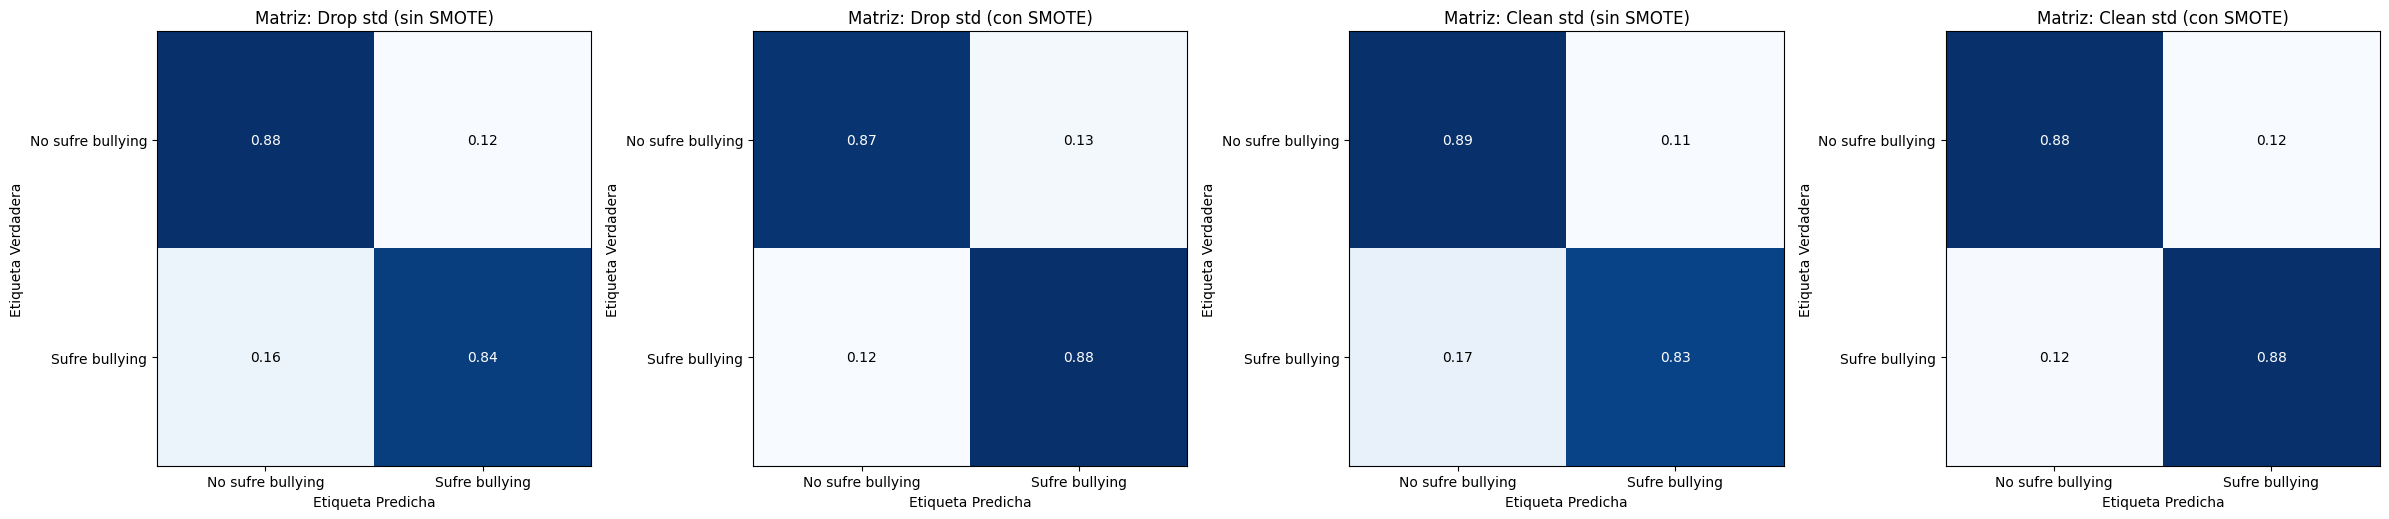

In [ ]:
# Mostramos las matrices de confusión obtenidas
plot_scenarios_confusion_matrix("XGBoost", conf_matrices_xgb)

En esta matriz de correlación si que podemos ver que el modelo en general está funcionando bien para detectar ambas clases, viendo un 87%-88% para los casos de no sufre bullying y un 83%-88% para los casos de sufre bullying. Podemos ver que hay una diferencia del 4% al detectar sufre bullying entre los escenarios sin aplicar SMOTE y aplicandolo, por lo que nuevamente nos está ayudando a detectar más casos de la clase minoritaria.

##### **1.4.3.3 Comprobación Overfitting**

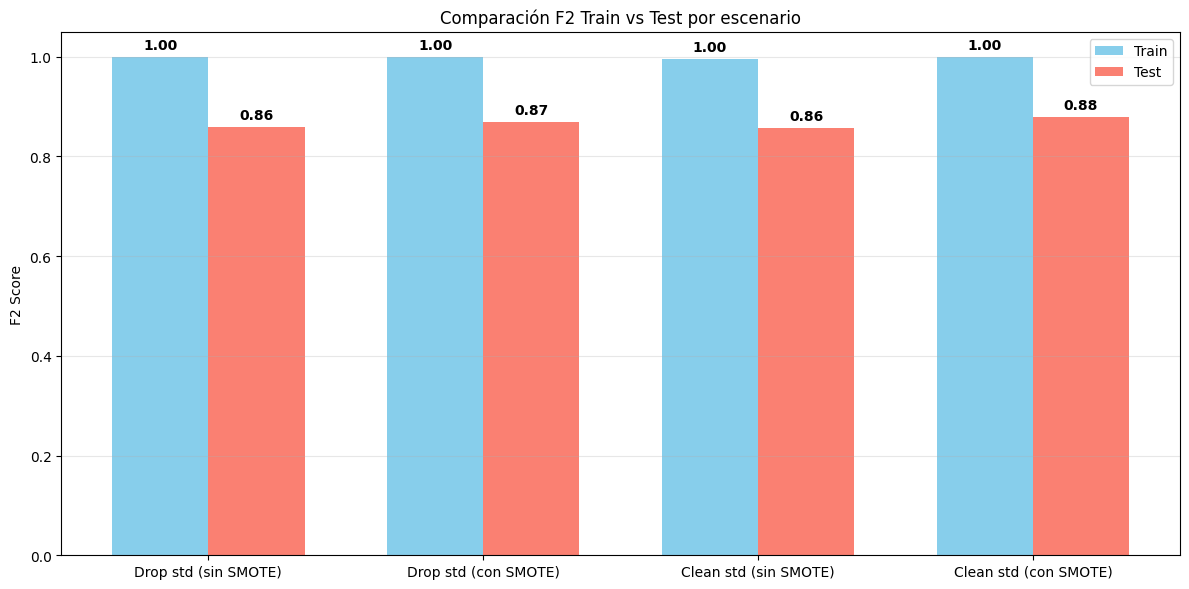

In [ ]:
# Mostramos el f2 obtenido en train y test
plot_train_test_bars(results_train_xgb, results_test_xgb)

En este gráfico podemos ver un 100% de f2 score en training y un 86%-88% en test. En este caso podemos ver de nuevo una diferencia de como mínimo un 12% entre training y test, implicando de nuevo overfitting y que los resultados obtenidos por el modelo no son fiables.

#### **1.4.4 Stacking**
El stacking es una técnica que consiste en entrenar un modelo para combinar las predicciones de otros modelos.La implementación de stacking que vamos a utilizar es la que nos proporciona *StackingClassifier* de la libreria *sklearn*. Una vez elegida la implementación nos queda el paso más importante, que es la elección de modelos para cada una de las capas.

- Para la primera capa vamos a escoger 3 modelos, ya que es un equilibrio entre tener la suficiente diversidad de modelos, pero sin aumentar demasiado el tiempo de entrenamiento ni generar posible ruido por sobreajuste. Lo más importante es que los modelos sean diversos para no generar las mismas salidas.
  - **Naive Bayes**: una de sus carácterísticas principales es que no aprende cuales son las características más importantes para aprender entre clases.
  - **Árboles de decisión**
  - **SVM lineal**: Igual que el modelo probado en el primer apartado, pero esta vez usando el kernel lineal, que es más sencillo.

- Para la capa 2, como la mayoria del trabajo está hecho en la primera capa, sirve con elegir un modelo que sea más sencillo. El modelo que hemos elegido es:
  - Regresión logística: calcula la probabilidad de que un elemento pertenezca a una clase, y usando un umbral elige si pertenece o no. Es un modelo simple que se ajusta bien a lo que buscábamos para esta capa.



Como SVM y Regresión Logística son sensibles a escala y no pueden procesar datos nulos, usaremos los datasets:

- Datos Drop estandarizados sin SMOTE: Entrenando GridSearchCV sobre X_train_drop_estandarizados e y_train_drop

- Datos Drop estandarizados con SMOTE: Entrenando GridSearchCV sobre X_train_drop_estandarizados e y_train_drop, aplicando SMOTE de forma segura dentro del Pipeline.



- Datos Clean estandarizados sin SMOTE: Entrenando GridSearchCV sobre X_train_clean_estandarizados e y_train

- Datos Clean estandarizados con SMOTE: Entrenando GridSearchCV sobre X_train_clean_estandarizados e y_train, aplicando SMOTE de forma segura dentro del Pipeline.

In [ ]:
# Escenarios
scenarios_stacking = [
    # (nombre,                        Xtr,                             ytr,            Xte,                             yte,            usar_smote)

    # Escenario 1: Drop SIN SMOTE
    ("Drop std (sin SMOTE)",              X_train_drop_estandarizados,     y_train_drop,   X_test_drop_estandarizados,      y_test_drop,    False),

    # Escenario 2: Drop CON SMOTE
    # (Pasamos los datos originales "drop", el pipeline hará SMOTE dentro del CV)
    ("Drop std (con SMOTE)",              X_train_drop_estandarizados,     y_train_drop,   X_test_drop_estandarizados,      y_test_drop,    True),

    # Escenario 3: Clean SIN SMOTE
    ("Clean std (sin SMOTE)",             X_train_clean_estandarizados,    y_train,        X_test_clean_estandarizados,     y_test,         False),

    # Escenario 4: "Completo" (Clean) CON SMOTE
    # (Pasamos los datos originales "clean", el pipeline hará SMOTE dentro del CV)
    ("Clean std (con SMOTE)",             X_train_clean_estandarizados,    y_train,        X_test_clean_estandarizados,     y_test,         True)
]


# Estimadores de la primera capa
SC_ESTIMATORS = [('naiveBayes', GaussianNB()),
               ('decisionTree', DecisionTreeClassifier(random_state=semilla)),
               ('svm', svm.SVC(kernel='linear', random_state=semilla, probability=True))]

# Estimador final de la segunda capa
SC_FINAL_ESTIMATOR = LogisticRegression(random_state=semilla)

# Modelo Stacking base
base_model_stacking = StackingClassifier(
    estimators=SC_ESTIMATORS,
    final_estimator=SC_FINAL_ESTIMATOR,
    cv=3
)

"""
Parámetros de Stacking
- stack__final_estimator__C: Inversa de la regularización L2. Valores altos -> menor regularización. Default = 1.0
- stack__final_estimator__penalty: Tipo de regularización a aplicar. Default = "l2"
- stack__final_estimator__solver: Algoritmo usado para optimización."lbfgs" recomendado para problemas pequeños-medianos.
    Default = "lbfgs"
"""
# Grid de hiperparámetros
param_grid_stacking = {
    "stack__final_estimator__C": [0.1, 1, 10],
    "stack__final_estimator__penalty": ["l2"],
    "stack__final_estimator__solver": ["lbfgs"]
}


# Probamos el modelo
results_train_stacking, results_test_stacking, conf_matrices_stacking, grid_stacking = train_and_test_model("Stacking", "stack", base_model_stacking, param_grid_stacking, scenarios_stacking)


=== Escenario Stacking: Drop std (sin SMOTE) ===
Configurando Pipeline estándar (sin SMOTE)...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Mejores parámetros encontrados: {'stack__final_estimator__C': 0.1, 'stack__final_estimator__penalty': 'l2', 'stack__final_estimator__solver': 'lbfgs'}
Mejor score CV (F2): 0.7783

=== Escenario Stacking: Drop std (con SMOTE) ===
Configurando Pipeline con SMOTE...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Mejores parámetros encontrados: {'stack__final_estimator__C': 0.1, 'stack__final_estimator__penalty': 'l2', 'stack__final_estimator__solver': 'lbfgs'}
Mejor score CV (F2): 0.7873

=== Escenario Stacking: Clean std (sin SMOTE) ===
Configurando Pipeline estándar (sin SMOTE)...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Mejores parámetros encontrados: {'stack__final_estimator__C': 0.1, 'stack__final_estimator__penalty': 'l2', 'stack__final_estimator__solver': 'lbfgs'}
Mejor score CV (F2): 0.7849

=== 

##### **1.4.4.1 Metricas Stacking**


Métricas comparativas (Stacking)


,scenario,accuracy_test,f2_test,recall_pos_test,best_params
0,Drop std (sin SMOTE),0.828255,0.800793,0.698413,"{'stack__final_estimator__C': 0.1, 'stack__fin..."
1,Drop std (con SMOTE),0.806094,0.779264,0.682540,"{'stack__final_estimator__C': 0.1, 'stack__fin..."
2,Clean std (sin SMOTE),0.832500,0.810922,0.730496,"{'stack__final_estimator__C': 0.1, 'stack__fin..."
3,Clean std (con SMOTE),0.840000,0.821081,0.751773,"{'stack__final_estimator__C': 10, 'stack__fina..."


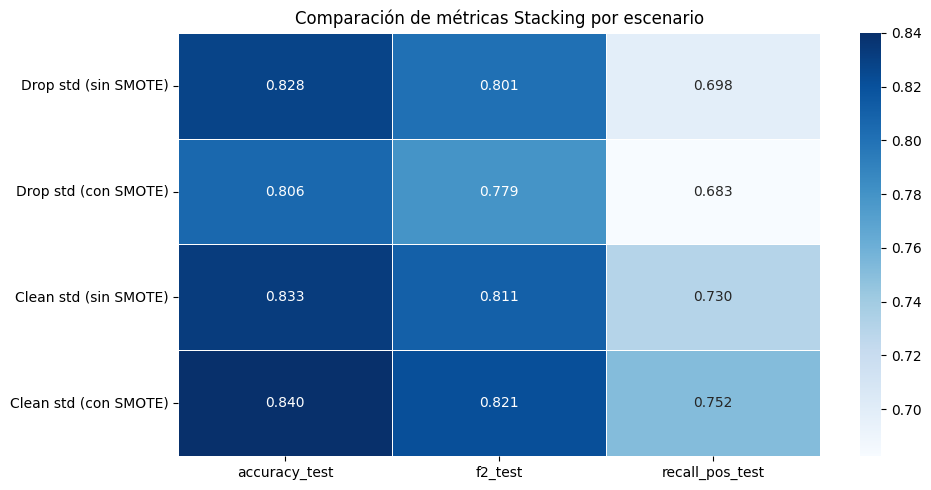

In [ ]:
# Mostramos el mapa de calor con las métricas
plot_metrics_heatmap("Stacking", results_test_stacking)

En este caso, lo más interesante que podemos ver es que se esta consiguiendo una precisión aceptable de 80%-84%, pero el recall está siendo de 68%-75%. Si vemos el caso concreto del escenario con los datos preprocesados y el recall, podemos ver un 84% de precisión frente a un 75% de recall. Esto implica que el modelo no está consiguiendo detectar de forma correcta los verdaderos positivos, que es justo lo que nos interesa en nuestro problema. El f2 obtenido está entre un 78% y un 82%, que son resultados aceptables, pero teniendo en cuenta lo comentado con el recall, no nos parece un modelo interesante a utilizar. En este caso, el problema no tiene que ser culpa de la técnica, si no más bien de los modelos elegidos para las diferentes capas del stacking. Una mejora para esto podría ser añadir más modelos a la primera capa, o que los modelos utilizados sean más complejos, siguiendo la regla de buscar que los modelos sean lo más variados posible.

##### **1.4.4.2 Matriz de confusion**


=== Matrices de Confusión (Stacking) ===


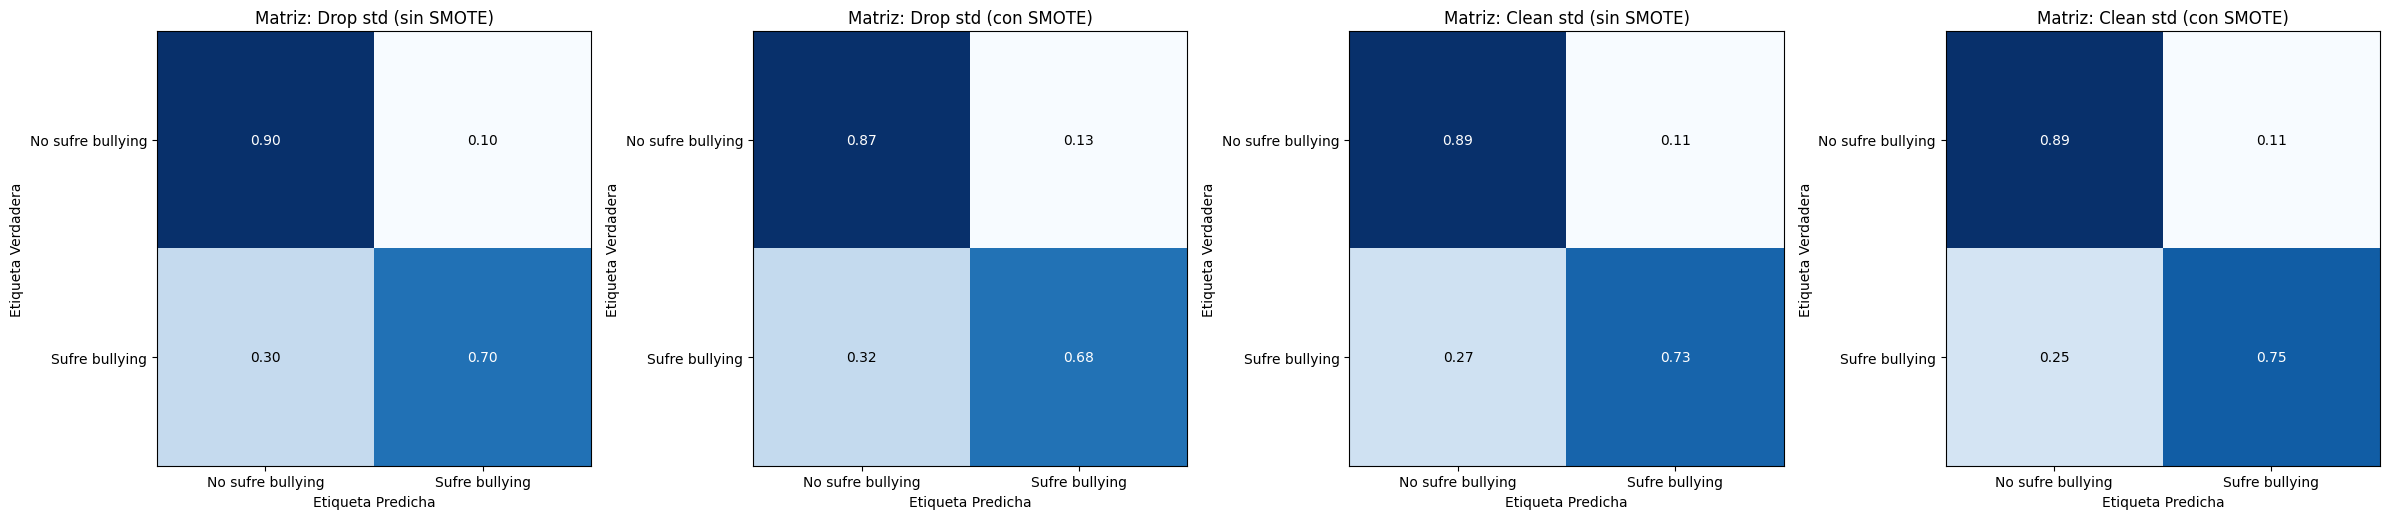

In [ ]:
# Mostramos las matrices de confusión obtenidas
plot_scenarios_confusion_matrix("Stacking", conf_matrices_stacking)

Viendo la matriz de correlación, si que podemos ver que el modelo detecta bastante bien los casos de no bullying, obteniendo un 87%-90%, pero para los casos de bullying está funcionando bastante peor, obteniendo un 68%-75%. Esto explica por que el recall visto en la gráfica era tan bajo, y hace que el modelo no sea tan interesante para nuestro problema.

##### **1.4.4.3 Comprobación Overfitting**

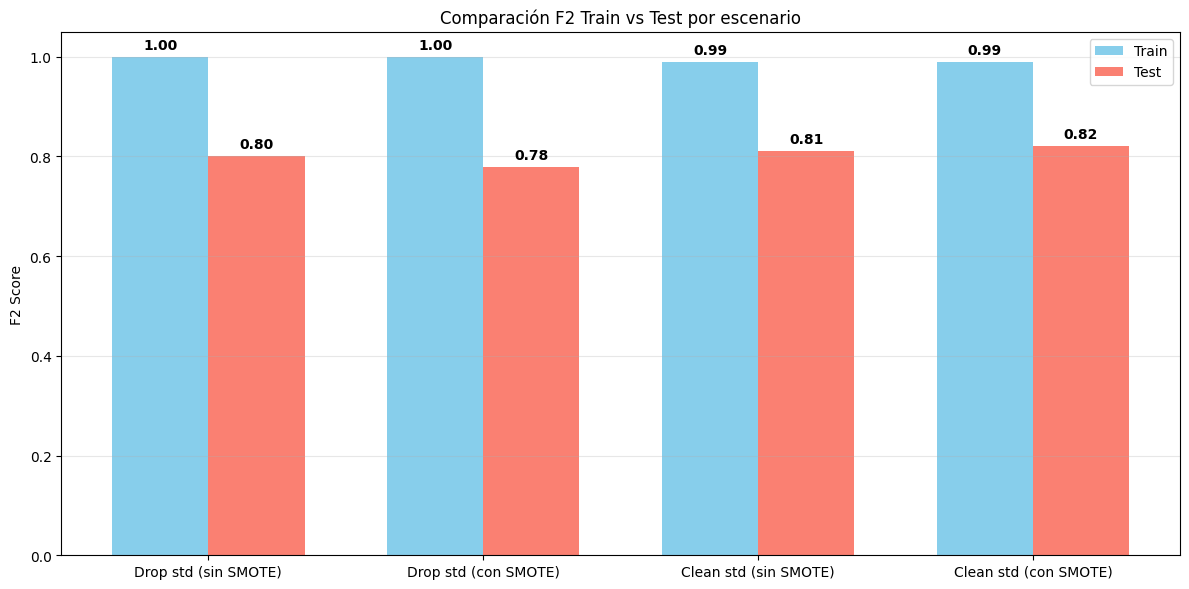

In [ ]:
# Mostramos el f2 obtenido en train y test
plot_train_test_bars(results_train_stacking, results_test_stacking)

Viendo el gráfico podemos ver un f2 del 99%-100% en training y un 78%-82% en test. Podemos ver de nuevo un overfitting bastante alto para todos los escenarios, siendo otra vez los resultados obtenidos poco fiables.

#### **1.4.5 Random Forest**

Random Forest es un método de ensamble pero basado en la técnica de Bagging (Bootstrap Aggregating), combinando muchos árboles de decisión y eligiendo la predicción final mediante votación.

Random Forest se enfoca en reducir la varianza y el sobreajuste, y es una alternativa buena para buscar un alto Recall. La implementación que utilizaremos es RandomForestClassifier de la librería Scikit-learn.

Al igual que XGBoost, Random Forest NO es sensible a la estandarización de los datos, pero para mantener una coherencia con otros que sí requieren estandarización (como SVM o Regresión Logística), nuestra evaluación utilizará los mismos conjuntos de datos ya estandarizados que se prepararon para esos modelos. Así tendremos:


- Datos Drop estandarizados sin SMOTE: Entrenando sobre X_train_drop_estandarizados e y_train_drop.

- Datos Drop estandarizados con SMOTE: Entrenando sobre X_train_drop_estandarizados e y_train_drop (con SMOTE aplicado dentro del Pipeline).

- Datos Clean estandarizados sin SMOTE: Entrenando sobre X_train_clean_estandarizados e y_train.

- Datos Clean estandarizados con SMOTE: Entrenando sobre X_train_clean_estandarizados e y_train (con SMOTE aplicado dentro del Pipeline).

In [ ]:
# ============================================================
# Escenarios (usamos SIEMPRE datos ANTES de SMOTE)
#    OJO: en los "con SMOTE" pon el X_train/Y_train antes de aplicar SMOTE
# ============================================================
scenarios_rf = [
    # (nombre,                        Xtr,                             ytr,            Xte,                             yte,            usar_smote)

    # Escenario 1: Drop SIN SMOTE
    ("Drop std (sin SMOTE)",              X_train_drop_estandarizados,     y_train_drop,   X_test_drop_estandarizados,      y_test_drop,    False),

    # Escenario 2: Drop CON SMOTE
    # (Pasamos los datos originales "drop", el pipeline hará SMOTE dentro del CV)
    ("Drop std (con SMOTE)",              X_train_drop_estandarizados,     y_train_drop,   X_test_drop_estandarizados,      y_test_drop,    True),

    # Escenario 3: Clean SIN SMOTE
    ("Clean std (sin SMOTE)",             X_train_clean_estandarizados,    y_train,        X_test_clean_estandarizados,     y_test,         False),

    # Escenario 4: "Completo" (Clean) CON SMOTE
    # (Pasamos los datos originales "clean", el pipeline hará SMOTE dentro del CV)
    ("Clean std (con SMOTE)",             X_train_clean_estandarizados,    y_train,        X_test_clean_estandarizados,     y_test,         True)
]

# ============================================================
# Grid de hiperparámetros (para el paso 'rf' del pipeline)
# ============================================================
param_grid_rf = {
    "rf__n_estimators": [80, 200],
    "rf__max_depth": [None, 5, 10, 20],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4],
    "rf__max_features": ["sqrt", "log2"],
}

# ============================================================
# Modelo base
# ============================================================
base_rf = RandomForestClassifier(random_state=semilla)

# Probamos el modelo
results_train_rf, results_test_rf, conf_matrices_rf, grid_rf = train_and_test_model("Random Forest", "rf", base_rf, param_grid_rf, scenarios_rf)



=== Escenario Random Forest: Drop std (sin SMOTE) ===
Configurando Pipeline estándar (sin SMOTE)...
Fitting 5 folds for each of 144 candidates, totalling 720 fits
Mejores parámetros encontrados: {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 10, 'rf__n_estimators': 80}
Mejor score CV (F2): 0.8145

=== Escenario Random Forest: Drop std (con SMOTE) ===
Configurando Pipeline con SMOTE...
Fitting 5 folds for each of 144 candidates, totalling 720 fits
Mejores parámetros encontrados: {'rf__max_depth': 10, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 10, 'rf__n_estimators': 80}
Mejor score CV (F2): 0.8301

=== Escenario Random Forest: Clean std (sin SMOTE) ===
Configurando Pipeline estándar (sin SMOTE)...
Fitting 5 folds for each of 144 candidates, totalling 720 fits
Mejores parámetros encontrados: {'rf__max_depth': 10, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 5,

##### **1.4.5.1 Metricas Random Forest**


Métricas comparativas (Random Forest)


,scenario,accuracy_test,f2_test,recall_pos_test,best_params
0,Drop std (sin SMOTE),0.842105,0.824201,0.761905,"{'rf__max_depth': None, 'rf__max_features': 's..."
1,Drop std (con SMOTE),0.869806,0.864845,0.865079,"{'rf__max_depth': 10, 'rf__max_features': 'sqr..."
2,Clean std (sin SMOTE),0.857500,0.843329,0.794326,"{'rf__max_depth': 10, 'rf__max_features': 'sqr..."
3,Clean std (con SMOTE),0.885000,0.882554,0.893617,"{'rf__max_depth': None, 'rf__max_features': 's..."


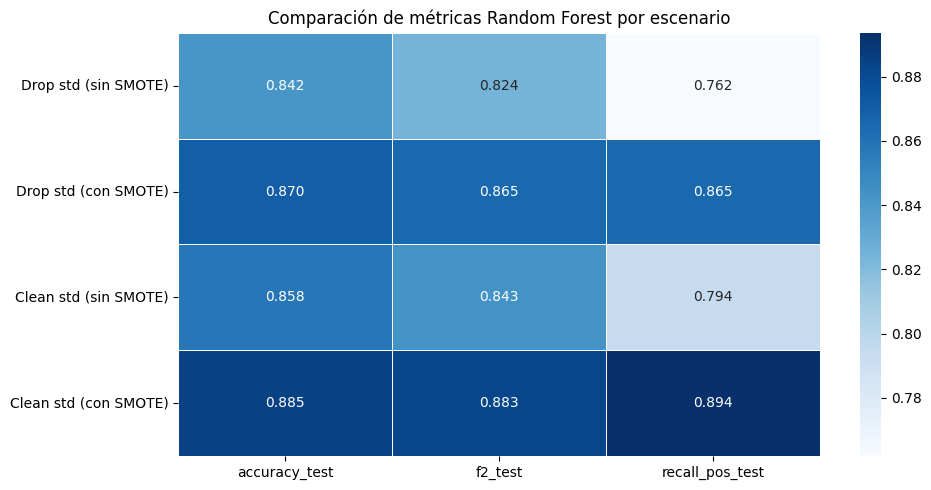

In [ ]:
# Mostramos el mapa de calor con las métricas
plot_metrics_heatmap("Random Forest", results_test_rf)

En el gráfico, podemos ver una mejora en la precisión de 84%-87% para los escenarios sin preprocesamiento con respecto un 86%-88% para los escenarios con preprocesamiento, por lo que preprocesar los datos está mejorando el rendimiento del modelo. A su vez, vemos otra mejora al aplicar SMOTE de 84%-86% al 87%-88%, por lo que aplicar SMOTE está ayudando a clasificar la clase minoritaria. Esto se ve sobre todo en el recall, que vemos un cambio del 76%-80% al 86%-90%, una diferencia bastante significativa. Teniendo en cuenta todas las mejoras aplicadas, podemos mejorar los resultados de un f2 de 82% hasta un 88%. Por resultados, es otro modelo que ha funcionado bastante bien y podría ser un buen candidato. Sin embargo, mientras que el resto de modelos su ejecución ha sido de 1 o 2 minutos, en este caso ha tardado aproximadamente unos 13 minutos porque hemos probado con muchos más parámetros (ejecución realizada en Google Colab). Esto hace que RandomForest pueda ser un candidato a ser elegido como modelo final, pero teniendo en cuenta que hemos tenido que probar con muchos parámetros para obtener buenas métricas y esto conlleva un alto tiempo de ejecución con respecto a los demás modelos.

##### **1.4.5.2 Matriz de confusion**


=== Matrices de Confusión (Stacking) ===


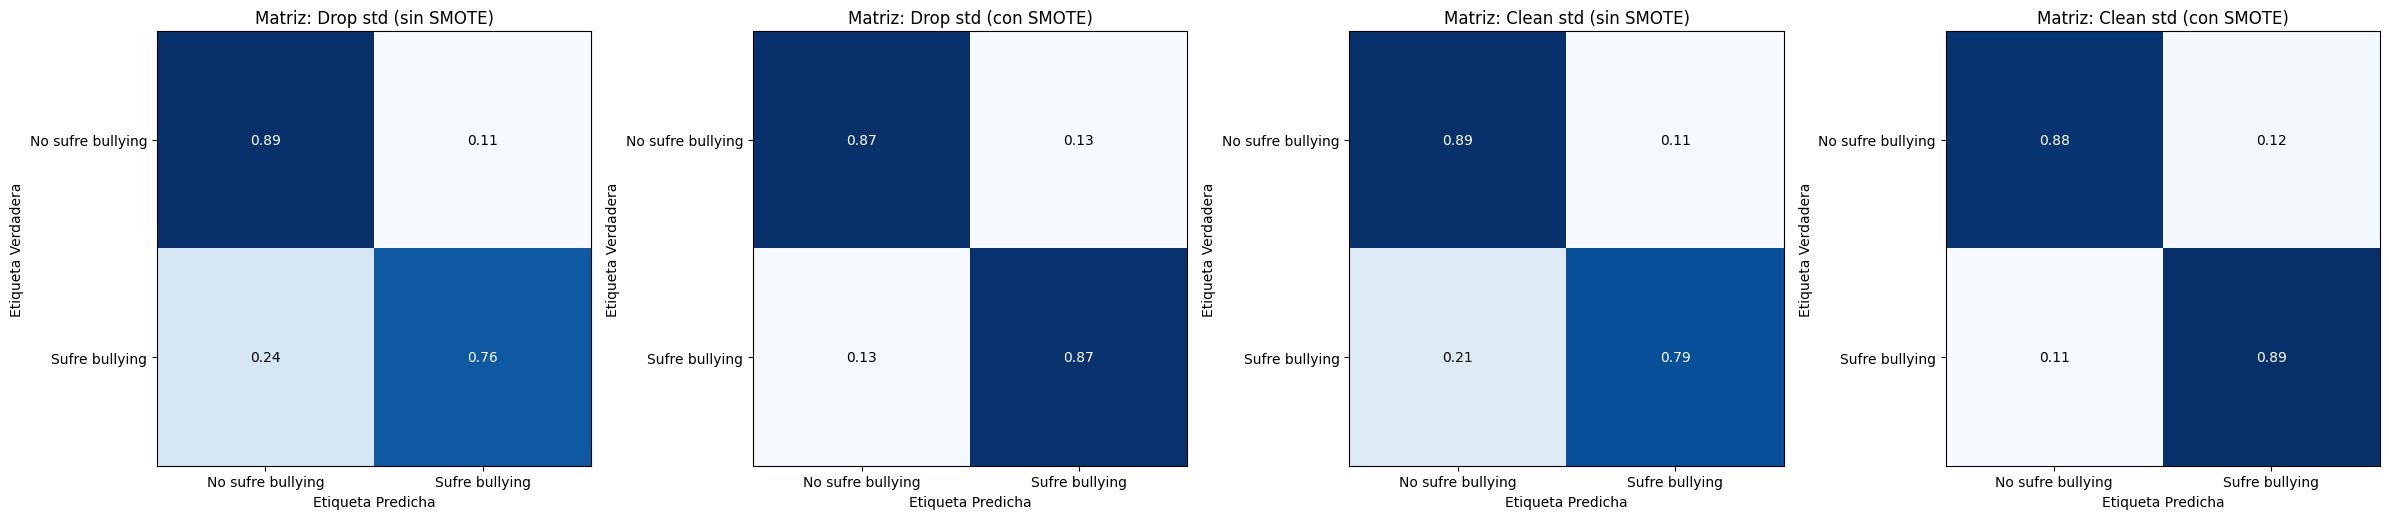

In [ ]:
# Mostramos las matrices de confusión obtenidas
plot_scenarios_confusion_matrix("Stacking", conf_matrices_rf)

En las matrices de confusión podemos ver que el modelo en general ha funcionado bastante bien para predecir los casos de no bullying, teniendo una precisión de 87%-89%. Para la detección de casos de bullying el modelo ha funcionado peor debido al desbalanceo, ya que al aplicar SMOTE podemos ver una mejora del 76%-79% al 87%-89%. Son resultados bastante buenos a la hora de detectar bullying, por lo que efectivamente podemos considerar al modelo como una posible elección de modelo final.

##### **1.4.5.3 Comprobación Overfitting**

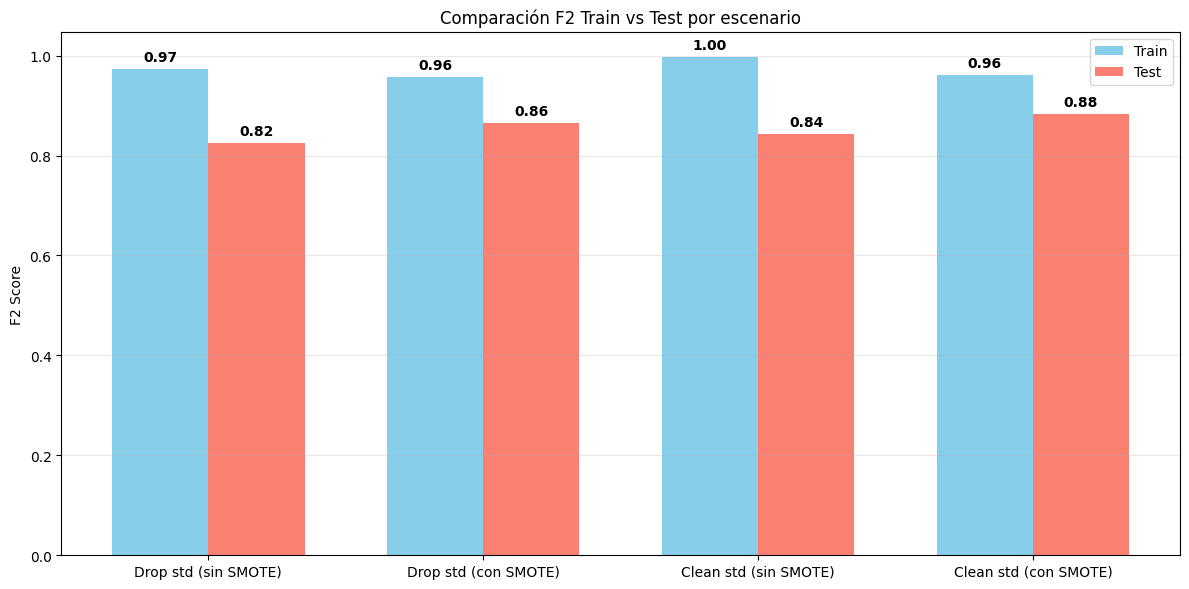

In [ ]:
# Mostramos el f2 obtenido en train y test
plot_train_test_bars(results_train_rf, results_test_rf)

En este gráfico podemos ver un 96%-100% de f2 score en training y un 82%-88% en test. En este caso podemos ver de nuevo una diferencia de como mínimo un 10% entre training y test, excepto en el caso del dataset clean con SMOTE,implicando de nuevo overfitting y que los resultados obtenidos por el modelo no son demasiado fiables en los 3 primeros casos.



#### **1.4.6 Cascading**

El método de **Cascading** es una estrategia de ensamble por etapas en la que un primer clasificador actúa como filtro general, y un segundo clasificador más potente se aplica únicamente sobre los casos dudosos. Es especialmente útil en problemas donde **no podemos permitirnos fallar en la detección de la clase positiva**, como ocurre en la identificación de posibles víctimas de bullying.

Consideramos que este método es adecuado para nuestro proyecto por dos motivos principales:

1. **Los casos negativos (“No sufre bullying”) son mucho más abundantes y fáciles de clasificar**, mientras que los casos positivos y especialmente los ambiguos son más complejos.  
   En este contexto, un primer clasificador con alta sensibilidad puede filtrar la mayor parte de los casos claramente negativos, enviando al siguiente nivel únicamente aquellos que generan cierta sospecha.

2. **El coste de un Falso Negativo es extremadamente alto.**  
   Clasificar incorrectamente a una víctima como “No sufre bullying” implica no detectar una situación de riesgo real. Por el contrario, un Falso Positivo solo implica investigar un caso adicional.  
   Por este motivo, el cascading permite diseñar una primera etapa **optimizada para maximizar el Recall de la clase positiva**, asegurando que prácticamente ningún caso real quede descartado antes de pasar al modelo experto.

En este escenario la métrica crítica es el **recall de la clase positiva**, ya que un FalsoNegativo implica ignorar a una víctima real. Complementariamente, utilizamos el **F2-score (macro)** en la evaluación final, porque otorga más peso a evitar falsos negativos y evalúa por igual ambas clases, independientemente del desbalanceo.

---

### **Implementación del modelo en 2 etapas**

En nuestro caso empleamos un Cascading compuesto por:

---

#### **• Etapa 1: Filtro (Logistic Regression)**

Utilizamos **Regresión Logística** con `class_weight='balanced'`, lo que obliga al modelo a penalizar mucho más los errores en la clase minoritaria. Este diseño lo hace extremadamente sensible ante cualquier indicio de bullying en los escenarios sin balanceo

La búsqueda de hiperparámetros se realiza mediante GridSearchCV optimizando exclusivamente:

- **Recall de la clase positiva**

De esta forma, garantizamos que la Etapa 1 tenga la máxima capacidad posible para no omitir casos reales.  
Un modelo como *Naive Bayes* podría haber sido válido como filtro, pero preferimos Regresión Logística para evitar asumir independencia entre variables.

---

#### **• Etapa 2: Clasificador experto (XGBoost)**

Solo los casos cuya probabilidad de ser positivos supere un **umbral** (por defecto, 0.30) pasan a la Etapa 2.  
Aquí empleamos **XGBoost**, ya que:

- domina patrones no lineales que la Regresión Logística no puede modelar,
- permite ajustar parámetros que penalizan los errores en la clase positiva,
- demostró mejor rendimiento individual en nuestras pruebas preliminares.

En esta etapa, GridSearchCV optimiza:

- **F1-score**

Aunque nuestra evaluación final utiliza F2 y recall positivo para comparar resultados, el uso de F1 como métrica de validación interna permite equilibrar precisión y recall durante la búsqueda de hiperparámetros, especialmente útil al trabajar solo con casos sospechosos.

---

### **Nota sobre el umbral del filtro**

El parámetro más importante del Cascading es el **umbral** aplicado en la Etapa 1:

- **Umbral bajo (ej. 0.10):**  
  → Recall positivo altísimo (prácticamente ningún FN)\
  → A costa de mucha pérdida de precisión (muchos falsos positivos).

- **Umbral alto (ej. 0.50):**  
  → Menos falsos positivos\
  → Pero riesgo elevado de que casos positivos reales no pasen al modelo experto.

> El valor final se eligió equilibrando sensibilidad y capacidad del especialista para refinar la decisión con un valor de 0.15


</div>



In [ ]:
# Cascading no funciona con Pipeline, ni con "cascade__param" como otros modelos.
# Por eso, generamos una función específica pero con la misma interfaz
def train_and_test_cascading(title, scenarios, umbral=0.30):
    """
    Implementa el modelo Cascading en 2 etapas para una lista de escenarios.

    - Etapa 1: LogisticRegression + (opcional SMOTE) + GridSearchCV → optimiza RECALL clase 1
    - Etapa 2: XGBoost + (opcional SMOTE) + GridSearchCV → optimiza F1

    Devuelve:
    - results: lista de métricas por escenario
    - conf_matrices: lista de matrices de confusión por escenario
    """

    print(f"\n================== MODELO: {title} ==================\n")

    results_train = []
    results_test = []
    conf_matrices = []

    # ============================================================
    #                DEFINICIÓN MODELOS BASE
    # ============================================================

    # ------------------------
    # Stage 1
    # ------------------------
    stage1_lr = LogisticRegression(
        class_weight='balanced',
        random_state=semilla,
        solver='liblinear'
    )

    '''
    "lr_C": Parámetro de regularización de la regresión logística,
    trata de evitar que el modelo memorice los datos.
    '''

    stage1_param_grid = {
        "lr__C": [0.01, 0.1, 1, 10, 100]
    }

    cv_stage1 = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=semilla)

    # ------------------------
    # Stage 2
    # ------------------------
    stage2_xgb = xgb.XGBClassifier(
        objective="binary:logistic",
        tree_method="hist",
        random_state=semilla,
        n_jobs=-1
    )


    '''
    xgb__n_estimators: Número de árboles (mini-modelos) que se
    entrenarán para corregir los errores de los anteriores.

    xgb__max_depth: Profundidad máxima de cada árbol.
    Determina cómo de complejas pueden ser las preguntas del modelo.

    xgb__eta: Tasa de aprendizaje.
    Controla la velocidad y la fuerza con la que el modelo corrige sus errores en cada paso.
    '''
    stage2_param_grid = {
        "xgb__n_estimators": [100, 200],
        "xgb__max_depth": [3, 5],
        "xgb__eta": [0.1, 0.3]
    }

    cv_stage2 = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=semilla)

    # ============================================================
    #             BUCLE POR ESCENARIO
    # ============================================================

    for name, Xtr, ytr, Xte, yte, usar_smote in scenarios:
        print(f"\n========= Escenario: {name} =========")

        # =======================================================
        #  ETAPA 1: FILTRO (Logistic Regression)
        # =======================================================
        print("\nEtapa 1: Entrenando LogisticRegression")

        if usar_smote:
            stage1_pipeline = Pipeline(steps=[
                ('smote', SMOTE(random_state=semilla)),
                ('lr', stage1_lr)
            ])
        else:
            stage1_pipeline = Pipeline(steps=[
                ('lr', stage1_lr)
            ])

        grid_stage1 = GridSearchCV(
            estimator=stage1_pipeline,
            param_grid=stage1_param_grid,
            scoring=make_scorer(recall_score, pos_label=1),  # recall de la clase positiva
            cv=cv_stage1,
            n_jobs=-1,
            verbose=1
        )

        grid_stage1.fit(Xtr, ytr)
        stage1_best = grid_stage1.best_estimator_

        print(f"Mejor Recall CV (Etapa 1): {grid_stage1.best_score_:.4f}")
        print(f"Mejores parámetros Etapa 1: {grid_stage1.best_params_}")

        # ETAPA 2: EXPERTO (XGBoost)

        print("\n Etapa 2: Entrenando XGBoost SOLO con sospechosos")

        # Filtrado por probabilidad
        probas_tr = stage1_best.predict_proba(Xtr)[:, 1]
        mask = probas_tr >= umbral

        X_sospechosos = Xtr[mask]
        y_sospechosos = ytr[mask]

        print(f"Casos totales: {len(Xtr)} → Sospechosos: {len(X_sospechosos)}")

        if len(X_sospechosos) < 10:
            print(" Pocos sospechosos, riesgo de sobreajuste en el experto.")

        # Pipeline con o sin SMOTE para Stage 2
        if usar_smote:
            stage2_pipeline = Pipeline(steps=[
                ('smote', SMOTE(random_state=semilla)),
                ('xgb', stage2_xgb)
            ])
        else:
            stage2_pipeline = Pipeline(steps=[
                ('xgb', stage2_xgb)
            ])

        grid_stage2 = GridSearchCV(
            estimator=stage2_pipeline,
            param_grid=stage2_param_grid,
            scoring="f1",
            cv=cv_stage2,
            n_jobs=-1,
            verbose=1
        )

        grid_stage2.fit(X_sospechosos, y_sospechosos)
        stage2_best = grid_stage2.best_estimator_

        print(f"Mejor F1 CV (Etapa 2): {grid_stage2.best_score_:.4f}")
        print(f"Mejores parámetros Etapa 2: {grid_stage2.best_params_}")


        # PREDICCIÓN FINAL SOBRE TEST

        def predict_cascading(X):
            probas = stage1_best.predict_proba(X)[:, 1]
            y_pred = np.zeros(len(X))

            mask_test = probas >= umbral
            y_pred[mask_test] = stage2_best.predict(X[mask_test])

            return y_pred


        y_pred_train = predict_cascading(Xtr)
        y_pred_test = predict_cascading(Xte)


        # MÉTRICAS Y MATRIZ DE CONFUSIÓN
        train_metrics, test_metrics = extract_report_metrics(
            y_true=yte,
            y_pred=y_pred_test,
            y_true_train=ytr,
            y_pred_train=y_pred_train,
            scenario_name=name,
            best_params={
                "etapa1": grid_stage1.best_params_,
                "etapa2": grid_stage2.best_params_
            },
            beta=2
        )
        results_train.append(train_metrics)
        results_test.append(test_metrics)

        cm = confusion_matrix(yte, y_pred_test)
        conf_matrices.append((name, cm))

    return results_train, results_test, conf_matrices

In [ ]:
# Escenarios
# Usamos los sets "clean" y "drop" para mantener la interpretabilidad.
scenarios_cascade = [
    # (nombre,                             Xtr,                             ytr,            Xte,                            yte,            usar_smote)

    # Escenario 1: Drop SIN SMOTE
    ("Drop std (sin SMOTE)",              X_train_drop_estandarizados,     y_train_drop,   X_test_drop_estandarizados,      y_test_drop,    False),

    # Escenario 2: Drop CON SMOTE
    # (Pasamos los datos originales "drop", el pipeline hará SMOTE dentro del CV)
    ("Drop std (con SMOTE)",              X_train_drop_estandarizados,     y_train_drop,   X_test_drop_estandarizados,      y_test_drop,    True),

    # Escenario 3: Clean SIN SMOTE
    ("Clean std (sin SMOTE)",             X_train_clean_estandarizados,    y_train,        X_test_clean_estandarizados,     y_test,         False),

    # Escenario 4: Clean CON SMOTE
    # (Pasamos los datos originales "clean", el pipeline hará SMOTE dentro del CV)
    ("Clean std (con SMOTE)",             X_train_clean_estandarizados,    y_train,        X_test_clean_estandarizados,     y_test,         True)
]

results_train_cascade, results_test_cascade, conf_matrices_cascade = train_and_test_cascading(
    "Cascading",
    scenarios_cascade,
    umbral=0.15
)


================== MODELO: Cascading ==================


========= Escenario: Drop std (sin SMOTE) =========

Etapa 1: Entrenando LogisticRegression
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Mejor Recall CV (Etapa 1): 0.6482
Mejores parámetros Etapa 1: {'lr__C': 0.01}

 Etapa 2: Entrenando XGBoost SOLO con sospechosos
Casos totales: 1445 → Sospechosos: 1444
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Mejor F1 CV (Etapa 2): 0.7808
Mejores parámetros Etapa 2: {'xgb__eta': 0.1, 'xgb__max_depth': 5, 'xgb__n_estimators': 100}

========= Escenario: Drop std (con SMOTE) =========

Etapa 1: Entrenando LogisticRegression
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Mejor Recall CV (Etapa 1): 0.6423
Mejores parámetros Etapa 1: {'lr__C': 0.01}

 Etapa 2: Entrenando XGBoost SOLO con sospechosos
Casos totales: 1445 → Sospechosos: 1440
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Mejor F1 CV (Etapa 2): 0.7812
Mejores parámetros Etapa 

Hemos realizado varias pruebas con diversos valores de umbral (0.3, 0.2, 0.15), al establecer un valor mayor, menos cantidad de ejemplos llegan hasta la segunda etapa, lo que dificulta a xgboost recibir suficientes ejemplos para entrenar el modelo, lo que acaba resultando en unos peores resultados que utilizandolo de forma independiente, por otro lado, utilizar un umbral bajo hace que en la primera etapa solo clasifiquen los ejemplos que sean muy claros, lo que hace que dividir el modelo en 2 etapas tenga menos sentido.

##### **1.4.6.1 Metricas Cascading**


Métricas comparativas (Cascading)


,scenario,accuracy_test,f2_test,recall_pos_test,best_params
0,Drop std (sin SMOTE),0.864266,0.851310,0.809524,"{'etapa1': {'lr__C': 0.01}, 'etapa2': {'xgb__e..."
1,Drop std (con SMOTE),0.867036,0.858805,0.841270,"{'etapa1': {'lr__C': 0.01}, 'etapa2': {'xgb__e..."
2,Clean std (sin SMOTE),0.877500,0.868626,0.843972,"{'etapa1': {'lr__C': 0.01}, 'etapa2': {'xgb__e..."
3,Clean std (con SMOTE),0.872500,0.865347,0.851064,"{'etapa1': {'lr__C': 0.01}, 'etapa2': {'xgb__e..."


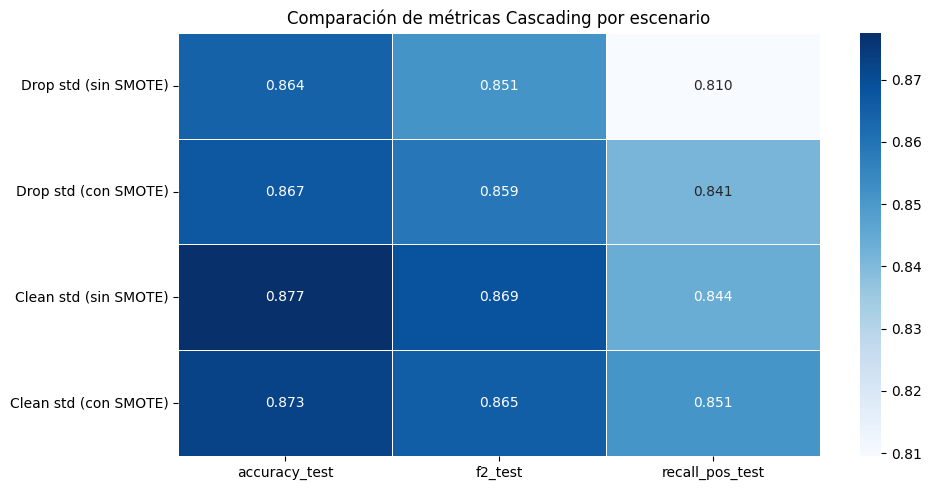

In [ ]:
plot_metrics_heatmap("Cascading", results_test_cascade)

Viendo la gráfica, podemos ver que la precisión ha sido muy similar para todos los escenarios, teniendo un valor de 86%-88%. Donde si vemos una mejora sustancial es en el recall al limpiar los datos o aplicar SMOTE, ya que pasamos de un valor de 81% si no aplicamos ninguna mejora, a 84%-85% aplicando al menos una de ellas. Como los resultados en precisión y recall han sido en general similares para todos los escenarios, los valores de f2 tampoco van a variar mucho. En este caso, tenemos un f2 de 85%-87%. Los resultados han sido buenos, cosa que tiene sentido teniendo en cuenta que nuestra segunda stage tiene como modelo XGBoost, que ya de por sí era uno de los mejores modelos para nuestro problema. Esto hace que este modelo también sea una opción a tener en cuenta como modelo final, pero creemos que merece más la pena aplicar directamente XGBoost, ya que utilizandolo individualmente puede generar resultados incluso mejores. Aún así, es interesante ver como este modelo puede generar resultados bastante buenos sin necesidad de preprocesar los datos.

##### **1.4.6.2 Matriz de confusión**


=== Matrices de Confusión (Cascading) ===


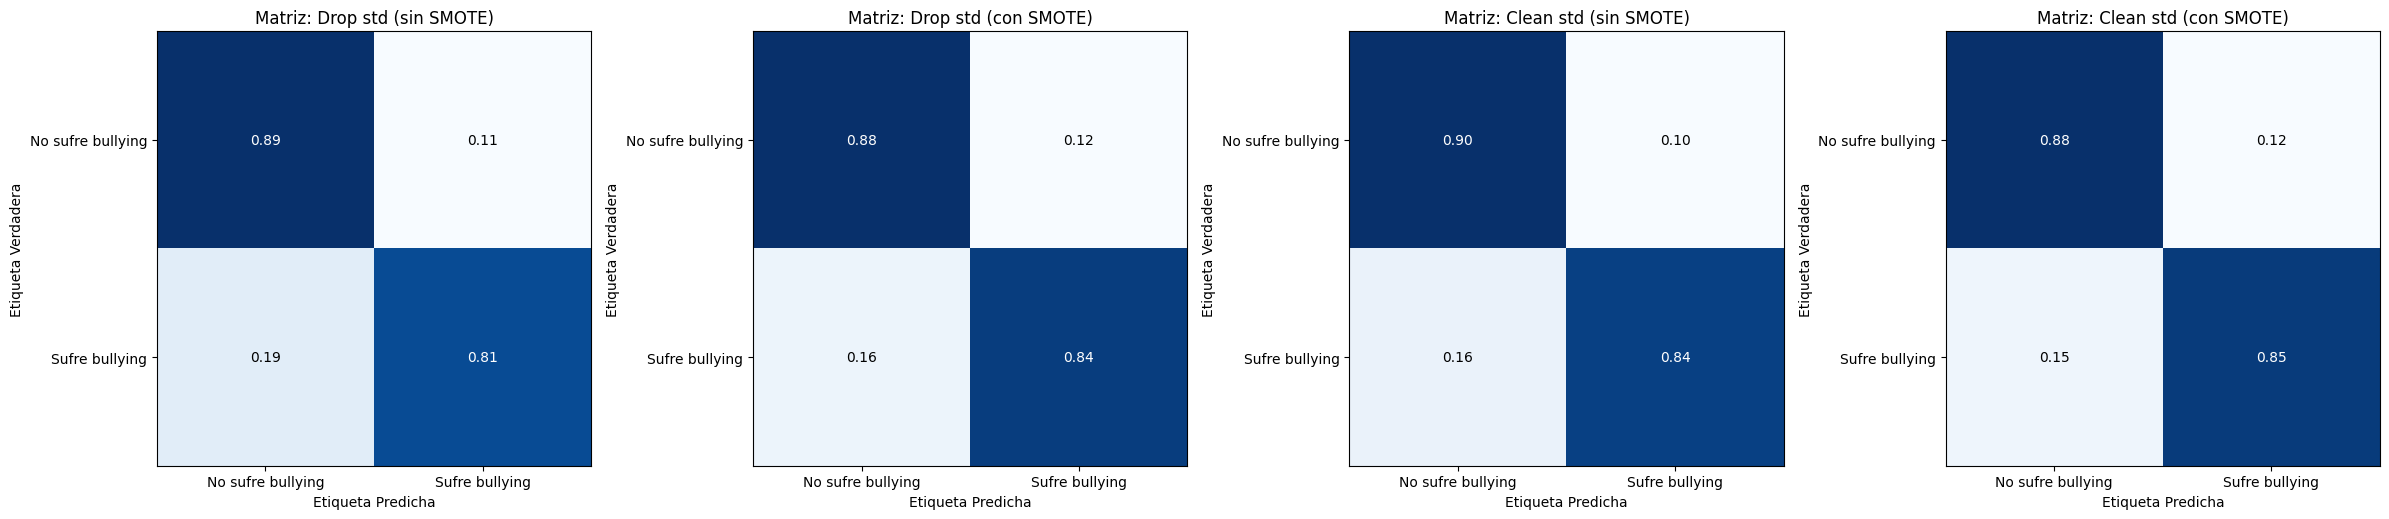

In [ ]:
plot_scenarios_confusion_matrix("Cascading", conf_matrices_cascade)

En las matrices de confusión, podemos ver que el modelo funciona bastante bien para detectar casos de no bullying, teniendo como valor una precisión de 88%-90%. Para los casos de bullying no funciona tan bien, pero aplicando preprocesamiento podemos pasar de un 81% a un 84%-85%. Son unos resultados buenos, pero como hemos dicho, utilizando XGBoost individualmente podemos llegar a obtener resultados mejores.

##### **1.4.6.3 Comprobación Overfitting**

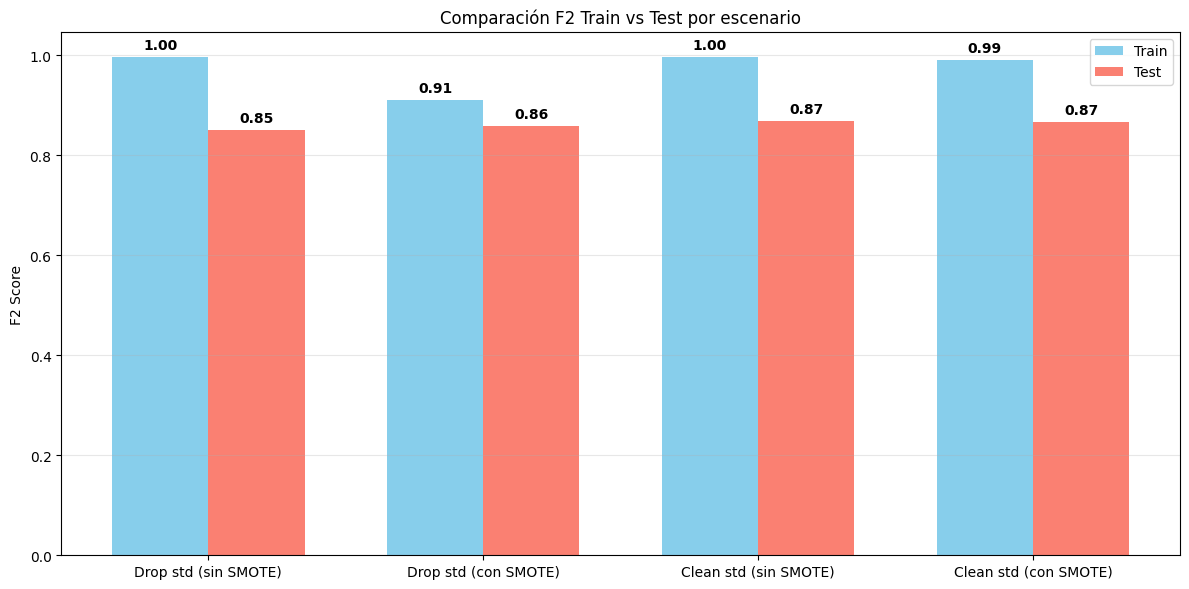

In [ ]:
# Mostramos el f2 obtenido en train y test
plot_train_test_bars(results_train_cascade, results_test_cascade)

En este gráfico podemos ver un 91%-100% de f2 score en training y un 85%-87% en test. El único caso en el que el overfitting no ha sido tan elevado ha sido en el dataset eliminando los valores nulos y aplicando SMOTE, en el que vemos un valor de 91% en training y un 86% en test, que sigue siendo una diferencia considerable. Para el resto de casos, vemos un diferencia de al menos un 12% entre train y test, que es un overfitting de nuevo bastante alto y que hace que los resultados generados por el modelo no sean fiables.

### **1.5 Comparación de modelos**

In [ ]:
def compare_all_models(results_svm, results_xgb, results_stacking,
                       results_rf, results_cascade):
    """
    Une los resultados de todos los modelos en un único DataFrame comparativo.
    Cada elemento de results_* debe ser una lista de diccionarios generados por
    extract_report_metrics().
    """

    # Añadimos columna 'model' a cada lista
    labeled_results = []

    for res in results_svm:
        labeled_results.append({**res, "model": "SVM"})
    for res in results_xgb:
        labeled_results.append({**res, "model": "XGBoost"})
    for res in results_stacking:
        labeled_results.append({**res, "model": "Stacking"})
    for res in results_rf:
        labeled_results.append({**res, "model": "RandomForest"})
    for res in results_cascade:
        labeled_results.append({**res, "model": "Cascading"})

    df = pd.DataFrame(labeled_results)

    # Orden de columnas útil
    cols = ["model", "scenario", "recall_pos_test", "f2_test", "accuracy_test", "best_params"]
    df = df[ [c for c in cols if c in df.columns] ]

    return df

In [ ]:
df_comparacion = compare_all_models(
    results_test_svm,
    results_test_xgb,
    results_test_stacking,
    results_test_rf,
    results_test_cascade
)

df_comparacion

,model,scenario,recall_pos_test,f2_test,accuracy_test,best_params
0,SVM,Drop std (sin SMOTE),0.587302,0.703312,0.736842,"{'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke..."
1,SVM,Drop std (con SMOTE),0.698413,0.730980,0.745152,"{'svm__C': 100, 'svm__gamma': 0.01, 'svm__kern..."
2,SVM,Clean std (sin SMOTE),0.609929,0.733613,0.767500,"{'svm__C': 100, 'svm__gamma': 0.01, 'svm__kern..."
3,SVM,Clean std (con SMOTE),0.702128,0.746761,0.762500,"{'svm__C': 1, 'svm__gamma': 'auto', 'svm__kern..."
4,XGBoost,Drop std (sin SMOTE),0.841270,0.858805,0.867036,"{'xgb__eta': 0.1, 'xgb__max_depth': 8, 'xgb__n..."
5,XGBoost,Drop std (con SMOTE),0.880952,0.869601,0.872576,"{'xgb__eta': 0.1, 'xgb__max_depth': 8, 'xgb__n..."
6,XGBoost,Clean std (sin SMOTE),0.829787,0.857708,0.867500,"{'xgb__eta': 0.1, 'xgb__max_depth': 5, 'xgb__n..."
7,XGBoost,Clean std (con SMOTE),0.879433,0.878323,0.882500,"{'xgb__eta': 0.3, 'xgb__max_depth': 8, 'xgb__n..."
8,Stacking,Drop std (sin SMOTE),0.698413,0.800793,0.828255,"{'stack__final_estimator__C': 0.1, 'stack__fin..."
9,Stacking,Drop std (con SMOTE),0.682540,0.779264,0.806094,"{'stack__final_estimator__C': 0.1, 'stack__fin..."


A lo largo del informe hemos decidido evaluar nuestros modelos utilizando tres métricas complementarias:

* F2-Score como métrica principal,
* Recall de la clase positiva como métrica crítica,
* Accuracy como medida global del rendimiento.

El F2-Score es adecuado en nuestro contexto porque da más peso al recall, lo que nos permite priorizar la detección de estudiantes que sí sufren bullying sin ignorar por completo la precisión. Esto evita caer en modelos que únicamente maximizan el recall generando demasiadas falsas alarmas.

El recall de la clase positiva sigue siendo esencial porque un falso negativo —un caso real de bullying que no se detecta— es el error más grave. Por ello lo utilizamos como métrica secundaria para asegurarnos de que ningún modelo con buen F2 esté sacrificando excesivamente esta sensibilidad.

Finalmente, incluimos el accuracy para obtener una visión global del desempeño del modelo en ambas clases, especialmente útil cuando comparamos modelos que ya tienen buen F2 y buen recall positivo.

##### **1.5.1 Análisis de resultados**

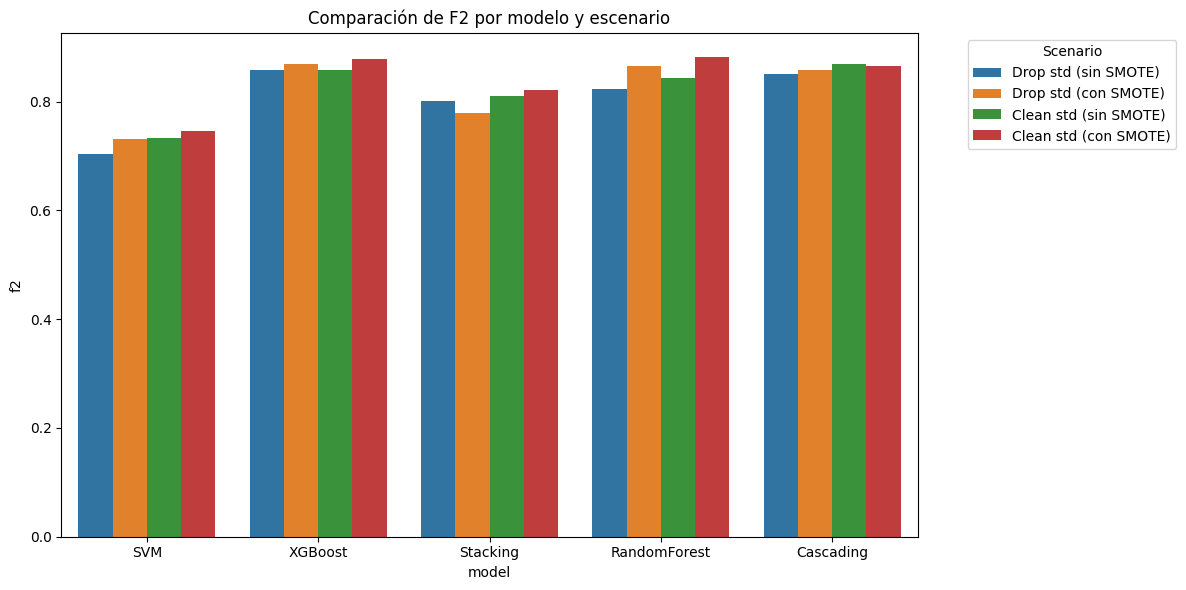

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(data=df_comparacion, x="model", y="f2_test", hue="scenario")

plt.title("Comparación de F2 por modelo y escenario")
plt.ylabel("f2")
plt.xticks(rotation=0)

plt.legend(title="Scenario", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Como podemos observar en la grafica anterior, el modelo que mejor desempeño general consigue para f2-score es XGBoost (87.8%), aunque RandomForest con los datos imputados, estandarizados y con balanceo consigue un f2 minimamente superior (88.3%)

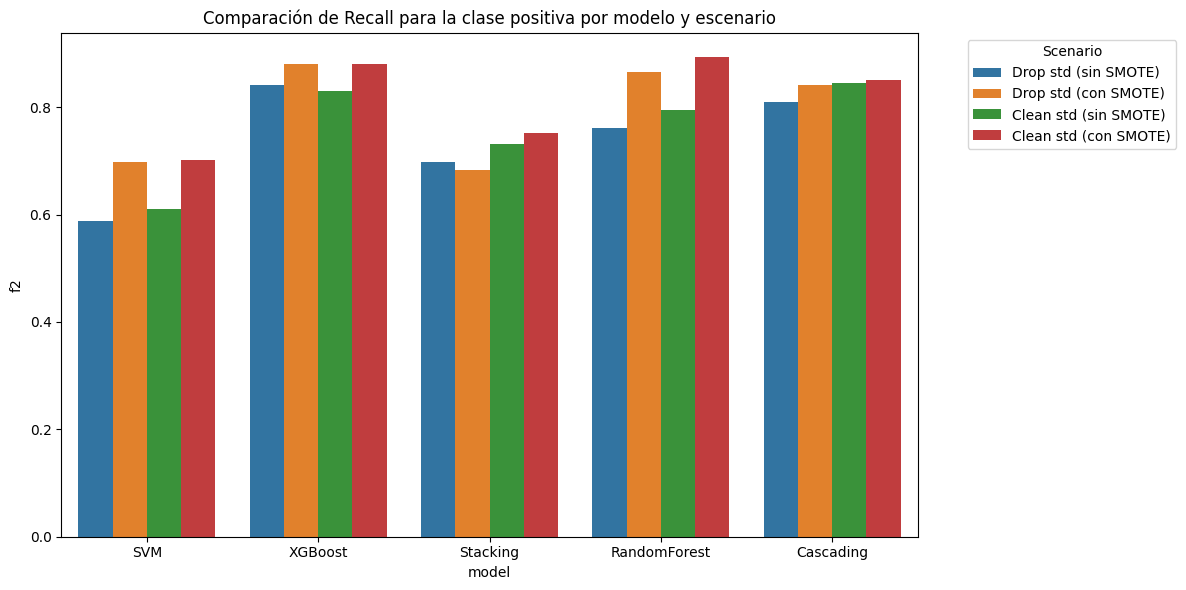

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(data=df_comparacion, x="model", y="recall_pos_test", hue="scenario")

plt.title("Comparación de Recall para la clase positiva por modelo y escenario")
plt.ylabel("f2")
plt.xticks(rotation=0)

plt.legend(title="Scenario", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Para la métrica del **recall para la clase positiva**, tanto XGBoost y Random forest siguen manteniendo el podio, al igual que con f2-score, XGBoost tiene en terminos generales mejor recall en todos los escenarios (en los mejores 88.1%), pero Random Forest con el escenario de datos imputados, estandarizados y con smote consigue un recall (89.4%) superior.

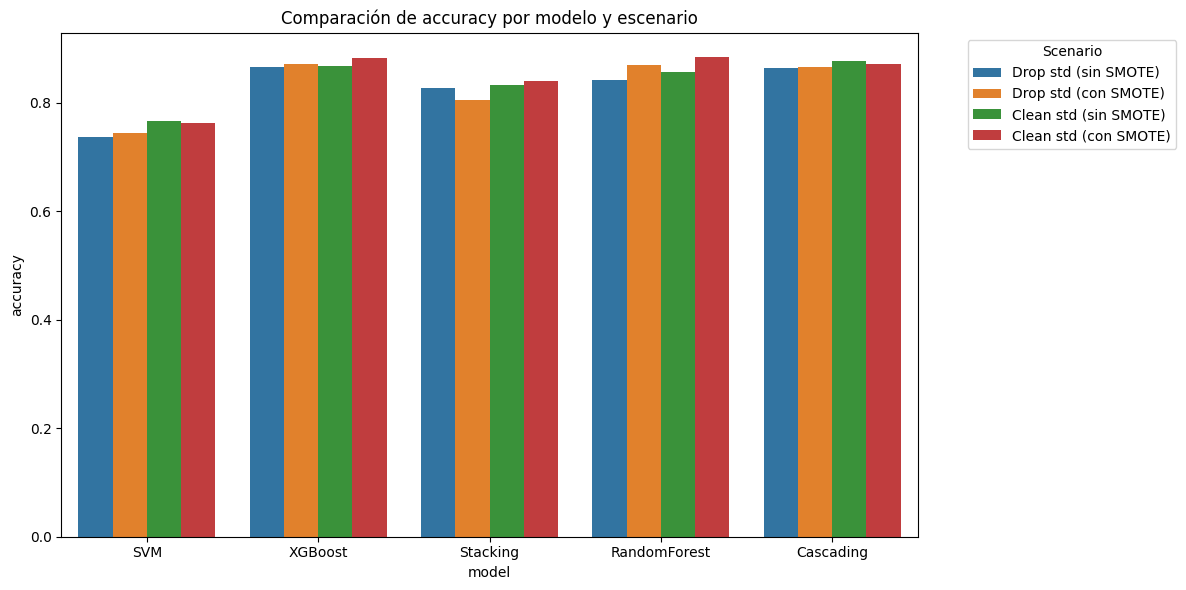

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(data=df_comparacion, x="model", y="accuracy_test", hue="scenario")

plt.title("Comparación de accuracy por modelo y escenario")
plt.ylabel("accuracy")
plt.xticks(rotation=0)

plt.legend(title="Scenario", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

En el caso de la métrica de accuracy, como métrica del desempeño global del modelo, se observa la misma proporción que en las métricas anteriores, un desempeño en todos los escenarios muy bueno en XGBoost pero Random forest ligeramente superior en un escenario concreto

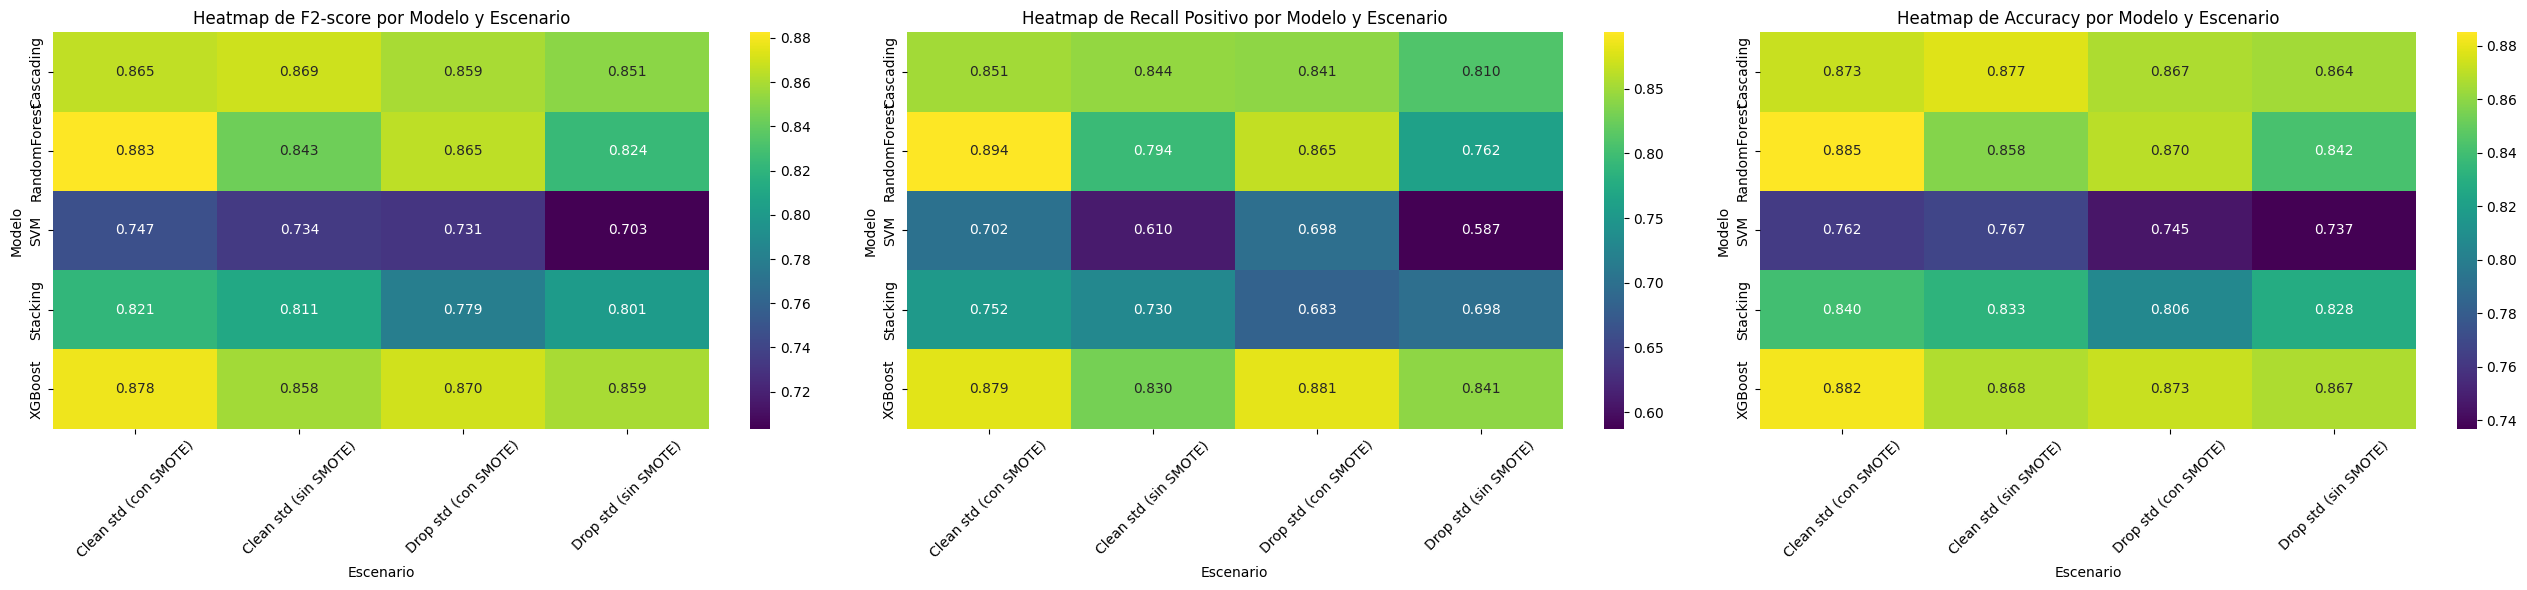

In [ ]:
"""df_heatmap = df_comparacion.pivot_table(
    index="model",
    columns="scenario",
    values="f2_test"
)

plt.figure(figsize=(10,6))
sns.heatmap(df_heatmap, annot=True, fmt=".3f", cmap="viridis")
plt.title("Heatmap de f2-score por Modelo y Escenario") #
plt.ylabel("Modelo")
plt.xlabel("Escenario")
plt.xticks(rotation=45, ha="center")
plt.show()

df_heatmap = df_comparacion.pivot_table(
    index="model",
    columns="scenario",
    values="recall_pos_test"
)

plt.figure(figsize=(10,6))
sns.heatmap(df_heatmap, annot=True, fmt=".3f", cmap="viridis")
plt.title("Heatmap de Recall para la clase positiva por Modelo y Escenario") #
plt.ylabel("Modelo")
plt.xlabel("Escenario")
plt.xticks(rotation=45, ha="center")
plt.show()
"""

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(26, 6))

# --- Heatmap F2 ---
df_heatmap_f2 = df_comparacion.pivot_table(
    index="model",
    columns="scenario",
    values="f2_test"
)

sns.heatmap(df_heatmap_f2, annot=True, fmt=".3f", cmap="viridis", ax=ax1)
ax1.set_title("Heatmap de F2-score por Modelo y Escenario")
ax1.set_xlabel("Escenario")
ax1.set_ylabel("Modelo")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="center")


# --- Heatmap Recall positivo ---
df_heatmap_recall = df_comparacion.pivot_table(
    index="model",
    columns="scenario",
    values="recall_pos_test"
)

sns.heatmap(df_heatmap_recall, annot=True, fmt=".3f", cmap="viridis", ax=ax2)
ax2.set_title("Heatmap de Recall Positivo por Modelo y Escenario")
ax2.set_xlabel("Escenario")
ax2.set_ylabel("Modelo")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="center")


# --- Heatmap Accuracy ---
df_heatmap_acc = df_comparacion.pivot_table(
    index="model",
    columns="scenario",
    values="accuracy_test"
)

sns.heatmap(df_heatmap_acc, annot=True, fmt=".3f", cmap="viridis", ax=ax3)
ax3.set_title("Heatmap de Accuracy por Modelo y Escenario")
ax3.set_xlabel("Escenario")
ax3.set_ylabel("Modelo")
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha="center")


plt.tight_layout()
plt.show()

Al analizar los resultados de los cinco modelos en los cuatro escenarios (reflejados en los heatmaps), observamos que el escenario “Clean std (con SMOTE)” es el que proporciona el mejor rendimiento general. En este caso, el modelo con las métricas más altas ha sido **Random Forest**, que consigue el mejor F2-Score, el mayor recall de la clase positiva y una accuracy ligeramente superior.

No obstante, XGBoost ha mostrado un rendimiento muy consistente en todos los escenarios y especialmente sólido en los relacionados con SMOTE, donde se mantiene prácticamente al nivel de Random Forest. Esta robustez nos indica que XGBoost no solo se adapta bien a los datos procesados, sino que además ofrece un comportamiento estable ante cambios de escenario y parametrización, lo que lo convierte en un candidato fiable para etapas posteriores del análisis.

Además, los heatmaps confirman que nuestras decisiones de preprocesamiento han sido adecuadas: los escenarios “con SMOTE” son los que mejores resultados proporcionan sistemáticamente en todos los modelos. Esto refuerza la idea de que, sin una técnica explícita para abordar el desbalanceo, los algoritmos tienden a ignorar la clase minoritaria, como muestran los rendimientos obtenidos *sin SMOTE*.

Cabe mencionar que la metodología de ajuste de parámetros se ha basado en *GridSearchCV* con 5 folds de validación cruzada. En todos los modelos excepto Random Forest hemos definido rejillas enfocadas en los hiperparámetros más influyentes. En el caso de Random Forest se empleó una rejilla más amplia, con 144 combinaciones (144 combinaciones × 5 folds × 4 escenarios = 2880 modelos entrenados).



#### **1.5.2 Analisis de Overfitting**

Durante las pruebas realizadas con los modelos, hemos mostrado gráficas comparativas sobre los resultados obtenidos en training y en test, para poder comparar y saber si nuestro modelo sufria de overfitting. La conclusión para prácticamente todos los casos fue que había un overfitting bastante elevado. Ahora, vamos a mostrar la comparación entre train y test para cada uno de los modelos para poder verlo mejor. En este caso, solo vamos a utilizar los resultados del último escenario (clean con SMOTE), ya que ha sido en general el que mejores resultados ha generado.

In [ ]:
def plot_all_models_overfitting(results_svm, results_xgb, results_stacking,
                       results_rf, results_cascade):
    """
    Función para mostrar los resultados de train y test para cada modelo y poder
    comprobar el overfitting.
    Cada elemento de results_* debe ser un diccionario que contenga los datos de
    train y test generados por extract_report_metrics().
    """
    # Diccionario general
    models = {
        "SVM": results_svm,
        "XGB": results_xgb,
        "Stacking": results_stacking,
        "Random Forest": results_rf,
        "Cascading": results_cascade
    }

    # Listas donde guardar los valores finales
    model_names = []
    train_values = []
    test_values = []

    # Extraemos el último escenario de cada modelo
    for name, data in models.items():
        df_train = pd.DataFrame(data["train"])
        df_test = pd.DataFrame(data["test"])

        # Última fila (último escenario)
        last_train = df_train.iloc[-1]["f2_train"]
        last_test = df_test.iloc[-1]["f2_test"]

        model_names.append(name)
        train_values.append(last_train)
        test_values.append(last_test)

    # Preparar posiciones
    x = np.arange(len(model_names))
    width = 0.35

    # Plot
    plt.figure(figsize=(10, 6))
    plt.bar(x - width/2, train_values, width, label="Train", color="skyblue")
    plt.bar(x + width/2, test_values, width, label="Test", color="salmon")

    # Etiquetas sobre las barras
    for i in range(len(model_names)):
        plt.text(x[i] - width/2, train_values[i] + 0.01,
                 f"{train_values[i]:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
        plt.text(x[i] + width/2, test_values[i] + 0.01,
                 f"{test_values[i]:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

    plt.xticks(x, model_names)
    plt.ylabel("F2 Score")
    plt.title("Comparación F2 Train vs Test (último escenario) por modelo")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

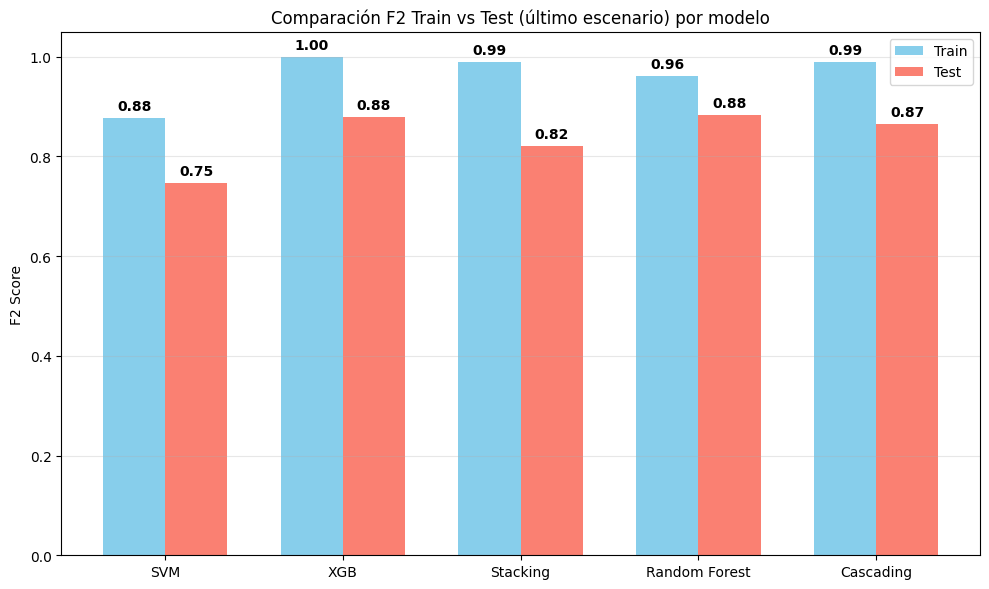

In [ ]:
# Preparamos los diccionarios con los resultados de cada modelo
results_svm = { "train": results_train_svm, "test": results_test_svm }
results_xgb = { "train": results_train_xgb, "test": results_test_xgb }
results_stacking = { "train": results_train_stacking, "test": results_test_stacking }
results_rf = { "train": results_train_rf, "test": results_test_rf }
results_cascade = { "train": results_train_cascade, "test": results_test_cascade }

# Mostramos los resultados para el último escenario de cada modelo
plot_all_models_overfitting(results_svm,
                            results_xgb,
                            results_stacking,
                            results_rf,
                            results_cascade)

Viendo esta gráfica, podemos ver que exceptuando el modelo SVM, todos han llegado a un f2 en training de 99-100%, mientras que en test se han quedado en 82%-88%. Igualmente, para el caso de SVM, vemos un training de 88% y un test de 75%, por lo que aún así podemos apreciar una diferencia sustancial. Aquí podemos ver claramente que todos los modelos han sufrido de un overfitting bastante alto. Esto nos hace pensar que el problema de overfitting no es tanto por culpa de los modelos, si no culpa de los datos en sí. Con este problema de overfitting, no podiamos confiar en los resultados generados por los modelos, por lo tanto lo siguiente que haremos será encargarnos de tratar este problema.

### **1.6 Reducción de Overfitting para XGBoost**

Como hemos comentado en el apartado de [Comparación de modelos](#1.5-comparación-de-modelos), el modelo que hemos considerado el mejor ha sido XGBoost. Por ello, nos centraremos en él para tratar el problema del overfitting. Además, utilizaremos el dataset preprocesado, ya que ha sido el que mejores resultados ha generado.

#### **1.6.1 Elección de las mejores caracteristicas para el modelo**

La selección de características es esencial para evitar el overfitting, ya que eliminar características irrelevantes puede reducir la complejidad del modelo y mejorar su generalización. Al principio del documento, viendo las variables correladas, decidimos que no había ninguna variable que se pudiera eliminar. Sin embargo, como XGBoost es un modelo basado en árboles, una vez entrenado podemos sacar qué variables han sido más decisivas a la hora de clasificar si un alumno sufre bullying o no.

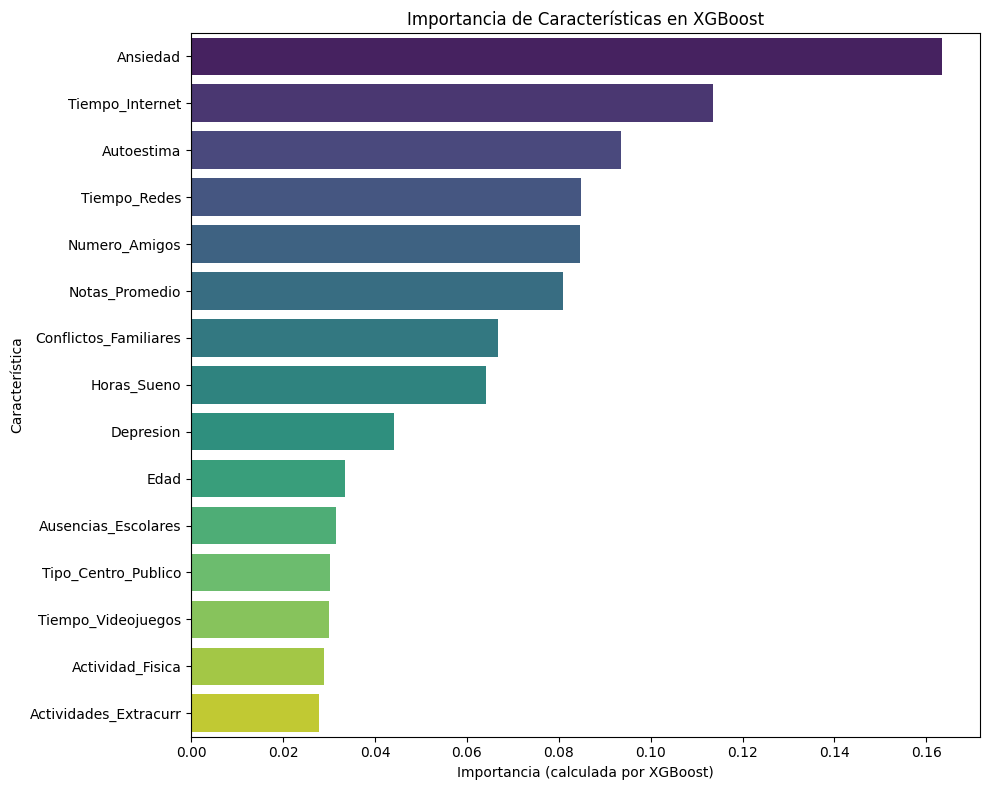

In [ ]:
# Extraemos el mejor modelo, que es un Pipeline
best_pipeline_xgb = grid_xgb.best_estimator_

# Extraemos el modelo XGBoost de dentro del Pipeline
final_xgb_model = best_pipeline_xgb.named_steps['xgb']

# Obtenemos las columnas del escenario "Clean", que es el que mejores resultados ha generado
feature_names = X_train_clean_estandarizados.columns

# Creamos el DataFrame de importancias
df_importances = pd.DataFrame({
    'feature': feature_names,
    'importance': final_xgb_model.feature_importances_
}).sort_values(by='importance', ascending=False)

# Graficar todas las importancias
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', hue='feature', data=df_importances.head(15), palette='viridis')
plt.title('Importancia de Características en XGBoost')
plt.xlabel('Importancia (calculada por XGBoost)')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

En el gráfico mostrado, podemos ver en orden descendente la importancia de cada una de las características a la hora de clasificar si un alumno tiene bullying o no. En concreto, las características más destacables son "*Ansiedad*", "*Tiempo_internet*", "*Autoestima*", "*Tiempo_Redes*", "*Numero_Amigos*" y "Notas_Promedio".

Ahora que tenemos la lista de características y su importancia en la clasificación, podemos descartar las variables que sean menos relevantes. Para ello, vamos a definir un limite de 9 variables, ya que a partir de la décima las variables tienen una importancia muy baja, y vamos a probar varias combinaciones para decidir cual es el número de variables óptimo. Para estas pruebas utilizaremos el dataset "Clean" aplicando SMOTE, ya que ha sido el que mejores resultados ha dado.

In [ ]:
def test_importance_variables(num_variables, df_importances, scenario, title, model_name, model, param_grid):
    """
    Función para hacer train y test de un modelo probando diferentes combinaciones de características
    - num_variables: Número máximo de variables a probar
    - df_importances: DataFrame con las características y su importancia
    - scenario: Escenario a probar
    - title: Título para mostrar en los escenarios
    - model_name: Nombre del modelo
    - model: Modelo a probar
    - param_grid: Grid de parámetros del modelo
    """
    # Listas para guardar los resultados
    results_train = []
    results_test = []

    # Bucle para las combinaciones de características
    for i in range(2, num_variables+1):
        # Obtenemos la lista de columnas que queremos mantener en el dataset
        importances_index = df_importances.head(i).index.tolist()

        # Número de columnas actuales en el dataset
        num_columnas = scenario["Xtr"].shape[1]

        # Obtenemos los índices de las columnas que queremos eliminar y existen en el dataset
        delete_index = list(set(range(num_columnas)) - set(importances_index))

        # Obtenemos los datasets filtrado
        Xtr_filtered = np.delete(scenario["Xtr"], delete_index, axis=1)
        Xte_filtered = np.delete(scenario["Xte"], delete_index, axis=1)

        # Creamos el nuevo escenario
        scenarios = [
            (scenario["name"], Xtr_filtered, scenario["ytr"], Xte_filtered, scenario["yte"], scenario["usar_smote"])
        ]

        # Probamos el modelo con el escenario con los datasets filtrados
        result_train, result_test, conf_matrices_xgb_of, _ = train_and_test_model(title, model_name, model, param_grid, scenarios)

        # Guardamos los resultados
        results_train.append((f"{i} variables", result_train[0]))
        results_test.append((f"{i} variables", result_test[0]))

    return results_train, results_test

In [ ]:
# Obtenemos el escenario
scenario = {
    "name": scenarios_xgb[3][0],
    "Xtr": scenarios_xgb[3][1],
    "ytr": scenarios_xgb[3][2],
    "Xte": scenarios_xgb[3][3],
    "yte": scenarios_xgb[3][4],
    "usar_smote": scenarios_xgb[3][5]
}

# Probamos el modelo para el escenario con hasta 9 variables
results_importance_train, results_importance_test = test_importance_variables(num_variables=9,
                                                                              df_importances=df_importances,
                                                                              scenario=scenario,
                                                                              title="XGBoost",
                                                                              model_name="xgb",
                                                                              model=base_model_xgb,
                                                                              param_grid=param_grid_xgb
                                                                            )


=== Escenario XGBoost: Clean std (con SMOTE) ===
Configurando Pipeline con SMOTE...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores parámetros encontrados: {'xgb__eta': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 100}
Mejor score CV (F2): 0.7018

=== Escenario XGBoost: Clean std (con SMOTE) ===
Configurando Pipeline con SMOTE...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores parámetros encontrados: {'xgb__eta': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 100}
Mejor score CV (F2): 0.7523

=== Escenario XGBoost: Clean std (con SMOTE) ===
Configurando Pipeline con SMOTE...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores parámetros encontrados: {'xgb__eta': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 100}
Mejor score CV (F2): 0.7530

=== Escenario XGBoost: Clean std (con SMOTE) ===
Configurando Pipeline con SMOTE...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores parámetros encontrados: {'xgb__et

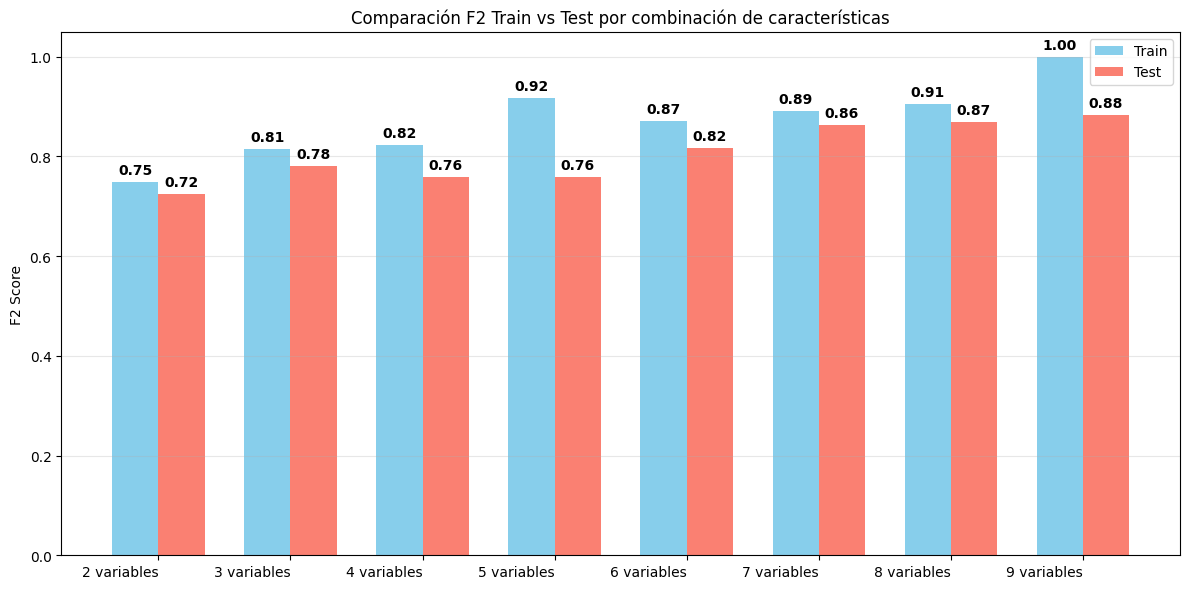

In [ ]:
# CÓDIGO HECHO CON IA
def plot_importance_variables_bars(results_train, results_test):
    """
    Función para mostrar un gráfico de barras comparando diferentes combinaciones de características
    - results_train: Lista de diccionarios con resultados de train
    - results_test: Lista de diccionarios con resultados de test
    """
    # Extraemos nombres de escenarios y valores de F2
    scenario_names = [t[0] for t in results_train]
    f2_train = [t[1].get('f2_train', t[1].get('f2_test')) for t in results_train]  # si solo hay f2_test
    f2_test = [t[1].get('f2_test') for t in results_test]

    n = len(scenario_names)
    x = np.arange(n)
    width = 0.35

    plt.figure(figsize=(12, 6))

    # Barras
    plt.bar(x - width/2, f2_train, width, label="Train", color="skyblue")
    plt.bar(x + width/2, f2_test, width, label="Test", color="salmon")

    # Añadir valores encima de las barras
    for i in range(n):
        plt.text(x[i] - width/2, f2_train[i] + 0.01, f"{f2_train[i]:.2f}",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
        plt.text(x[i] + width/2, f2_test[i] + 0.01, f"{f2_test[i]:.2f}",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Configuración
    plt.xticks(x, scenario_names, ha='right')
    plt.ylabel("F2 Score")
    plt.title("Comparación F2 Train vs Test por combinación de características")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

# Mostramos los gráficos de barras con los resultados para cada número de variables
plot_importance_variables_bars(results_importance_train, results_importance_test)

Si analizamos los resultados obtenidos, podemos ver que la mejor elección sería quedarnos con las 7 u 8 primeras variables, ya que son con estas variables con las que estamos consiguiendo los mejores resultados sin sufrir de overfitting. Si comparamos utilizando la metrica del f2, estamos consiguiendo un 86-87% con respecto al 88% que estabamos consiguiendo al utilizar a partir de 9 variables. Podemos ver que la mejora es practicamente inexistente y encima sufrimos del problema de overfitting, por lo que estos resultados no son fiables, y el modelo podría funcionar incluso peor para otros tipos de datos nuevos.

---
### **1.7. Conclusión**


Vamos a obtener las métricas completas del modelo utilizando las 8 variables escogidas en el punto anterior y valorar los resultados obtenidos

In [ ]:
# Para obtener la matriz de confusión correspondiente, volvemos a ejecutar el escenario filtrado
# Obtenemos las columnas seleccionadas
importances_index = df_importances.head(8).index.tolist()
num_columnas = scenario["Xtr"].shape[1]
delete_index = list(set(range(num_columnas)) - set(importances_index))
Xtr_filtered = np.delete(scenario["Xtr"], delete_index, axis=1)
Xte_filtered = np.delete(scenario["Xte"], delete_index, axis=1)

# Creamos el escenario filtrado
scenario_filtered = [
    (scenario["name"], Xtr_filtered, scenario["ytr"], Xte_filtered, scenario["yte"], scenario["usar_smote"])
]

# Entrenamos nuevamente para obtener la matriz de confusión
results_train_xgb_of, results_test_xgb_of, conf_matrices_xgb_of, _ = train_and_test_model(
    title="XGBoost",
    model_name="xgb",
    model=base_model_xgb,
    param_grid=param_grid_xgb,
    scenarios=scenario_filtered
)




=== Escenario XGBoost: Clean std (con SMOTE) ===
Configurando Pipeline con SMOTE...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores parámetros encontrados: {'xgb__eta': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 100}
Mejor score CV (F2): 0.8563



Métricas comparativas (XGBoost)


,scenario,accuracy_test,f2_test,recall_pos_test,best_params
0,Clean std (con SMOTE),0.875,0.868602,0.858156,"{'xgb__eta': 0.1, 'xgb__max_depth': 3, 'xgb__n..."


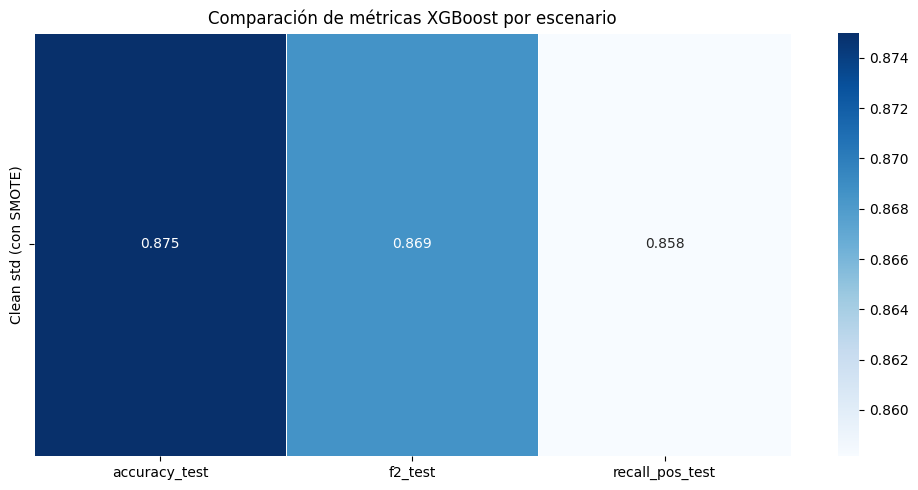

In [ ]:
plot_metrics_heatmap("XGBoost", results_test_xgb_of)

Los resultados obtenidos en F2 son levemente inferiores a los obtenidos anteriormente, pero ya no padecemos de overfitting, por lo que el modelo será mejor prediciendo datos nuevos que no estén relacionados con aquellos con los que se le ha entrenado, ya que ha "memorizado" menos y "comprendido" más.


=== Matrices de Confusión (XGBoost) ===


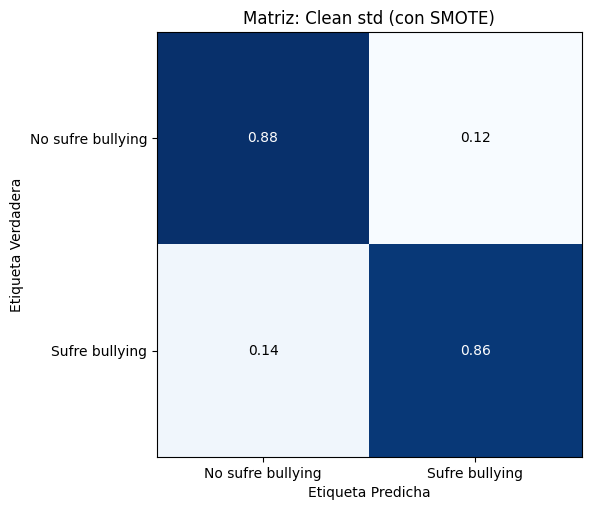

In [ ]:

# Mostramos la matriz de confusión
plot_scenarios_confusion_matrix("XGBoost", conf_matrices_xgb_of)

La matriz de confusion muestra un ligero aumento en los valores de FalsosNegativos y un peor resultado para predecir la clase objetivo, que se situa en 86% que antes de trabajar el overfitting, donde se situaba en 88%

### **1.8 Recomendación final para la Consejería**

Por todo lo explicado anteriormente, el modelo XGBoost entrenado con el conjunto de datos "Clean estandarizado" y balanceado con "SMOTE", y considerando las 8 variables de mayor importancia para XGBoost a la hora de clasificar:

1. "Ansiedad"  
2. "Tiempo_internet"
3. "Autoestima"
4. "Tiempo_Redes"
5. "Numero_Amigos"
6. "Notas_Promedio"
7. "Conflictos_familiares"
8. "Horas_sueno"


Creemos que es la solución óptima para la Consejería de Educación, por su fiabilidad y eficiencia (permite obtener resultados de forma muy rápida). Lo consideramos fiable para encontrar casos de Bullying porque con un Recall del 86%, el modelo encuentra prácticamente a 9 de cada 10 personas que sufren Bullying de forma satisfactoria y no tenemos demasiado sobreajuste. También creemos que seguramente implementando un Cascading con un mejor filtro en la 1ª etapa se podría encontrar un modelo algo más fiable, pero por falta de tiempo y financiación no nos dará tiempo a comprobarlo.

Como recordatorio final a la Consejeria queremos recordar que a la hora de utilizar el modelo, la parte que requiere más tiempo es el entrenamiento y la validación, sobre todo si se usan técnicas como cross-validation. Una vez que el modelo ha sido entrenado, obtener predicciciones de datos nuevos es algo muy rápido.

# **Uso de IA GENERATIVA en el trabajo**

Hay que poner el prompt y todos los trozos de código que nos ha sacado ChatGPT o Gemini. Y si usamos Copilot lo ponemos como comentario genérico.

## Elección de modelo para clasificación

### **Propmt 1**

Estoy haciendo un trabajo de machine learning de clasificación binaria. Sin importar la implementación concreta, dime cuales son los modelos que pueden funcionar mejor en un problema de este estilo, priorizando que el modelo pueda ser lo más preciso posible. Para ponerte en contexto, tenemos un dataset de 2000 filas con 16 variables cada una, más una extra que es la variable a predecir. En este caso, no quiero ningún modelo de ensamble.

### **Respuesta Prompt 1**

Para un problema de clasificación binaria, con un dataset de ~2000 observaciones y 16 variables, y sin usar modelos de ensamble, las mejores opciones suelen ser modelos capaces de capturar relaciones no lineales y que puedan ajustarse bien sin requerir una enorme cantidad de datos.

A continuación te presento modelos adecuados y consideraciones para elegirlos, priorizando la precisión (accuracy o métricas similares como F1, AUC).

✅ Modelos recomendados (no ensamblados)
1. Red neuronal multicapa (MLP)

Muy flexible en capturar patrones complejos.

Funciona bien incluso con pocos datos si se regula adecuadamente (dropout, early stopping, regularización L2).

Puedes ajustar su capacidad según necesidad (capas ocultas, neuronas).

Pros: alta capacidad predictiva.
Contras: requiere tuning cuidadoso; riesgo de overfitting con dataset pequeño.

2. SVM con kernel (preferiblemente RBF o polynomial)

Excelente en problemas de dimensionalidad moderada (como el tuyo).

Maneja muy bien separaciones no lineales.

Suele ser extremadamente competitivo en clasificación binaria.

Pros: muy buen rendimiento con datasets medianos.
Contras: tuning de C y gamma puede ser costoso.

3. Regresión logística regularizada

A pesar de ser lineal, con regularización (L1/L2) puede ser muy competitiva.

Ideal si las relaciones no son demasiado complejas.

Pros: interpretable, ligera, robusta.
Contras: puede quedarse corta si la relación entre variables es no lineal.

4. k-NN (vecinos más cercanos)

Simple y efectivo.

Funciona bien si las variables están bien escaladas y si no hay mucho ruido.

Pros: no requiere entrenamiento; buen rendimiento con tuning de k.
Contras: sensible al ruido y a variables irrelevantes.

5. Árbol de decisión individual

Aunque no es ensamble, puede capturar no linealidades y reglas complejas.

Con buen poda (max_depth, min_samples_leaf) puede generalizar aceptablemente.

Pros: interpretabilidad, flexibilidad.
Contras: su precisión puede ser inferior a ensambles o a SVM/NN.

✅ ¿Qué modelo tiende a ser más preciso?

Si tu objetivo es maximizar precisión, descartando ensambles, el orden sugerido sería:

SVM con kernel RBF → suele ser el mejor en datasets compactos.

Red neuronal MLP pequeña → buena capacidad, ajustable, pero requiere tuning.

Logística regularizada → baseline sólido y difícil de superar en exceso de ruido.

k-NN → competitivo si las variables están bien normalizadas.

Árbol de decisión → útil, pero menor rendimiento promedio.

✅ Recomendaciones prácticas según tu dataset

2000 filas: modelo de complejidad moderada.

16 variables: suficiente para capturar patrones sin “mal de la dimensionalidad”.

Binario: SVM y MLP funcionan muy bien aquí.

Si buscas máxima precisión (no interpretabilidad)

➡️ SVM con kernel RBF o una MLP bien ajustada.

Si buscas precisión + robustez + simplicidad

➡️ Regresión logística regularizada.

✅ Consejos adicionales

Escala los datos (StandardScaler) para SVM, MLP y k-NN.

Usa validación cruzada (k-fold) para elegir hiperparámetros.

Evalúa métricas más allá del accuracy (AUC, F1), sobre todo si hay desbalance.

Si quieres, puedo ayudarte a:
✅ diseñar un pipeline de evaluación
✅ proponer hiperparámetros iniciales
✅ sugerir una arquitectura inicial de red neuronal

¿Quieres que trabajemos en eso?

## Elección de Ensamble

### **Propmt 2**

Estoy haciendo un trabajo de machine learning. La tarea es predecir, a partir de un dataset que contiene 16 características, si un alumno sufre bullying o no. Para ello, queremos usar un ensamble para obtener la clasificación más precisa posible. Dime, entre la lista de tipos de ensamble que te voy a dar, cuales son los que podrían generar predicciones más precisas, o que criterio me puede ayudar a saber cual podría conseguirlo. La lista de tipo de ensambles es la siguiente: bagging, boosting, stacking y cascading.

### **Respuesta Prompt 2**

Excelente — estás abordando un problema clásico de clasificación binaria con un enfoque muy acertado: usar un ensamble para mejorar la precisión predictiva.
Vamos por partes 👇

🔍 1. Los tipos de ensambles y su comportamiento
| Tipo de ensamble | Descripción |
|------------------|-------------|
| **Bagging** (Bootstrap Aggregating) | Entrena varios modelos base (por ejemplo, árboles) sobre subconjuntos aleatorios de los datos y promedia (o vota) las predicciones. Ejemplo: *Random Forest*. |
| **Boosting** | Los modelos se entrenan secuencialmente, corrigiendo los errores de los anteriores. Ejemplo: *XGBoost, LightGBM, AdaBoost, CatBoost*. |
| **Stacking** | Combina distintos modelos (por ejemplo, árboles, redes, regresiones, SVM) y usa un meta-modelo para aprender a combinar sus salidas. |
| **Cascading** | Similar al stacking, pero los modelos se entrenan en secuencia y sus predicciones (o probabilidades) se usan como *features* para el siguiente. |

---

| Tipo de ensamble | Ventajas principales | Riesgos o desventajas | Precisión esperada (en general) |
|------------------|----------------------|-----------------------|--------------------------------|
| **Bagging** | Reduce la varianza, evita sobreajuste, fácil de paralelizar. | No mejora mucho si el modelo base ya es muy estable. | **Alta**, pero menor que boosting o stacking en datasets complejos. |
| **Boosting** | Reduce bias y varianza, aprende patrones complejos. | Puede sobreajustar si no se regula bien (learning rate, profundidad). | **Muy alta**, típicamente mejor que bagging. |
| **Stacking** | Puede capturar la fortaleza de distintos modelos, gran flexibilidad. | Más costoso computacionalmente, riesgo de sobreajuste si no se hace buena validación. | **Muy alta**, especialmente con buena diversidad de modelos. |
| **Cascading** | Puede aprender relaciones jerárquicas entre predictores. | Más complejo, difícil de optimizar. | **Variable**, puede superar stacking en algunos casos pero requiere ajuste fino. |

🎯 2. Criterio para elegir el ensamble más preciso

El criterio principal es la complejidad del problema y el tamaño del dataset:
| Criterio                                                                        | Mejor opción                                                                                              |
| ------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------- |
| Dataset pequeño/mediano (pocas observaciones, pero buena calidad de features)   | **Boosting (XGBoost, LightGBM, CatBoost)** → por su capacidad de manejar bias sin sobreajustar demasiado. |
| Dataset grande y con ruido                                                      | **Bagging (Random Forest)** → robusto y estable.                                                          |
| Dataset heterogéneo (variables numéricas, categóricas, correlaciones complejas) | **Stacking** → combina distintos algoritmos (árboles, regresión, SVM, etc.).                              |
| Si buscas exprimir la máxima precisión posible y tienes capacidad de cómputo    | **Stacking o Cascading** → pueden superar a boosting, pero requieren tuning y validación cruzada sólida.  |

💡 3. En tu caso (predicción de bullying)

Es un problema de clasificación supervisada binaria con 16 variables.

Probablemente no tienes millones de muestras (dataset educativo → tamaño mediano).

Posible desbalance de clases (menos casos positivos de bullying).

👉 En este contexto:

Empieza con Boosting (por ejemplo, XGBoost o CatBoost):

Maneja bien features heterogéneas y desbalance.

Suele alcanzar la mejor precisión y recall de manera consistente.

Luego, si quieres mejorar aún más la precisión, puedes aplicar un Stacking que combine:

Un modelo de boosting (XGBoost),

Un Random Forest,

Y quizás una regresión logística o red neuronal como meta-modelo.

Esto suele dar el mejor rendimiento global.

🧭 4. En resumen

| Opción    | Precisión esperada           | Recomendado para tu caso    |
| --------- | ---------------------------- | --------------------------- |
| Bagging   | Buena                        | ✓ como baseline             |
| Boosting  | Muy alta                     | ✅ primera opción            |
| Stacking  | Muy alta (si bien calibrado) | ✅ para mejora final         |
| Cascading | Incierta / experimental      | ⚠️ solo si quieres explorar |

¿Quieres que te ayude a diseñar un pipeline concreto en scikit-learn o en Python para comparar bagging, boosting y stacking en tu dataset (por ejemplo, con validación cruzada y métricas de precisión, recall y F1)?
Así podrías ver cuál ensamble da la mejor predicción real.

## Elección de modelos para ensamble Stacking

### **Propmt 3**

Estoy haciendo un trabajo de machine learning de clasificación binaria, en el cual quiero utilizar la técnica de ensamble stacking, suponiendo que en la primera capa tendremos X número de clasificadores y en la segunda capa un clasificador final. Sin importar la implementación concreta, quiero una explicación de cuantos clasificadores sería recomendable escoger para la primera capa, y que modelos son recomendables usar para cada una de las capas.

### **Respuesta Prompt 3**

En un esquema de stacking clásico (dos capas), la capa base genera predicciones que sirven como características para la capa meta (meta-learner). Aunque no existe una regla universal, sí hay buenas prácticas basadas en experiencia y teoría de modelos en conjunto.

✅ ¿Cuántos clasificadores usar en la primera capa?

Recomendación general: entre 3 y 5 modelos, idealmente heterogéneos.

Por qué no usar demasiados:

Más modelos → mayor complejidad y tiempo de entrenamiento.

Existe riesgo de sobreajuste si los modelos de primera capa son muy similares o altamente correlacionados.

Muchos clasificadores no añaden demasiada información extra; la mejora marginal decrece.

Por qué no usar muy pocos:

Usar solo 1 o 2 modelos reduce el beneficio del stacking (diversidad insuficiente).

Con poca variedad, la capa meta no mejora significativamente.

Por eso, 3–5 es un número razonable: suficiente diversidad sin generar ruido innecesario.

✅ ¿Qué modelos usar en la primera capa (base learners)?

Recomendación clave: diversidad. Evita modelos que cometan los mismos errores.

Un set típico y eficaz podría incluir:

1. Árboles de decisión/boosting

Random Forest

Gradient Boosting (XGBoost, LightGBM o CatBoost)

Ventajas:

Capturan interacciones no lineales.

Funcionan bien con variables mixtas.

Son robustos y muy eficientes.

2. Modelos lineales

Regresión logística

SVM lineal

Ventajas:

Rápidos

Generalización fuerte

Capturan relaciones lineales complementarias a los árboles

3. Modelos más complejos o kernelizados

SVM con kernel no lineal

Redes neuronales pequeñas

Ventajas:

Capturan patrones complejos

Añaden diversidad estructural

4. Modelos probabilísticos

Naive Bayes

Ventaja:

Muy diferente a los anteriores, útil para datos con estructura particular

Ejemplo de primera capa equilibrada (3–5 modelos)

Regresión logística

Random Forest

Gradient Boosting (XGBoost/LightGBM)

SVM RBF

MLP simple (red neuronal de una o dos capas)

Esto garantiza diversidad en supuestos, bias-variance, y arquitectura.

✅ ¿Qué modelo usar en la segunda capa (meta-learner)?

La capa final debe ser:

✅ simple
✅ estable
✅ difícil de sobreajustar
✅ capaz de manejar correlaciones entre las predicciones base

El más utilizado y recomendado es:

1. Regresión logística

Robusta

Interpretable

Generaliza bien

Convierte las salidas de los modelos base en probabilidad final

Otros buenos candidatos:

2. Modelo lineal regularizado

Ridge

Lasso

ElasticNet

Por qué:

Evitan sobreajuste

Controlan pesos de modelos muy correlacionados

3. Modelos más avanzados (con cuidado)

XGBoost/LightGBM como meta-learner

Funciona bien pero puede sobreajustar

SVM

Menos interpretables y más exigentes

Generalmente, un meta-learner simple supera o iguala a modelos complejos en esta fase.

✅ Regla práctica

Capa 1: modelos variados
Capa 2: modelo sencillo y regularizado

Esto minimiza el riesgo de sobreajuste y aprovecha la diversidad del ensamble.

✅ Consejos adicionales
1. Cross-validation obligatorio

El stacking debe usar “out-of-fold predictions” para evitar fugas de información (data leakage).

2. Normaliza/estandariza si mezclas modelos

Especialmente importante si incluyes:

SVM

Regresión logística

Redes neuronales

3. Revisa correlación entre predicciones

Si dos modelos predicen casi lo mismo, elimina uno.

4. Evita modelos idénticos con hiperparámetros similares

A menos que estés haciendo blending de variaciones del mismo tipo de modelo (menos recomendado).

✅ Conclusión final

3–5 clasificadores en la primera capa es ideal.

Usa modelos variados: árboles, lineales, kernelizados, redes.

En la segunda capa, prefiere regresión logística o un modelo lineal regularizado.

## Pipeline para imputar nulos y outliers

### **Propmt 4**

Necesito un pipeline de preprocesamiento avanzado en Python para mi notebook de machine learning. Ya tengo mis datos divididos en X_train, X_test, y_train, y_test.

Quiero solucionar dos problemas:

Outliers: Tengo outliers en las columnas ['Autoestima', 'Ansiedad'].

NaNs: Tengo valores nulos (NaN) en las columnas ['Edad', 'Numero_Amigos'].

Mi objetivo es reemplazar ambos (outliers y NaNs) usando la mediana, pero quiero hacerlo de una forma muy específica para evitar la fuga de datos (data leakage) y ser lo más preciso posible.

Quiero imputar los valores faltantes usando la mediana de la clase (mi variable objetivo y se llama Sufre_Bullying).

### **Respuesta Prompt 4**



In [ ]:
'''
# ============================================
# CONFIGURACIÓN
# ============================================
cols_outliers = ['Autoestima', 'Ansiedad']
cols_nulls = ['Edad', 'Numero_Amigos']
cols_a_imputar = list(set(cols_outliers + cols_nulls))
target = "Sufre_Bullying"


# ============================================
# DETECCIÓN DE OUTLIERS POR IQR (train)
# ============================================
def obtener_limites_outliers(df, cols):
    """
    Calcula los límites inferior y superior de outliers para cada columna usando el método IQR.

    Este método se basa en:
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

    Args:
        df (pd.DataFrame):
            DataFrame de entrada (generalmente X_train) con valores numéricos.
        cols (list[str]):
            Lista de columnas numéricas sobre las que se calcularán los límites de outliers.

    Returns:
        dict:
            Diccionario con la forma:
            {
                "columna": {
                    "lower": valor_limite_inferior,
                    "upper": valor_limite_superior
                },
                ...
            }
    """
    limites = {}

    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        limites[col] = {"lower": lower, "upper": upper}

    return limites

# ============================================
# MARCAR OUTLIERS COMO NAN
# ============================================
def convertir_outliers_a_nan(df, limites):
    """
    Reemplaza los valores considerados outliers por NaN,
    utilizando los límites previamente calculados con obtener_limites_outliers().

    Args:
        df (pd.DataFrame):
            DataFrame de entrada cuyos outliers serán reemplazados por NaN.
        limites (dict):
            Diccionario con límites de outliers por columna
            generado por obtener_limites_outliers().

    Returns:
        pd.DataFrame:
            Copia del DataFrame original, con los outliers reemplazados por NaN.
    """
    df_copy = df.copy()

    for col, bounds in limites.items():
        lower = bounds["lower"]
        upper = bounds["upper"]

        mask_out = (df_copy[col] < lower) | (df_copy[col] > upper)
        df_copy.loc[mask_out, col] = np.nan

    return df_copy

# ============================================
# CALCULAR MEDIANAS POR CLASE
# ============================================
def calcular_medianas_por_clase(df, y, columnas):
    """
    Calcula la mediana por clase (target) para las columnas especificadas.
    Los valores NaN se ignoran automáticamente.

    Args:
        df (pd.DataFrame):
            DataFrame con las variables predictoras.
        y (pd.Series o np.array):
            Vector objetivo correspondiente a df.
        columnas (list[str]):
            Lista de columnas numéricas para las cuales se calcularán medianas por clase.

    Returns:
        dict:
            Diccionario de medianas con estructura:
            {
               "columna": {
                   clase_0: mediana_0,
                   clase_1: mediana_1
               },
               ...
            }
    """
    df_temp = df.copy()
    df_temp[target] = y

    medianas = {}

    for col in columnas:
        medianas[col] = {}
        for clase in df_temp[target].unique():
            mediana = df_temp.loc[df_temp[target] == clase, col].median()

            # fallback: si una clase no tiene valores válidos
            if pd.isna(mediana):
                mediana = df_temp[col].median()

            medianas[col][clase] = mediana

    return medianas

# ============================================
# IMPUTAR NULOS POR CLASE
# ============================================
def imputar_nulos_por_clase(df, y, medianas):
  """
  Imputa valores NaN en columnas numéricas usando la mediana correspondiente
  a la clase del registro. Las medianas se calculan previamente en train.

  Args:
      df (pd.DataFrame):
          DataFrame con valores NaN a imputar.
      y (pd.Series o np.array):
          Vector objetivo correspondiente a df.
      medianas (dict):
          Diccionario generado por calcular_medianas_por_clase(),
          que contiene la mediana por clase para cada columna.

  Returns:
      pd.DataFrame:
          DataFrame con los valores NaN imputados según la clase.
          No incluye la columna objetivo.
  """
  df_copy = df.copy()
  df_copy[target] = y

  for col, clases_dict in medianas.items():
      for clase, valor in clases_dict.items():
          mask = (df_copy[target] == clase) & (df_copy[col].isna())
          df_copy.loc[mask, col] = valor

  return df_copy.drop(columns=[target])

# ============================================
# PIPELINE COMPLETO DE PREPROCESAMIENTO
# ============================================
def preprocesar_dataset(df, y, limites_outliers, medianas, verbose=True):
    """
    Aplica todo el pipeline de preprocesamiento:
        1. Convierte outliers a NaN usando límites predefinidos.
        2. Imputa valores NaN según la mediana por clase.

    Este pipeline puede aplicarse tanto a train como a test,
    siempre que:
        - Los límites de outliers provengan de TRAIN
        - Las medianas provengan de TRAIN

    Args:
        df (pd.DataFrame):
            DataFrame a preprocesar (train o test).
        y (pd.Series o np.array):
            Vector objetivo correspondiente a df.
        limites_outliers (dict):
            Límites generados por obtener_limites_outliers() en TRAIN.
        medianas (dict):
            Medianas generadas por calcular_medianas_por_clase() en TRAIN.
        verbose (bool, optional):
            Si True, muestra información por pantalla.
            Default = True.

    Returns:
        pd.DataFrame:
            DataFrame totalmente procesado:
                - Outliers convertidos a NaN
                - NaN imputados por mediana según clase
    """
    df_proc = df.copy()

    if verbose:
        print(" → Convirtiendo outliers a NaN...")
    df_proc = convertir_outliers_a_nan(df_proc, limites_outliers)

    if verbose:
        print(" → Imputando nulos por clase...")
    df_proc = imputar_nulos_por_clase(df_proc, y, medianas)

    if verbose:
        print(" → Nulos restantes por columna:")
        print(df_proc.isna().sum()[df_proc.isna().sum() > 0])

    return df_proc
'''

'\n# ============================================\n# CONFIGURACIÓN\n# ============================================\ncols_outliers = [\'Autoestima\', \'Ansiedad\']\ncols_nulls = [\'Edad\', \'Numero_Amigos\']\ncols_a_imputar = list(set(cols_outliers + cols_nulls))\ntarget = "Sufre_Bullying"\n\n\n# ============================================\n# DETECCIÓN DE OUTLIERS POR IQR (train)\n# ============================================\ndef obtener_limites_outliers(df, cols):\n    """\n    Calcula los límites inferior y superior de outliers para cada columna usando el método IQR.\n\n    Este método se basa en:\n        IQR = Q3 - Q1\n        lower = Q1 - 1.5 * IQR\n        upper = Q3 + 1.5 * IQR\n\n    Args:\n        df (pd.DataFrame):\n            DataFrame de entrada (generalmente X_train) con valores numéricos.\n        cols (list[str]):\n            Lista de columnas numéricas sobre las que se calcularán los límites de outliers.\n\n    Returns:\n        dict:\n            Diccionario con la

## Nulos y estandarizados de X_train, X_test

### **Propmt 5**

Necesito que me des el código para crear mi set de datos de preprocesamiento mínimo.

Este es el plan:
1.  Objetivo: Crear un set (X_train_dropped,X_test_dropped) para comparar contra mi X_train_clean_estandarizados.
2.  Quiero mantener los outliers y eliminar solo las filas con `NaN` (las de Edad y Numero_Amigos).
3.  Para el error que me da: Para evitar el error de contaminación quiero que primero definas una lista con las 16 feature_columns exactas. Luego, usa esa lista para crear copias limpias de X_train y X_test (ej. X_train_features) que solo contengan esas columnas.

### **Respuesta Prompt 5**

In [ ]:
'''
feature_columns = [
    'Edad', 'Horas_Sueno', 'Notas_Promedio', 'Numero_Amigos',
    'Tiempo_Videojuegos', 'Tiempo_Redes', 'Actividades_Extracurr',
    'Ausencias_Escolares', 'Autoestima', 'Ansiedad', 'Depresion',
    'Conflictos_Familiares', 'Tiempo_Internet', 'Actividad_Fisica',
    'Genero_Masculino', 'Tipo_Centro_Publico'
]

# Creamos copias limpias de solo las features
X_train_features = X_train[feature_columns].copy()
X_test_features = X_test[feature_columns].copy()


# Obtenemos los índices válidos (sin NaNs) de X_train_features
idx_train_validos = X_train_features.dropna().index

# Filtramos X e y para mantener solo esos índices
X_train_drop = X_train_features.loc[idx_train_validos].copy()
y_train_drop = y_train.loc[idx_train_validos].copy() # ¡Importante alinear 'y'!

# Repetimos para el Test
idx_test_validos = X_test_features.dropna().index
X_test_drop = X_test_features.loc[idx_test_validos].copy()
y_test_drop = y_test.loc[idx_test_validos].copy()

print(f"Tamaño original X_train: {len(X_train_features)}")
print(f"Tamaño X_train después de dropna (solo NaNs): {len(X_train_drop)}\n")

# --- 2. Estandarizar ---
scaler_drop = StandardScaler()

# Ajustar (fit) en los datos de train restantes (X_train_drop)
scaler_drop.fit(X_train_drop)

# Transformar ambos sets
X_train_drop_estandarizados = scaler_drop.transform(X_train_drop)
X_test_drop_estandarizados = scaler_drop.transform(X_test_drop)

print("--- Set 'Casi sin preprocesar' (X_train_dropped) CREADO ---")
'''

'\nfeature_columns = [\n    \'Edad\', \'Horas_Sueno\', \'Notas_Promedio\', \'Numero_Amigos\',\n    \'Tiempo_Videojuegos\', \'Tiempo_Redes\', \'Actividades_Extracurr\',\n    \'Ausencias_Escolares\', \'Autoestima\', \'Ansiedad\', \'Depresion\',\n    \'Conflictos_Familiares\', \'Tiempo_Internet\', \'Actividad_Fisica\',\n    \'Genero_Masculino\', \'Tipo_Centro_Publico\'\n]\n\n# Creamos copias limpias de solo las features\nX_train_features = X_train[feature_columns].copy()\nX_test_features = X_test[feature_columns].copy()\n\n\n# Obtenemos los índices válidos (sin NaNs) de X_train_features\nidx_train_validos = X_train_features.dropna().index\n\n# Filtramos X e y para mantener solo esos índices\nX_train_drop = X_train_features.loc[idx_train_validos].copy()\ny_train_drop = y_train.loc[idx_train_validos].copy() # ¡Importante alinear \'y\'!\n\n# Repetimos para el Test\nidx_test_validos = X_test_features.dropna().index\nX_test_drop = X_test_features.loc[idx_test_validos].copy()\ny_test_drop = y_t

## Código SVM con kernel RBF

### **Propmt 6**

Necesito el código para implementar mi SVM con kernel RBF, teniendo cuidado con que sea dentro del GridSearch donde se realice SMOTE para no realizar data leakage y usando los 4 escenarios: Quiero probar los dos de Mínimo (Drop) y los dos de Completo (Clean) estandarizados

### **Respuesta Prompt 6**

In [ ]:
'''
# Usamos los 4 sets de datos que has creado:
# X_train_drop_estandarizados, y_train_drop, X_test_drop_estandarizados, y_test_drop
# X_train_clean_estandarizados, y_train, X_test_clean_estandarizados, y_test

scenarios_svm = [
    # (nombre,                      Xtr,                             ytr,            Xte,                             yte,            usar_smote)

    # Escenario 1: "Mínimo" (Drop) SIN SMOTE
    ("Mínimo (Drop) Sin SMOTE",
     X_train_drop_estandarizados,     y_train_drop,   X_test_drop_estandarizados,      y_test_drop,    False),

    # Escenario 2: "Mínimo" (Drop) CON SMOTE
    # (Pasamos los datos originales "drop", el pipeline hará SMOTE dentro del CV)
    ("Mínimo (Drop) Con SMOTE",
     X_train_drop_estandarizados,     y_train_drop,   X_test_drop_estandarizados,      y_test_drop,    True),

    # Escenario 3: "Completo" (Clean) SIN SMOTE
    ("Completo (Clean) Sin SMOTE",
     X_train_clean_estandarizados,    y_train,        X_test_clean_estandarizados,     y_test,         False),

    # Escenario 4: "Completo" (Clean) CON SMOTE
    # (Pasamos los datos originales "clean", el pipeline hará SMOTE dentro del CV)
    ("Completo (Clean) - Con SMOTE",
     X_train_clean_estandarizados,    y_train,        X_test_clean_estandarizados,     y_test,         True)
]


# 2. Grid de hiperparámetros (para el paso 'svm' del pipeline)
param_grid_svm = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", "auto", 0.01, 0.001],
    "svm__kernel": ["rbf"]
}


# Validación cruzada estratificada

cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=semilla)

results_svm = []
conf_matrices_svm = []


# 3. Escenarios con Pipeline
for name, Xtr, ytr, Xte, yte, usar_smote in scenarios_svm:
    print(f"\n Escenario SVM: {name} ===")

    # Modelo base de SVM
    base_model_svm = svm.SVC(random_state=semilla, probability=True)

    # Para evitar el data-leakage
    if usar_smote:
        # Si el escenario usa SMOTE, creamos un ImbPipeline
        # Esto asegura que SMOTE se aplica DENTRO de cada fold del CV
        print("Configurando ImbPipeline con SMOTE...")
        pipeline = ImbPipeline(steps=[
            ('smote', SMOTE(random_state=semilla)),
            ('svm', base_model_svm) # El 'svm' es nuestro modelo
        ])
    else:
        # Si es sin SMOTE, usamos un Pipeline normal
        # Usar un pipeline simple mantiene la estructura del código igual
        print("Configurando Pipeline estándar (sin SMOTE)...")
        pipeline = Pipeline(steps=[
            ('svm', base_model_svm)
        ])
    # --- Fin de la lógica ---

    # GridSearch + CV=3
    grid_search_svm = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid_svm, # Usamos el grid con prefijos
        cv=cv,
        scoring="f1",      # Optimiza para F1
        n_jobs=-1,
        verbose=1
    )

    # Entrenamiento + búsqueda de mejores hiperparámetros (sin leakage)
    # Le pasamos los datos ESTANDARIZADOS (Xtr, ytr) desbalanceados
    grid_search_svm.fit(Xtr, ytr)

    print(f"Mejores parámetros encontrados: {grid_search_svm.best_params_}")
    print(f"Mejor score CV (F1): {grid_search_svm.best_score_:.4f}")

    # Evaluación final en el test del escenario
    best_model_svm = grid_search_svm.best_estimator_
    y_pred = best_model_svm.predict(Xte)

    # Mostramos la matriz de confusión
    cm = confusion_matrix(yte, y_pred)
    conf_matrices_svm.append((name, cm))
    # Descomenta si tu función plot_confusion_matrix está disponible
    # plot_confusion_matrix(cm, labels, f"Matriz de Confusión SVM: {name}", True)

    # Reporte de métricas
    # (Asegúrate de que tu función 'extract_report_metrics' acepte 'best_params_')
    metrics = extract_report_metrics(yte, y_pred, name, grid_search_svm.best_params_)
    results_svm.append(metrics)
    '''

'\n# Usamos los 4 sets de datos que has creado:\n# X_train_drop_estandarizados, y_train_drop, X_test_drop_estandarizados, y_test_drop\n# X_train_clean_estandarizados, y_train, X_test_clean_estandarizados, y_test\n\nscenarios_svm = [\n    # (nombre,                      Xtr,                             ytr,            Xte,                             yte,            usar_smote)\n\n    # Escenario 1: "Mínimo" (Drop) SIN SMOTE\n    ("Mínimo (Drop) Sin SMOTE",\n     X_train_drop_estandarizados,     y_train_drop,   X_test_drop_estandarizados,      y_test_drop,    False),\n\n    # Escenario 2: "Mínimo" (Drop) CON SMOTE\n    # (Pasamos los datos originales "drop", el pipeline hará SMOTE dentro del CV)\n    ("Mínimo (Drop) Con SMOTE",\n     X_train_drop_estandarizados,     y_train_drop,   X_test_drop_estandarizados,      y_test_drop,    True),\n\n    # Escenario 3: "Completo" (Clean) SIN SMOTE\n    ("Completo (Clean) Sin SMOTE",\n     X_train_clean_estandarizados,    y_train,        X_test_cle

## Comprobación de si hay overfitting

### **Propmt 7**

Estoy realizando un problema de machine learning de clasificación binaria. Imagina que estoy probando una serie de modelos, haciendo un entrenamiento y después un test. Dime como puedo comprobar si el modelo, a la hora de hacer el test, está sufriendo de overfitting o no. No quiero metodos para evitar el overfitting, quiero metodos para, una vez entrenado y testeado, comprobar si el modelo sufre de overfitting. No quiero implementaciones concretas, quiero a nivel teórico como se realizaría.

### **Respuesta Prompt 7**

Para **detectar si un modelo ya entrenado está sufriendo overfitting** (sin entrar en cómo evitarlo), puedes usar varios métodos teóricos basados únicamente en **comparar el comportamiento del modelo entre entrenamiento, validación y test**. Aquí tienes las formas más comunes y cómo interpretarlas:

---

## ✅ 1. **Comparación directa de métricas entre entrenamiento y test**

El enfoque más básico y universal:

1. Calculas una métrica relevante (accuracy, F1, AUC, etc.) en el **conjunto de entrenamiento**.
2. Calculas la misma métrica en el **conjunto de test**.
3. **Comparas ambas**.

### Interpretación

* **Entrenamiento ≫ Test**:
  → El modelo memoriza patrones específicos del entrenamiento → **overfitting**.
* **Entrenamiento ≈ Test** (y ambas buenas):
  → Buen ajuste general.
* **Entrenamiento ≈ Test** (pero ambas malas):
  → Underfitting.

**Cuanto mayor la brecha, mayor el overfitting.**

---

## ✅ 2. **Comparación de la distribución de los errores (train vs test)**

No solo el promedio importa, sino cómo se cometen los errores.

### Cómo hacerlo a nivel teórico:

* Analizas la distribución de probabilidades predichas en **train** y **test**.
* Compruebas si la dispersión o la calibración cambia mucho entre uno y otro.

### Señales de overfitting:

* El modelo predice con **alta confianza** en el entrenamiento, pero con **baja confianza** en test.
* La **calibración** es buena en train pero mala en test.
* El patrón de errores es muy distinto en ambos conjuntos.

---

## ✅ 3. **Curvas de aprendizaje (Learning Curves)**

Aunque no es un método para evitar, sí es un método diagnósticos post-entrenamiento.

### Teóricamente:

* Se entrena el modelo con distintos tamaños de entrenamiento.
* Se mide performance en entrenamiento y en test.

### Indicador:

* Si la curva de entrenamiento está muy arriba y la de validación/test muy abajo → **overfitting**.

---

## ✅ 4. **Curvas de complejidad del modelo**

Si estás comparando múltiples modelos:

* Observas cómo cambian las métricas en train y test a medida que el modelo aumenta en complejidad (más profundidad, más parámetros, etc.).

### Señal clara:

* A mayor complejidad, el rendimiento en entrenamiento sube, pero el rendimiento en test baja → **overfitting evidente**.

---

## ✅ 5. **Evaluación mediante validación cruzada (post hoc)**

Incluso después de entrenar y testear, la validación cruzada puede revelar sobreajuste.

### Teóricamente:

* Usas **solo el conjunto de entrenamiento** para hacer k-fold CV.
* Comparas:

  * Métrica en entrenamiento completo
  * Métrica promedio en CV
  * Métrica en test

### Diagnóstico:

* Si la métrica en train ≫ CV y CV ≈ test → el modelo sobreajustó durante el entrenamiento.
* Si CV ≫ test → el test contiene datos especialmente difíciles o distribución diferente.

---

## ✅ 6. **Análisis de errores por subgrupos**

Revisar si el modelo solo funciona bien para ejemplos muy similares a los del entrenamiento.

### Ejemplo:

* El modelo acierta ejemplos “típicos” del dataset pero falla en casos ligeramente diferentes.
* Esto sugiere que memorizó patrones superficiales del entrenamiento.

Es una forma cualitativa de detectar sobreajuste.

---

## ✅ 7. **Medir la robustez / sensibilidad a perturbaciones**

El overfitting implica falta de robustez.

### Teóricamente:

* Se introducen ligeras perturbaciones controladas a los datos de test (ruido leve, cambios mínimos).
* Se mide cuánto se degrada la predicción.

### Indicador:

* Si el modelo cambia radicalmente sus predicciones ante cambios mínimos → indica sobreajuste.

*(No es para evitarlo, sino para diagnosticarlo.)*

---

## ⭐ RESUMEN (las formas más directas y teóricas)

| Método                            | Qué comparas                        | ¿Qué indica overfitting?              |
| --------------------------------- | ----------------------------------- | ------------------------------------- |
| Diferencia de métricas train–test | Accuracy, F1, AUC, pérdida          | Train ≫ Test                          |
| Distribución de errores           | Confianza, calibración              | Confianza alta en train, baja en test |
| Learning curves                   | Métricas vs tamaño de entrenamiento | Curvas muy separadas                  |
| Curvas de complejidad             | Métricas vs complejidad del modelo  | Train ↑, Test ↓                       |
| Validación cruzada                | Train vs CV vs Test                 | Train ≫ CV ≈ Test                     |

---

Si quieres, puedo darte ejemplos concretos de cómo se ve cada situación o ayudarte a interpretar un caso real con tus métricas.


## Implementar early stopping en XGBoost

### **Propmt 8**

Estoy haciendo un ejercicio de machine learning. Estoy probando el modelo XGBoost y quiero implementar early stopping para evitar el overfitting. Dime como puedo implementarlo y dime como elegir un valor para el número de epocas antes de parar correcto.

### **Respuesta Prompt 8**

Aquí tienes una explicación clara de **cómo implementar early stopping en XGBoost** y **cómo elegir un buen valor para `early_stopping_rounds`**.

---

# ✅ ¿Cómo implementar Early Stopping en XGBoost?

El early stopping consiste en detener el entrenamiento cuando el modelo deja de mejorar en un conjunto de validación. Esto evita el sobreajuste porque las iteraciones posteriores ya no aportan mejora real.

## 🔧 Con la API *scikit-learn* (`XGBClassifier`, `XGBRegressor`)

```python
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

# Dividir datos en entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBClassifier(
    n_estimators=1000,        # grande para permitir early stopping
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='logloss',   # elige el métrico adecuado
    early_stopping_rounds=20,
    verbose=True
)
```

Con esto, XGBoost:

* entrenará hasta **1000 iteraciones** como máximo
* se detendrá si no mejora en **20 rondas consecutivas**
* usará el modelo basado en la mejor iteración observada en validación

---

## 🔧 Con la API nativa `xgboost.train`

```python
import xgboost as xgb

dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)

params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'eta': 0.05
}

model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=[(dval, "validation")],
    early_stopping_rounds=20,
    verbose_eval=True
)
```

---

# 🎯 ¿Cómo elegir el valor adecuado para `early_stopping_rounds`?

No hay un valor universal, pero hay **buenas prácticas**:

## ✔️ Reglas Generales

### 1️⃣ Depende del *learning rate*

Cuanto más pequeño sea el learning rate, más rondas necesitarás para ver una mejora.

| learning_rate | early_stopping_rounds recomendado |
| ------------- | --------------------------------- |
| 0.3           | 10–20                             |
| 0.1           | 20–40                             |
| 0.05          | 30–60                             |
| 0.01          | 50–100                            |

---

### 2️⃣ Depende del ruido en los datos

* Datos ruidosos ⇒ usa más rondas (p. ej., 50–100)
* Datos “limpios” ⇒ menos rondas (20–40)

---

### 3️⃣ Haz tuning con validación cruzada

Puedes medir cuándo se estabilizan las curvas de aprendizaje usando `xgb.cv`:

```python
cv = xgb.cv(
    params,
    dtrain,
    num_boost_round=2000,
    nfold=5,
    early_stopping_rounds=50,
    metrics='logloss',
    seed=42
)

print("Mejor número de rondas:", len(cv))
```

Esto te indica cuántas iteraciones son suficientes.

---

# 🎯 Recomendación sencilla para empezar

En la práctica real:

1. Pon **muchos estimadores**, por ejemplo `n_estimators=2000`.
2. Usa `learning_rate` entre **0.05–0.1**.
3. Usa `early_stopping_rounds=30–50`.

Esto funciona muy bien para la mayoría de problemas.

---

# Si quieres, puedo ayudarte a:

* Elegir hiperparámetros para tu dataset
* Implementar cross-validation con early stopping
* Visualizar curvas de aprendizaje

¿Quieres eso?


# **REQUIREMENTS**


In [ ]:
!pip install session-info
import session_info
session_info.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 4.6 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/session_info/main.py:213: FutureWarning: accessing cuda.__version__ is deprecated, please switch to use cuda.bindings.__version__ instead
  mod_version = _find_version(mod.__version__)


In [ ]:
session_info.show(write_req_file=True, req_file_name='requirements.txt')

In [ ]:
# solo es ejecutar la línea
# !pip freeze > requirements.txt  #
#!pip install sinfo
#import sinfo
#sinfo  # en el cluster

# **BIBLIOGRAFÍA**
- Foros discutiendo si es mejor splitear los datos en training y test antes de hacer preprocesamiento:
  - https://www.reddit.com/r/datascience/comments/v35nda/do_i_cleanprepare_data_before_i_split_into/?tl=es-419
  - https://www.reddit.com/r/learnmachinelearning/comments/vjoo1r/should_you_scale_your_features_before_the/?tl=es-es
- What is Boosting in Machine Learning?: https://www.datacamp.com/tutorial/what-is-boosting?dc_referrer=https%3A%2F%2Fwww.google.com%2F
- XGBoost Parameters Tuning: https://www.analyticsvidhya.com/blog/2016/03/complete-guide-parameter-tuning-xgboost-with-codes-python
- How to plot Confusion Matrix: https://www.geeksforgeeks.org/machine-learning/how-to-plot-confusion-matrix-with-labels-in-sklearn
- Stacking en Machine Learning: https://interactivechaos.com/es/manual/tutorial-de-machine-learning/stacking
- Stacking classifier parameters: https://scikit-learn.org/0.24/modules/generated/sklearn.ensemble.StackingClassifier.html
- Foro discutiendo como elegir el mejor modelo para la capa final de stacking: https://www.reddit.com/r/learnmachinelearning/comments/1f5dgol/choosing_the_best_meta_model
- Algoritmo de Naive Bayes:
  - https://www.ibm.com/es-es/think/topics/naive-bayes
  - https://dcain.etsin.upm.es/~carlos/bookAA/02.1_MetodosdeClasificacion-Naive-Bayes.html
  - https://www.datacamp.com/tutorial/naive-bayes-scikit-learn
- Árboles de decisión:
  - https://es.wikipedia.org/wiki/Aprendizaje_basado_en_árboles_de_decisión
  - https://www.datacamp.com/tutorial/decision-tree-classification-python
- SVM:
  - https://www.ibm.com/es-es/think/topics/support-vector-machine
  - https://www.datacamp.com/tutorial/svm-classification-scikit-learn-python
  - https://www.quarkml.com/2022/10/the-rbf-kernel-in-svm-complete-guide.html
- Diapositivas de la asignatura